# Compositional Contextual Expert Bandits [CCEB]

## Part 1: Defining The Inference System

In [1]:
import torch
# Disable gradient calculations globally
torch.set_grad_enabled(False)
# Set so that each particle will only use one thread
torch.set_num_threads(1)
torch.set_num_interop_threads(1)
# set torch print options, including line width
torch.set_printoptions(precision=4, sci_mode=False, linewidth=250)

import numpy as np

import torch.distributions as D
import matplotlib.pyplot as plt
from copy import deepcopy

In [2]:
from idealobserver import IdealObsPF
from models_context import CjCRP
from models_obs_rew import ConjugateGaussian, ConjugateOptimalArm, ConjugateBernoulli
from subject import IdealObsParams
from experiment import ExperimentalEnv, IOPFSubjectHistory, ExperimentHistory, CombinedHistory

/scratch/Cloud/Projects/_Contextual_Inference/ParticleFilters/.venvVN/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Part 1: Defining the Experiment and Agent

### Define the various contexts that can be encountered

In [3]:
NOISE = 0.02
cov_all = torch.eye(2)*NOISE

loc_c0_s0=torch.tensor([1.0, 0.0])
loc_c0_s1=torch.tensor([-1.0, 0.0])

loc_c1_s0=torch.tensor([0.0, 1.0])
loc_c1_s1=torch.tensor([0.0, -1.0])

context_o_params = {
    0: {  # context 0
        0: {'loc': loc_c0_s0, 'cov': cov_all},  # state 0
        1: {'loc': loc_c0_s1, 'cov': cov_all}   # state 1
    },
    1: {  # context 1
        0: {'loc': loc_c1_s0, 'cov': cov_all},  # state 0
        1: {'loc': loc_c1_s1, 'cov': cov_all}   # state 1
    }
}

context_r_params = {
    0: {  # context 0
        0: {'p_rew': torch.tensor([1.0, 0.0, 0.0, 0.0])},  # state 0
        1: {'p_rew': torch.tensor([0.0, 1.0, 0.0, 0.0])}   # state 1
    },
    1: {  # context 1
        0: {'p_rew': torch.tensor([0.0, 0.0, 1.0, 0.0])},  # state 0
        1: {'p_rew': torch.tensor([0.0, 0.0, 0.0, 1.0])}   # state 1
    }
}  

### Define an environment with these contexts

In [4]:
env = ExperimentalEnv(context_o_params=context_o_params, context_r_params=context_r_params)

### Define the hyperparameters of the agent

In [5]:
HYP_CJCRP = {
    'gamma' : 0.1,
    'alpha_o' : 0.5,
    'alpha_r' : 0.5,
}
HYP_NIW = {
    'mu0': torch.tensor([0.0, 0.0]),
    'kappa0': 0.1,
    'nu0': 4.0,
    'Lambda0': torch.eye(2) * 1.0 
}
HYP_BB = {
    'alpha0': torch.tensor([0.05, 0.05, 0.05, 0.05]),
    'beta0': torch.tensor([0.5, 0.5, 0.5, 0.5])
}

HYP_CAT = {
    'rho_c': 0.75,
    'rho_i': 0.25,
    'beta0': torch.tensor([0.25, 0.25, 0.25, 0.25])
}

### 2 Types of Agent

In [6]:
Agent_Type1 : IdealObsParams = {
    "type_context": CjCRP,
    "type_obs": ConjugateGaussian,
    "type_rew": ConjugateBernoulli,
    "hyp_context": HYP_CJCRP,
    "hyp_obs": HYP_NIW,
    "hyp_rew": HYP_BB
}

Agent_Type2 : IdealObsParams = {
    "type_context": CjCRP,
    "type_obs": ConjugateGaussian,
    "type_rew": ConjugateOptimalArm,
    "hyp_context": HYP_CJCRP,
    "hyp_obs": HYP_NIW,
    "hyp_rew": HYP_CAT
}

## Part 2: Run Simulation

In [7]:
AGENT_PARAMS = Agent_Type1

#### Simulation


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.18  0.29], Action: 0, Reward: 0.0, Action probs.: [ 0.28  0.24  0.28  0.19]
Step 2:   	True state: 0, Obs.: [ 0.79  0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.26  0.23  0.26  0.25]
Step 3:   	True state: 0, Obs.: [ 1.08 -0.08], Action: 0, Reward: 1.0, Action probs.: [ 0.76  0.08  0.08  0.09]
Step 4:   	True state: 0, Obs.: [ 0.97  0.08], Action: 0, Reward: 1.0, Action probs.: [ 0.89  0.03  0.03  0.05]
Step 5:   	True state: 1, Obs.: [-0.89  0.17], Action: 3, Reward: 0.0, Action probs.: [ 0.24  0.21  0.25  0.30]
Step 6:   	True state: 1, Obs.: [-0.91 -0.00], Action: 2, Reward: 0.0, Action probs.: [ 0.21  0.27  0.27  0.25]
Step 7:   	True state: 1, Obs.: [-0.69  0.01], Action: 0, Reward: 0.0, Action probs.: [ 0.24  0.29  0.23  0.23]
Step 8:   	True state: 0, Obs.: [ 0.88 -0.04], Action: 0, Reward: 1.0, Action probs.: [ 0.91  0.02  0.03  0.05]
Step 9:   	True state: 

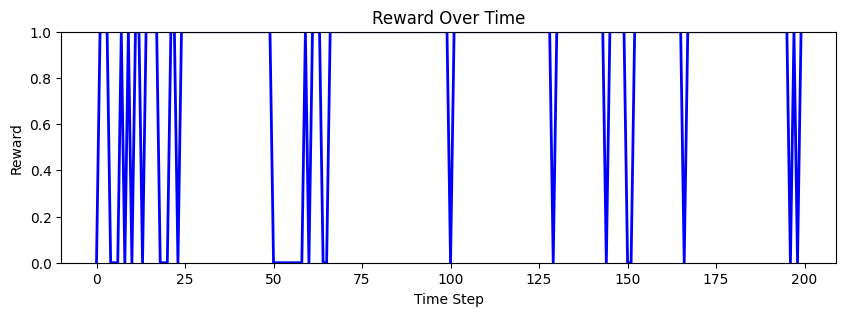


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.02  0.02], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.23  0.28  0.22]
Step 2:   	True state: 0, Obs.: [ 1.22  0.06], Action: 3, Reward: 0.0, Action probs.: [ 0.24  0.29  0.25  0.23]
Step 3:   	True state: 0, Obs.: [ 0.84  0.08], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.30  0.20  0.23]
Step 4:   	True state: 0, Obs.: [ 1.12  0.12], Action: 3, Reward: 0.0, Action probs.: [ 0.31  0.31  0.23  0.15]
Step 5:   	True state: 0, Obs.: [ 0.92 -0.03], Action: 0, Reward: 1.0, Action probs.: [ 0.34  0.26  0.23  0.17]
Step 6:   	True state: 0, Obs.: [ 0.80 -0.18], Action: 0, Reward: 1.0, Action probs.: [ 0.85  0.07  0.04  0.04]
Step 7:   	True state: 1, Obs.: [-1.10  0.11], Action: 1, Reward: 1.0, Action probs.: [ 0.28  0.26  0.15  0.31]
Step 8:   	True state: 1, Obs.: [-1.27 -0.16], Action: 0, Reward: 0.0, Action probs.: [ 0.07  0.84  0.02  0.07]
Step 9:   	True state: 

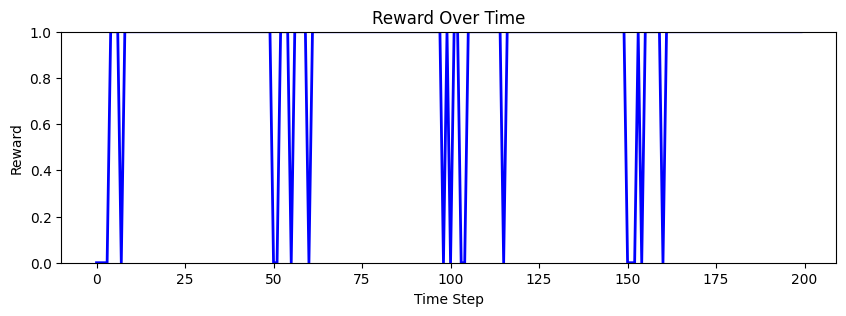


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.04  0.30], Action: 3, Reward: 0.0, Action probs.: [ 0.24  0.25  0.24  0.27]
Step 2:   	True state: 1, Obs.: [-1.01 -0.18], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.30  0.29  0.17]
Step 3:   	True state: 1, Obs.: [-1.04  0.06], Action: 1, Reward: 1.0, Action probs.: [ 0.29  0.28  0.19  0.24]
Step 4:   	True state: 1, Obs.: [-0.85 -0.20], Action: 1, Reward: 1.0, Action probs.: [ 0.10  0.80  0.04  0.06]
Step 5:   	True state: 1, Obs.: [-0.99 -0.04], Action: 1, Reward: 1.0, Action probs.: [ 0.08  0.87  0.03  0.03]
Step 6:   	True state: 0, Obs.: [ 0.89 -0.15], Action: 2, Reward: 0.0, Action probs.: [ 0.21  0.28  0.24  0.27]
Step 7:   	True state: 1, Obs.: [-1.02 -0.02], Action: 1, Reward: 1.0, Action probs.: [ 0.05  0.92  0.01  0.02]
Step 8:   	True state: 0, Obs.: [ 0.92 -0.23], Action: 1, Reward: 0.0, Action probs.: [ 0.25  0.32  0.15  0.28]
Step 9:   	True state: 

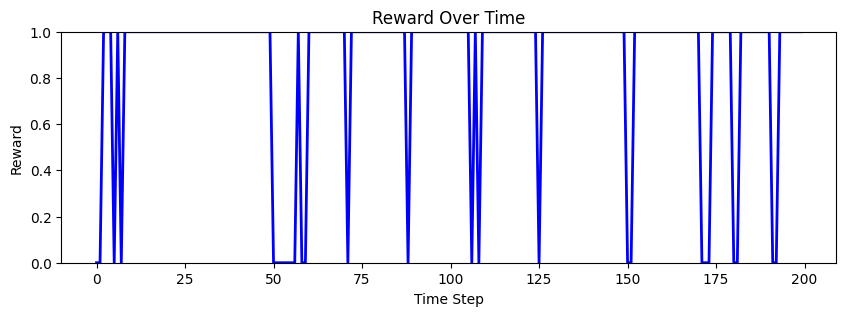


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.96  0.05], Action: 2, Reward: 0.0, Action probs.: [ 0.23  0.24  0.24  0.29]
Step 2:   	True state: 0, Obs.: [ 1.33  0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.26  0.27  0.18  0.29]
Step 3:   	True state: 0, Obs.: [ 1.20  0.15], Action: 0, Reward: 1.0, Action probs.: [ 0.76  0.12  0.06  0.07]
Step 4:   	True state: 1, Obs.: [-0.98  0.26], Action: 3, Reward: 0.0, Action probs.: [ 0.33  0.22  0.24  0.20]
Step 5:   	True state: 0, Obs.: [ 0.89 -0.20], Action: 0, Reward: 1.0, Action probs.: [ 0.84  0.06  0.03  0.07]
Step 6:   	True state: 1, Obs.: [-0.78  0.06], Action: 2, Reward: 0.0, Action probs.: [ 0.30  0.25  0.30  0.15]
Step 7:   	True state: 1, Obs.: [-0.80 -0.10], Action: 0, Reward: 0.0, Action probs.: [ 0.28  0.37  0.17  0.19]
Step 8:   	True state: 0, Obs.: [ 1.27 -0.23], Action: 0, Reward: 1.0, Action probs.: [ 0.88  0.06  0.01  0.05]
Step 9:   	True state: 

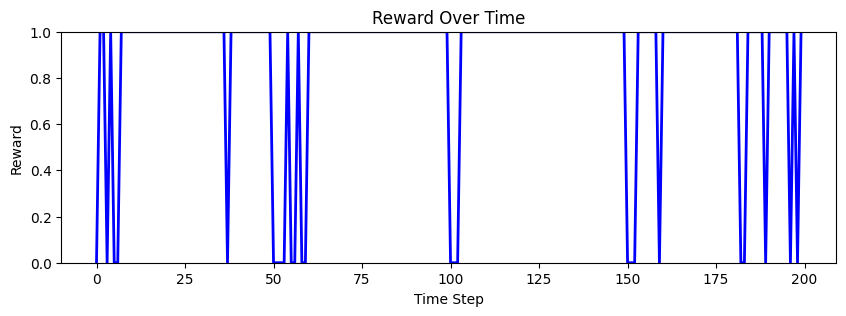


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.98  0.03], Action: 3, Reward: 0.0, Action probs.: [ 0.30  0.22  0.27  0.22]
Step 2:   	True state: 1, Obs.: [-1.07  0.00], Action: 0, Reward: 0.0, Action probs.: [ 0.28  0.23  0.25  0.25]
Step 3:   	True state: 0, Obs.: [ 1.04 -0.04], Action: 1, Reward: 0.0, Action probs.: [ 0.25  0.28  0.26  0.20]
Step 4:   	True state: 1, Obs.: [-1.08  0.23], Action: 2, Reward: 0.0, Action probs.: [ 0.21  0.33  0.28  0.19]
Step 5:   	True state: 0, Obs.: [ 1.09  0.06], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.21  0.27  0.25]
Step 6:   	True state: 1, Obs.: [-0.98  0.04], Action: 1, Reward: 1.0, Action probs.: [ 0.25  0.32  0.20  0.24]
Step 7:   	True state: 0, Obs.: [ 1.02  0.08], Action: 3, Reward: 0.0, Action probs.: [ 0.29  0.22  0.29  0.20]
Step 8:   	True state: 1, Obs.: [-0.92  0.05], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.92  0.03  0.03]
Step 9:   	True state: 

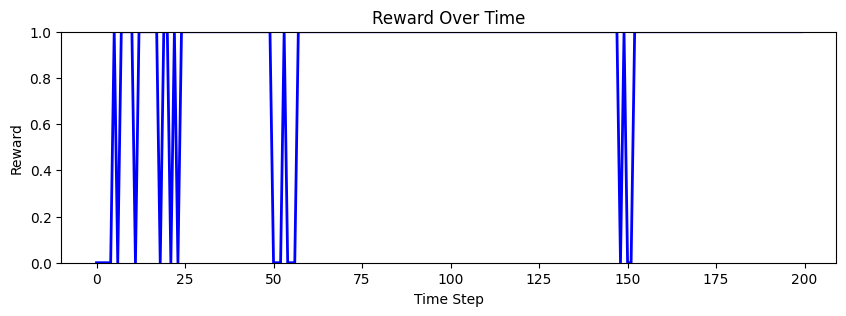


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.87 -0.16], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.25  0.31  0.22]
Step 2:   	True state: 0, Obs.: [ 1.00 -0.03], Action: 3, Reward: 0.0, Action probs.: [ 0.21  0.28  0.21  0.30]
Step 3:   	True state: 1, Obs.: [-1.09 -0.03], Action: 2, Reward: 0.0, Action probs.: [ 0.30  0.24  0.19  0.26]
Step 4:   	True state: 1, Obs.: [-1.05  0.18], Action: 3, Reward: 0.0, Action probs.: [ 0.29  0.27  0.15  0.30]
Step 5:   	True state: 1, Obs.: [-0.93 -0.15], Action: 3, Reward: 0.0, Action probs.: [ 0.32  0.31  0.17  0.20]
Step 6:   	True state: 1, Obs.: [-0.93  0.06], Action: 3, Reward: 0.0, Action probs.: [ 0.31  0.26  0.22  0.21]
Step 7:   	True state: 1, Obs.: [-1.20 -0.12], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.29  0.21  0.22]
Step 8:   	True state: 1, Obs.: [-0.98 -0.07], Action: 2, Reward: 0.0, Action probs.: [ 0.30  0.37  0.19  0.14]
Step 9:   	True state: 

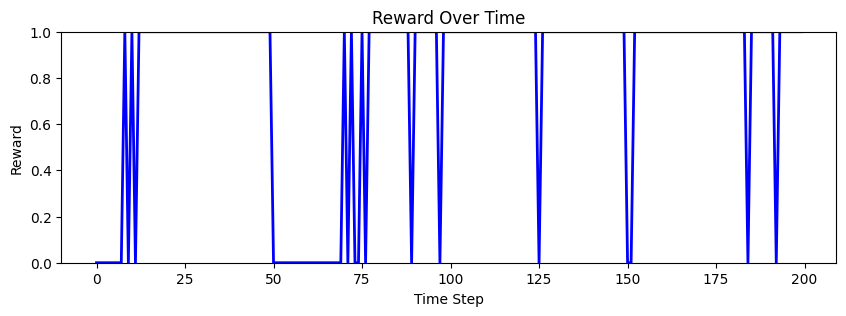


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.07 -0.02], Action: 0, Reward: 0.0, Action probs.: [ 0.24  0.25  0.25  0.25]
Step 2:   	True state: 0, Obs.: [ 1.12  0.03], Action: 1, Reward: 0.0, Action probs.: [ 0.29  0.28  0.22  0.22]
Step 3:   	True state: 1, Obs.: [-0.95  0.13], Action: 3, Reward: 0.0, Action probs.: [ 0.20  0.23  0.26  0.31]
Step 4:   	True state: 1, Obs.: [-0.80  0.07], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.30  0.28  0.20]
Step 5:   	True state: 1, Obs.: [-0.93 -0.15], Action: 3, Reward: 0.0, Action probs.: [ 0.21  0.30  0.29  0.19]
Step 6:   	True state: 0, Obs.: [ 0.97  0.07], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.21  0.29  0.25]
Step 7:   	True state: 1, Obs.: [-0.88  0.18], Action: 1, Reward: 1.0, Action probs.: [ 0.26  0.27  0.23  0.23]
Step 8:   	True state: 1, Obs.: [-1.16 -0.25], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.92  0.04  0.03]
Step 9:   	True state: 

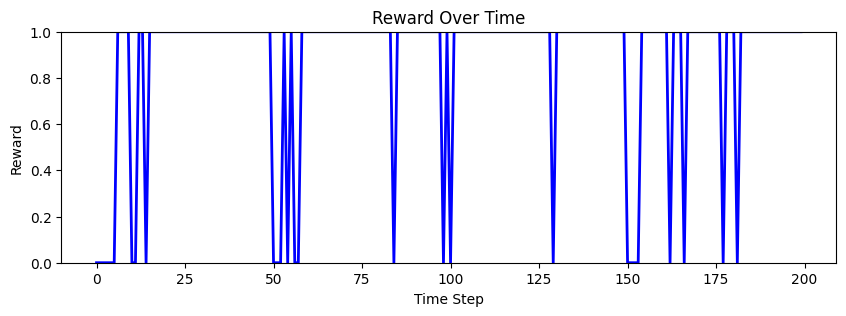


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.81 -0.09], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.28  0.25  0.25]
Step 2:   	True state: 0, Obs.: [ 0.86 -0.20], Action: 0, Reward: 1.0, Action probs.: [ 0.25  0.24  0.24  0.28]
Step 3:   	True state: 0, Obs.: [ 0.89  0.04], Action: 0, Reward: 1.0, Action probs.: [ 0.78  0.10  0.07  0.05]
Step 4:   	True state: 1, Obs.: [-0.82  0.14], Action: 0, Reward: 0.0, Action probs.: [ 0.30  0.27  0.17  0.26]
Step 5:   	True state: 1, Obs.: [-1.19 -0.17], Action: 0, Reward: 0.0, Action probs.: [ 0.22  0.23  0.23  0.32]
Step 6:   	True state: 0, Obs.: [ 0.75 -0.09], Action: 0, Reward: 1.0, Action probs.: [ 0.87  0.05  0.02  0.07]
Step 7:   	True state: 0, Obs.: [ 1.06  0.26], Action: 0, Reward: 1.0, Action probs.: [ 0.90  0.05  0.04  0.02]
Step 8:   	True state: 0, Obs.: [ 1.00 -0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.92  0.03  0.01  0.04]
Step 9:   	True state: 

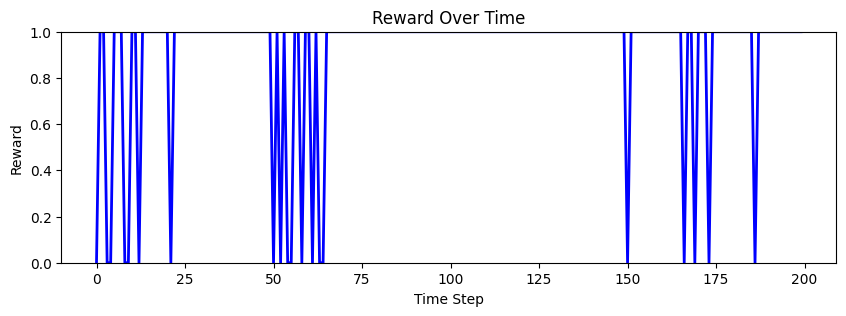


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.97 -0.18], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.25  0.26  0.26]
Step 2:   	True state: 0, Obs.: [ 0.95  0.05], Action: 3, Reward: 0.0, Action probs.: [ 0.19  0.35  0.17  0.29]
Step 3:   	True state: 0, Obs.: [ 0.84 -0.28], Action: 1, Reward: 0.0, Action probs.: [ 0.37  0.26  0.17  0.21]
Step 4:   	True state: 1, Obs.: [-0.85 -0.02], Action: 0, Reward: 0.0, Action probs.: [ 0.25  0.26  0.24  0.25]
Step 5:   	True state: 0, Obs.: [ 1.05 -0.10], Action: 2, Reward: 0.0, Action probs.: [ 0.29  0.28  0.21  0.22]
Step 6:   	True state: 0, Obs.: [ 0.95  0.09], Action: 3, Reward: 0.0, Action probs.: [ 0.31  0.23  0.25  0.21]
Step 7:   	True state: 0, Obs.: [ 1.07  0.07], Action: 2, Reward: 0.0, Action probs.: [ 0.34  0.23  0.20  0.23]
Step 8:   	True state: 0, Obs.: [ 1.06 -0.06], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.30  0.24  0.23]
Step 9:   	True state: 

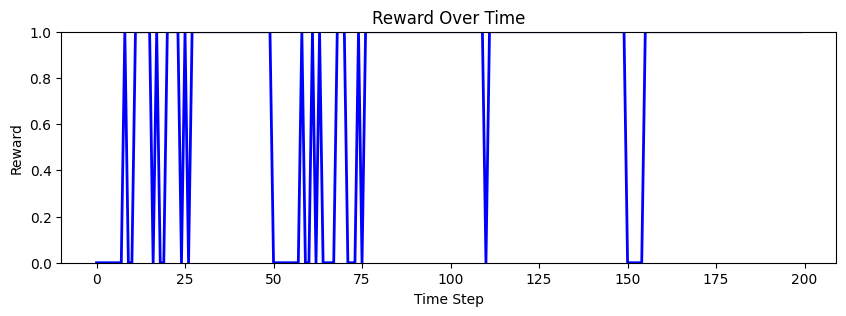


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.34  0.10], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.22  0.28  0.28]
Step 2:   	True state: 1, Obs.: [-0.82 -0.17], Action: 3, Reward: 0.0, Action probs.: [ 0.25  0.28  0.20  0.27]
Step 3:   	True state: 0, Obs.: [ 0.96 -0.34], Action: 2, Reward: 0.0, Action probs.: [ 0.21  0.32  0.24  0.24]
Step 4:   	True state: 0, Obs.: [ 1.08 -0.01], Action: 2, Reward: 0.0, Action probs.: [ 0.29  0.24  0.23  0.23]
Step 5:   	True state: 0, Obs.: [ 1.07  0.05], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.29  0.20  0.27]
Step 6:   	True state: 0, Obs.: [ 0.98 -0.13], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.24  0.17  0.32]
Step 7:   	True state: 0, Obs.: [ 0.85 -0.10], Action: 0, Reward: 1.0, Action probs.: [ 0.34  0.25  0.16  0.26]
Step 8:   	True state: 0, Obs.: [ 0.83  0.21], Action: 0, Reward: 1.0, Action probs.: [ 0.84  0.05  0.03  0.08]
Step 9:   	True state: 

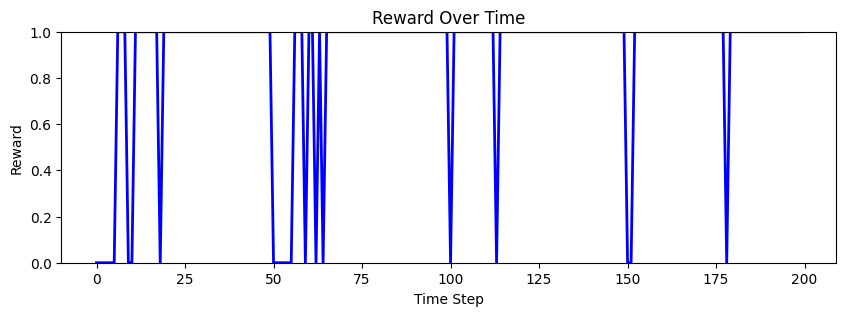


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.98 -0.04], Action: 3, Reward: 0.0, Action probs.: [ 0.22  0.24  0.26  0.28]
Step 2:   	True state: 0, Obs.: [ 0.84 -0.03], Action: 0, Reward: 1.0, Action probs.: [ 0.26  0.21  0.30  0.23]
Step 3:   	True state: 0, Obs.: [ 0.78  0.02], Action: 3, Reward: 0.0, Action probs.: [ 0.79  0.07  0.07  0.07]
Step 4:   	True state: 1, Obs.: [-1.06  0.02], Action: 2, Reward: 0.0, Action probs.: [ 0.44  0.21  0.20  0.15]
Step 5:   	True state: 1, Obs.: [-1.05  0.04], Action: 0, Reward: 0.0, Action probs.: [ 0.27  0.33  0.18  0.22]
Step 6:   	True state: 1, Obs.: [-0.95  0.39], Action: 0, Reward: 0.0, Action probs.: [ 0.22  0.30  0.25  0.23]
Step 7:   	True state: 0, Obs.: [ 0.99  0.05], Action: 3, Reward: 0.0, Action probs.: [ 0.81  0.10  0.05  0.04]
Step 8:   	True state: 0, Obs.: [ 1.12 -0.05], Action: 0, Reward: 1.0, Action probs.: [ 0.85  0.08  0.06  0.01]
Step 9:   	True state: 

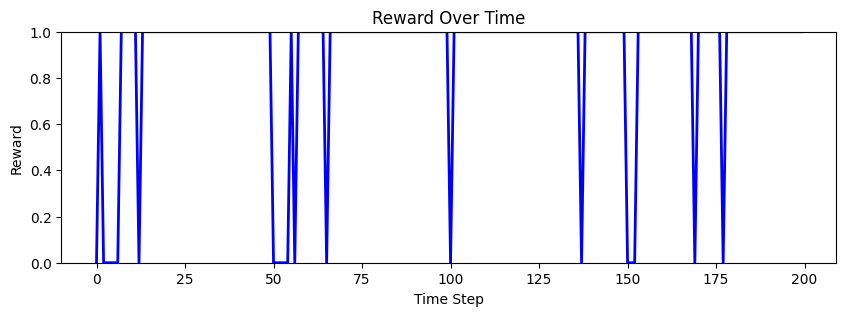


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.93 -0.11], Action: 0, Reward: 1.0, Action probs.: [ 0.23  0.31  0.23  0.23]
Step 2:   	True state: 0, Obs.: [ 0.88  0.14], Action: 3, Reward: 0.0, Action probs.: [ 0.76  0.08  0.08  0.08]
Step 3:   	True state: 1, Obs.: [-1.01  0.04], Action: 3, Reward: 0.0, Action probs.: [ 0.38  0.22  0.19  0.21]
Step 4:   	True state: 0, Obs.: [ 0.68 -0.06], Action: 3, Reward: 0.0, Action probs.: [ 0.75  0.10  0.08  0.07]
Step 5:   	True state: 1, Obs.: [-1.17 -0.09], Action: 0, Reward: 0.0, Action probs.: [ 0.24  0.28  0.23  0.24]
Step 6:   	True state: 0, Obs.: [ 1.03  0.20], Action: 0, Reward: 1.0, Action probs.: [ 0.83  0.07  0.07  0.03]
Step 7:   	True state: 0, Obs.: [ 0.90 -0.15], Action: 0, Reward: 1.0, Action probs.: [ 0.89  0.05  0.05  0.01]
Step 8:   	True state: 1, Obs.: [-1.03  0.18], Action: 0, Reward: 0.0, Action probs.: [ 0.28  0.28  0.22  0.22]
Step 9:   	True state: 

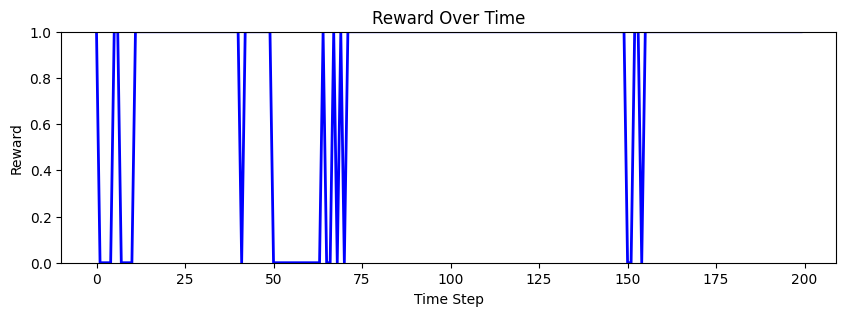


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.84 -0.13], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.25  0.25  0.23]
Step 2:   	True state: 1, Obs.: [-1.14 -0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.25  0.32  0.17  0.26]
Step 3:   	True state: 0, Obs.: [ 0.87 -0.12], Action: 1, Reward: 0.0, Action probs.: [ 0.16  0.38  0.21  0.24]
Step 4:   	True state: 0, Obs.: [ 0.94 -0.13], Action: 0, Reward: 1.0, Action probs.: [ 0.31  0.22  0.21  0.26]
Step 5:   	True state: 0, Obs.: [ 0.99  0.18], Action: 0, Reward: 1.0, Action probs.: [ 0.83  0.05  0.06  0.06]
Step 6:   	True state: 0, Obs.: [ 1.05 -0.12], Action: 0, Reward: 1.0, Action probs.: [ 0.91  0.02  0.04  0.03]
Step 7:   	True state: 1, Obs.: [-1.08 -0.09], Action: 1, Reward: 1.0, Action probs.: [ 0.05  0.88  0.01  0.06]
Step 8:   	True state: 0, Obs.: [ 1.03 -0.17], Action: 2, Reward: 0.0, Action probs.: [ 0.90  0.01  0.04  0.05]
Step 9:   	True state: 

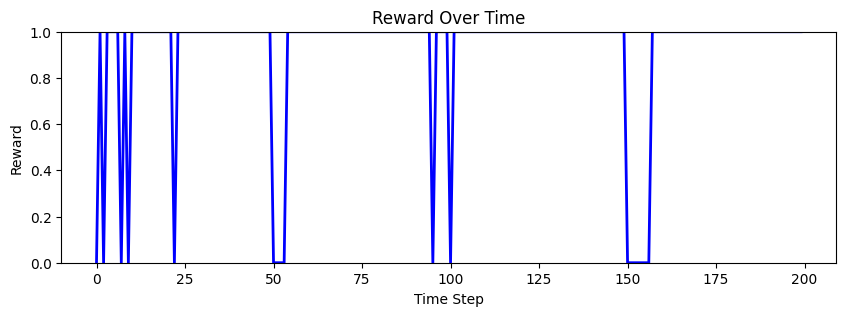


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.73  0.23], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.26  0.22  0.29]
Step 2:   	True state: 0, Obs.: [ 1.12 -0.03], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.29  0.23  0.23]
Step 3:   	True state: 0, Obs.: [ 1.03  0.03], Action: 3, Reward: 0.0, Action probs.: [ 0.31  0.25  0.19  0.25]
Step 4:   	True state: 0, Obs.: [ 0.99  0.07], Action: 1, Reward: 0.0, Action probs.: [ 0.30  0.28  0.20  0.22]
Step 5:   	True state: 1, Obs.: [-0.84  0.12], Action: 0, Reward: 0.0, Action probs.: [ 0.34  0.25  0.19  0.23]
Step 6:   	True state: 1, Obs.: [-0.97 -0.26], Action: 0, Reward: 0.0, Action probs.: [ 0.23  0.27  0.23  0.28]
Step 7:   	True state: 1, Obs.: [-0.92  0.12], Action: 3, Reward: 0.0, Action probs.: [ 0.20  0.26  0.27  0.27]
Step 8:   	True state: 1, Obs.: [-1.10 -0.07], Action: 0, Reward: 0.0, Action probs.: [ 0.20  0.35  0.22  0.23]
Step 9:   	True state: 

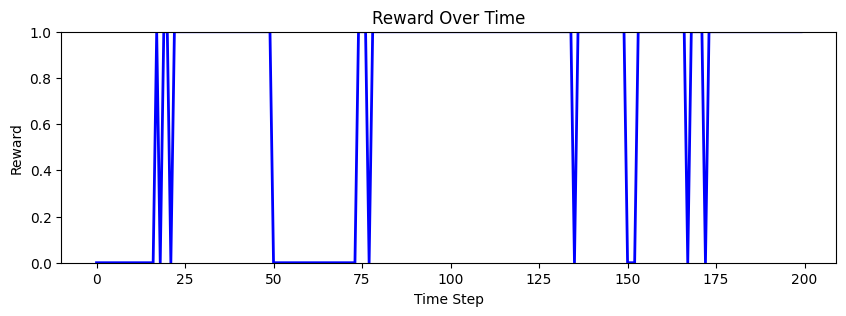


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.98  0.01], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.20  0.24  0.29]
Step 2:   	True state: 1, Obs.: [-1.03 -0.18], Action: 2, Reward: 0.0, Action probs.: [ 0.28  0.27  0.15  0.30]
Step 3:   	True state: 0, Obs.: [ 0.91  0.30], Action: 1, Reward: 0.0, Action probs.: [ 0.27  0.28  0.23  0.22]
Step 4:   	True state: 1, Obs.: [-1.00  0.11], Action: 1, Reward: 1.0, Action probs.: [ 0.28  0.29  0.15  0.28]
Step 5:   	True state: 0, Obs.: [ 0.88 -0.12], Action: 1, Reward: 0.0, Action probs.: [ 0.23  0.20  0.36  0.21]
Step 6:   	True state: 0, Obs.: [ 1.05  0.08], Action: 3, Reward: 0.0, Action probs.: [ 0.25  0.18  0.26  0.30]
Step 7:   	True state: 1, Obs.: [-1.02 -0.08], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.88  0.00  0.08]
Step 8:   	True state: 1, Obs.: [-0.52 -0.02], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.83  0.04  0.06]
Step 9:   	True state: 

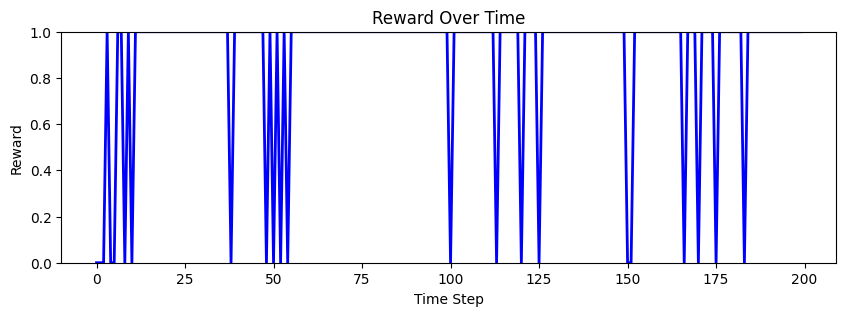


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.29  0.06], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.23  0.27  0.24]
Step 2:   	True state: 0, Obs.: [ 0.87 -0.10], Action: 1, Reward: 0.0, Action probs.: [ 0.26  0.28  0.26  0.21]
Step 3:   	True state: 0, Obs.: [ 0.55  0.10], Action: 1, Reward: 0.0, Action probs.: [ 0.24  0.19  0.30  0.27]
Step 4:   	True state: 1, Obs.: [-0.78  0.15], Action: 1, Reward: 1.0, Action probs.: [ 0.29  0.26  0.18  0.27]
Step 5:   	True state: 1, Obs.: [-1.12 -0.23], Action: 1, Reward: 1.0, Action probs.: [ 0.06  0.81  0.03  0.09]
Step 6:   	True state: 1, Obs.: [-1.03 -0.04], Action: 2, Reward: 0.0, Action probs.: [ 0.05  0.93  0.00  0.02]
Step 7:   	True state: 0, Obs.: [ 1.10  0.10], Action: 1, Reward: 0.0, Action probs.: [ 0.31  0.15  0.26  0.28]
Step 8:   	True state: 0, Obs.: [ 0.96  0.24], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.18  0.33  0.27]
Step 9:   	True state: 

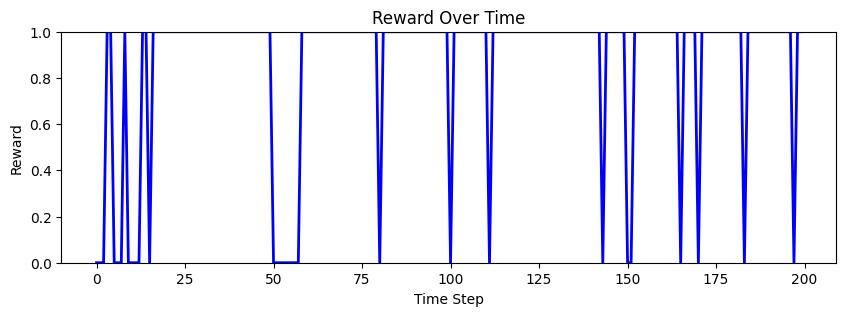


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.89 -0.11], Action: 0, Reward: 0.0, Action probs.: [ 0.28  0.26  0.22  0.24]
Step 2:   	True state: 1, Obs.: [-0.79 -0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.21  0.27  0.27  0.24]
Step 3:   	True state: 0, Obs.: [ 0.87 -0.12], Action: 2, Reward: 0.0, Action probs.: [ 0.19  0.48  0.17  0.17]
Step 4:   	True state: 1, Obs.: [-0.85 -0.05], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.78  0.08  0.10]
Step 5:   	True state: 0, Obs.: [ 1.14 -0.25], Action: 1, Reward: 0.0, Action probs.: [ 0.29  0.25  0.17  0.28]
Step 6:   	True state: 0, Obs.: [ 0.92 -0.10], Action: 0, Reward: 1.0, Action probs.: [ 0.37  0.18  0.17  0.28]
Step 7:   	True state: 0, Obs.: [ 0.73 -0.08], Action: 0, Reward: 1.0, Action probs.: [ 0.88  0.05  0.02  0.05]
Step 8:   	True state: 1, Obs.: [-0.99  0.22], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.90  0.06  0.01]
Step 9:   	True state: 

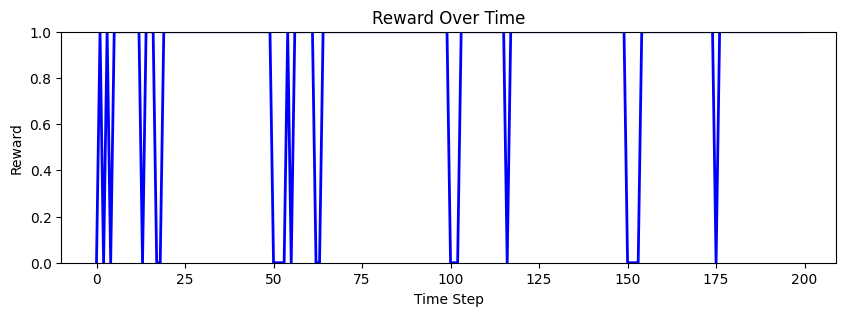


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.73  0.25], Action: 0, Reward: 0.0, Action probs.: [ 0.25  0.20  0.24  0.31]
Step 2:   	True state: 0, Obs.: [ 0.85  0.10], Action: 0, Reward: 1.0, Action probs.: [ 0.23  0.25  0.22  0.30]
Step 3:   	True state: 1, Obs.: [-1.00 -0.19], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.22  0.26  0.24]
Step 4:   	True state: 0, Obs.: [ 0.92  0.10], Action: 0, Reward: 1.0, Action probs.: [ 0.78  0.06  0.07  0.08]
Step 5:   	True state: 1, Obs.: [-0.85 -0.08], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.27  0.30  0.19]
Step 6:   	True state: 0, Obs.: [ 0.95 -0.08], Action: 0, Reward: 1.0, Action probs.: [ 0.85  0.07  0.03  0.05]
Step 7:   	True state: 0, Obs.: [ 1.04  0.02], Action: 0, Reward: 1.0, Action probs.: [ 0.90  0.05  0.03  0.03]
Step 8:   	True state: 0, Obs.: [ 1.02  0.13], Action: 0, Reward: 1.0, Action probs.: [ 0.90  0.05  0.01  0.04]
Step 9:   	True state: 

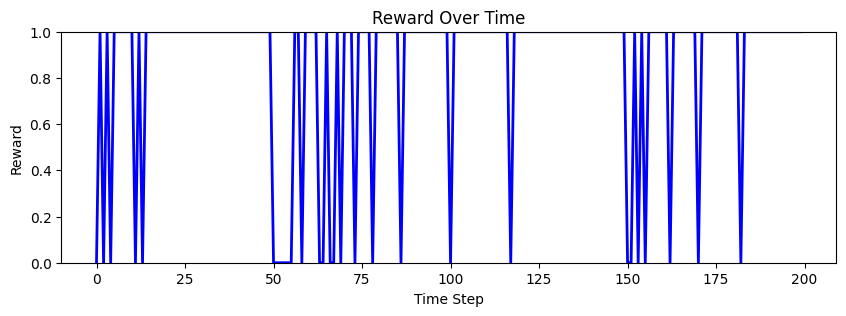


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.12  0.12], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.26  0.25  0.25]
Step 2:   	True state: 0, Obs.: [ 0.84  0.08], Action: 0, Reward: 1.0, Action probs.: [ 0.29  0.27  0.20  0.24]
Step 3:   	True state: 1, Obs.: [-0.94  0.13], Action: 2, Reward: 0.0, Action probs.: [ 0.41  0.19  0.17  0.23]
Step 4:   	True state: 1, Obs.: [-0.87 -0.04], Action: 0, Reward: 0.0, Action probs.: [ 0.29  0.27  0.20  0.24]
Step 5:   	True state: 0, Obs.: [ 1.29 -0.13], Action: 0, Reward: 1.0, Action probs.: [ 0.83  0.07  0.02  0.08]
Step 6:   	True state: 0, Obs.: [ 1.18  0.00], Action: 0, Reward: 1.0, Action probs.: [ 0.97  0.02  0.00  0.01]
Step 7:   	True state: 0, Obs.: [ 1.23 -0.24], Action: 0, Reward: 1.0, Action probs.: [ 0.88  0.07  0.01  0.03]
Step 8:   	True state: 1, Obs.: [-1.15 -0.14], Action: 2, Reward: 0.0, Action probs.: [ 0.21  0.30  0.20  0.30]
Step 9:   	True state: 

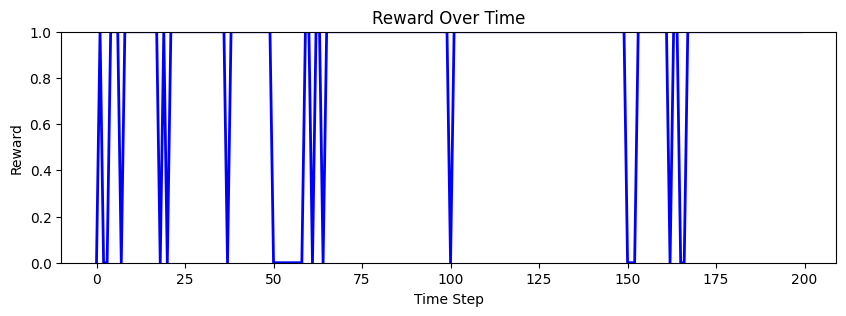


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.34 -0.07], Action: 1, Reward: 0.0, Action probs.: [ 0.24  0.26  0.18  0.32]
Step 2:   	True state: 1, Obs.: [-0.91 -0.06], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.24  0.25  0.27]
Step 3:   	True state: 0, Obs.: [ 0.81 -0.05], Action: 2, Reward: 0.0, Action probs.: [ 0.28  0.22  0.23  0.27]
Step 4:   	True state: 1, Obs.: [-0.83  0.08], Action: 2, Reward: 0.0, Action probs.: [ 0.28  0.23  0.20  0.29]
Step 5:   	True state: 0, Obs.: [ 1.25  0.04], Action: 1, Reward: 0.0, Action probs.: [ 0.24  0.20  0.22  0.34]
Step 6:   	True state: 1, Obs.: [-1.23 -0.01], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.27  0.19  0.28]
Step 7:   	True state: 1, Obs.: [-0.99  0.03], Action: 3, Reward: 0.0, Action probs.: [ 0.28  0.28  0.20  0.24]
Step 8:   	True state: 0, Obs.: [ 0.98 -0.05], Action: 1, Reward: 0.0, Action probs.: [ 0.27  0.20  0.13  0.40]
Step 9:   	True state: 

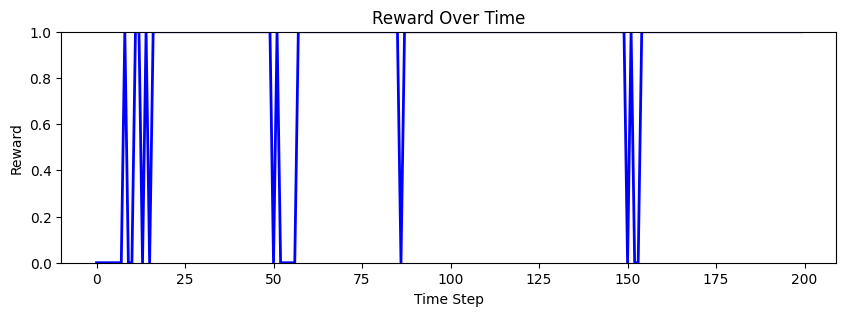


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.26 -0.03], Action: 1, Reward: 0.0, Action probs.: [ 0.24  0.26  0.26  0.24]
Step 2:   	True state: 1, Obs.: [-1.03 -0.23], Action: 1, Reward: 1.0, Action probs.: [ 0.26  0.23  0.28  0.24]
Step 3:   	True state: 0, Obs.: [ 0.88  0.12], Action: 1, Reward: 0.0, Action probs.: [ 0.21  0.23  0.28  0.27]
Step 4:   	True state: 1, Obs.: [-1.03  0.23], Action: 2, Reward: 0.0, Action probs.: [ 0.08  0.77  0.08  0.07]
Step 5:   	True state: 1, Obs.: [-0.92  0.08], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.83  0.04  0.06]
Step 6:   	True state: 0, Obs.: [ 1.15  0.13], Action: 0, Reward: 1.0, Action probs.: [ 0.29  0.21  0.28  0.22]
Step 7:   	True state: 1, Obs.: [-0.75 -0.14], Action: 1, Reward: 1.0, Action probs.: [ 0.05  0.89  0.02  0.03]
Step 8:   	True state: 1, Obs.: [-1.06 -0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.01  0.95  0.00  0.03]
Step 9:   	True state: 

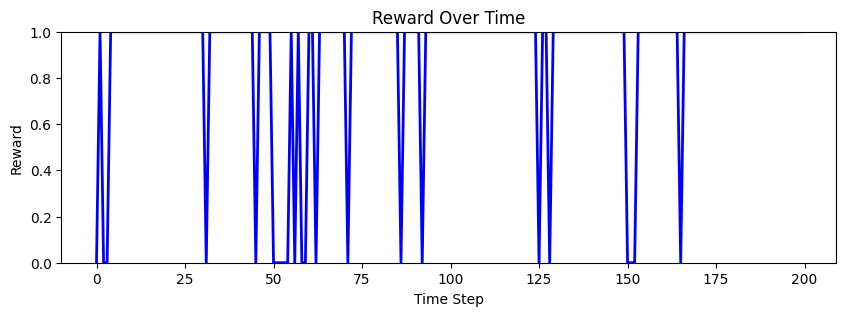


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.03 -0.12], Action: 0, Reward: 0.0, Action probs.: [ 0.19  0.27  0.28  0.26]
Step 2:   	True state: 0, Obs.: [ 1.15  0.06], Action: 1, Reward: 0.0, Action probs.: [ 0.20  0.26  0.27  0.27]
Step 3:   	True state: 0, Obs.: [ 1.06  0.16], Action: 2, Reward: 0.0, Action probs.: [ 0.28  0.20  0.22  0.30]
Step 4:   	True state: 1, Obs.: [-1.23  0.04], Action: 3, Reward: 0.0, Action probs.: [ 0.23  0.25  0.25  0.26]
Step 5:   	True state: 1, Obs.: [-1.01 -0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.20  0.28  0.32  0.20]
Step 6:   	True state: 1, Obs.: [-0.81  0.11], Action: 2, Reward: 0.0, Action probs.: [ 0.04  0.86  0.08  0.02]
Step 7:   	True state: 1, Obs.: [-0.83 -0.32], Action: 1, Reward: 1.0, Action probs.: [ 0.05  0.87  0.04  0.03]
Step 8:   	True state: 1, Obs.: [-1.08 -0.22], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.93  0.04  0.01]
Step 9:   	True state: 

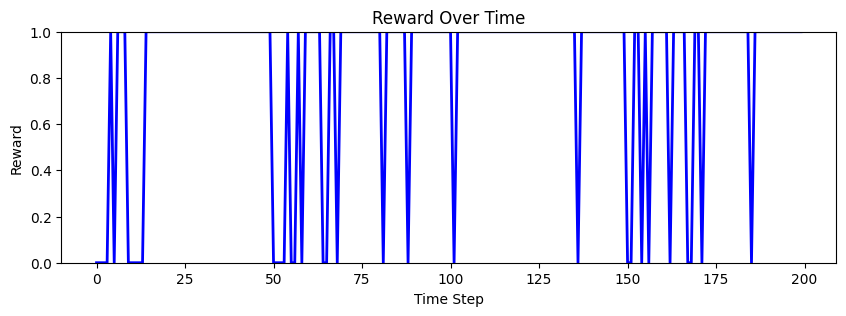


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.16 -0.17], Action: 3, Reward: 0.0, Action probs.: [ 0.24  0.29  0.24  0.23]
Step 2:   	True state: 1, Obs.: [-1.23 -0.08], Action: 0, Reward: 0.0, Action probs.: [ 0.25  0.23  0.25  0.28]
Step 3:   	True state: 1, Obs.: [-0.79  0.13], Action: 2, Reward: 0.0, Action probs.: [ 0.20  0.30  0.30  0.19]
Step 4:   	True state: 1, Obs.: [-1.04 -0.06], Action: 3, Reward: 0.0, Action probs.: [ 0.26  0.26  0.21  0.27]
Step 5:   	True state: 0, Obs.: [ 1.30 -0.25], Action: 3, Reward: 0.0, Action probs.: [ 0.24  0.28  0.28  0.20]
Step 6:   	True state: 1, Obs.: [-0.92  0.34], Action: 1, Reward: 1.0, Action probs.: [ 0.19  0.31  0.26  0.24]
Step 7:   	True state: 1, Obs.: [-0.94  0.05], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.90  0.03  0.03]
Step 8:   	True state: 1, Obs.: [-1.22  0.07], Action: 1, Reward: 1.0, Action probs.: [ 0.00  0.96  0.02  0.01]
Step 9:   	True state: 

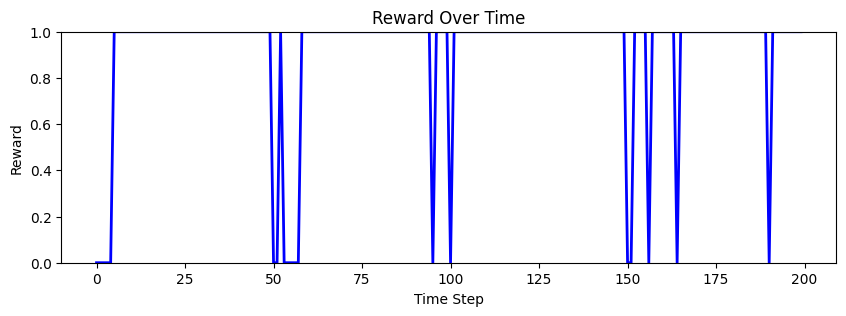


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.89 -0.12], Action: 1, Reward: 1.0, Action probs.: [ 0.28  0.25  0.22  0.25]
Step 2:   	True state: 1, Obs.: [-0.96 -0.08], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.80  0.08  0.08]
Step 3:   	True state: 0, Obs.: [ 1.05 -0.20], Action: 1, Reward: 0.0, Action probs.: [ 0.17  0.37  0.25  0.21]
Step 4:   	True state: 1, Obs.: [-0.96  0.12], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.83  0.07  0.06]
Step 5:   	True state: 1, Obs.: [-1.01 -0.05], Action: 1, Reward: 1.0, Action probs.: [ 0.03  0.88  0.05  0.03]
Step 6:   	True state: 0, Obs.: [ 0.93  0.19], Action: 3, Reward: 0.0, Action probs.: [ 0.28  0.22  0.25  0.24]
Step 7:   	True state: 0, Obs.: [ 0.69 -0.04], Action: 0, Reward: 1.0, Action probs.: [ 0.30  0.23  0.24  0.23]
Step 8:   	True state: 0, Obs.: [ 1.20  0.10], Action: 1, Reward: 0.0, Action probs.: [ 0.87  0.05  0.06  0.02]
Step 9:   	True state: 

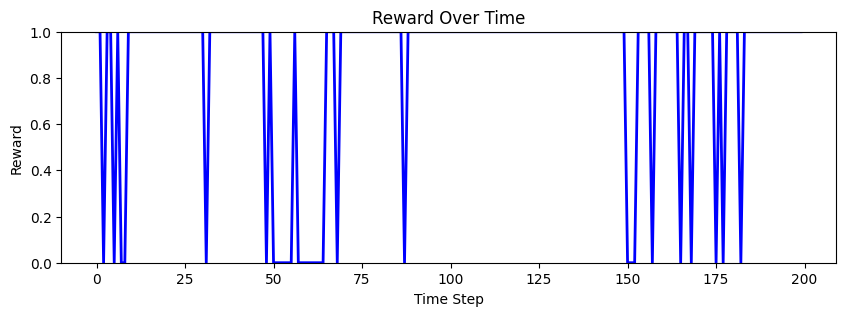


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.96 -0.14], Action: 3, Reward: 0.0, Action probs.: [ 0.24  0.20  0.21  0.35]
Step 2:   	True state: 1, Obs.: [-0.96 -0.02], Action: 3, Reward: 0.0, Action probs.: [ 0.21  0.28  0.26  0.24]
Step 3:   	True state: 0, Obs.: [ 0.94 -0.12], Action: 0, Reward: 1.0, Action probs.: [ 0.28  0.26  0.30  0.16]
Step 4:   	True state: 0, Obs.: [ 1.14 -0.15], Action: 1, Reward: 0.0, Action probs.: [ 0.84  0.08  0.03  0.05]
Step 5:   	True state: 1, Obs.: [-0.89  0.09], Action: 1, Reward: 1.0, Action probs.: [ 0.28  0.25  0.25  0.22]
Step 6:   	True state: 0, Obs.: [ 0.89 -0.20], Action: 0, Reward: 1.0, Action probs.: [ 0.83  0.06  0.09  0.02]
Step 7:   	True state: 0, Obs.: [ 0.61 -0.16], Action: 0, Reward: 1.0, Action probs.: [ 0.88  0.05  0.05  0.02]
Step 8:   	True state: 1, Obs.: [-0.87 -0.15], Action: 1, Reward: 1.0, Action probs.: [ 0.08  0.86  0.04  0.02]
Step 9:   	True state: 

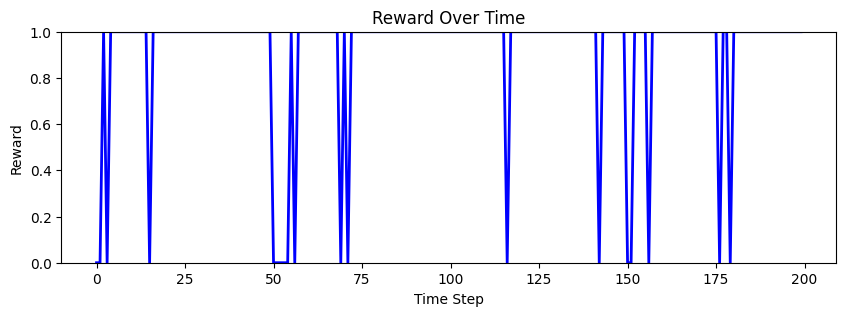


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.92  0.03], Action: 3, Reward: 0.0, Action probs.: [ 0.28  0.22  0.32  0.18]
Step 2:   	True state: 0, Obs.: [ 1.05  0.09], Action: 3, Reward: 0.0, Action probs.: [ 0.23  0.29  0.31  0.17]
Step 3:   	True state: 0, Obs.: [ 1.02  0.19], Action: 3, Reward: 0.0, Action probs.: [ 0.29  0.24  0.30  0.17]
Step 4:   	True state: 1, Obs.: [-0.99  0.17], Action: 1, Reward: 1.0, Action probs.: [ 0.25  0.25  0.31  0.19]
Step 5:   	True state: 1, Obs.: [-0.93 -0.10], Action: 1, Reward: 1.0, Action probs.: [ 0.09  0.83  0.02  0.06]
Step 6:   	True state: 0, Obs.: [ 1.04 -0.28], Action: 3, Reward: 0.0, Action probs.: [ 0.26  0.26  0.31  0.18]
Step 7:   	True state: 1, Obs.: [-1.28  0.13], Action: 1, Reward: 1.0, Action probs.: [ 0.06  0.87  0.04  0.03]
Step 8:   	True state: 0, Obs.: [ 1.02 -0.24], Action: 2, Reward: 0.0, Action probs.: [ 0.31  0.28  0.29  0.11]
Step 9:   	True state: 

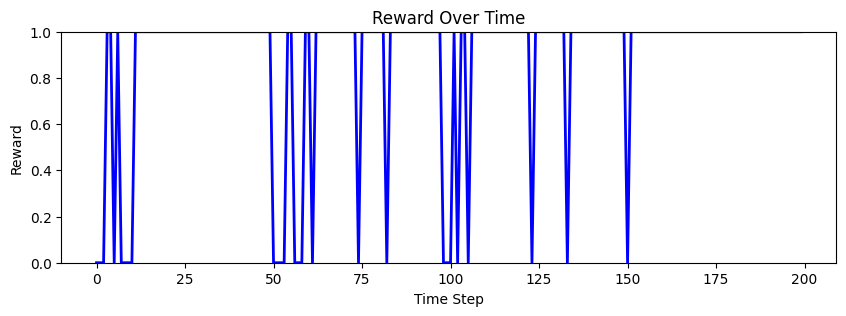


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.88 -0.05], Action: 0, Reward: 1.0, Action probs.: [ 0.24  0.24  0.28  0.25]
Step 2:   	True state: 1, Obs.: [-1.06 -0.01], Action: 3, Reward: 0.0, Action probs.: [ 0.38  0.19  0.19  0.24]
Step 3:   	True state: 0, Obs.: [ 1.09  0.00], Action: 3, Reward: 0.0, Action probs.: [ 0.76  0.10  0.06  0.08]
Step 4:   	True state: 1, Obs.: [-1.04 -0.12], Action: 3, Reward: 0.0, Action probs.: [ 0.33  0.23  0.28  0.16]
Step 5:   	True state: 0, Obs.: [ 1.13 -0.24], Action: 1, Reward: 0.0, Action probs.: [ 0.73  0.09  0.14  0.04]
Step 6:   	True state: 1, Obs.: [-0.84  0.08], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.29  0.24  0.21]
Step 7:   	True state: 1, Obs.: [-1.08  0.13], Action: 2, Reward: 0.0, Action probs.: [ 0.28  0.31  0.23  0.18]
Step 8:   	True state: 0, Obs.: [ 1.13 -0.25], Action: 0, Reward: 1.0, Action probs.: [ 0.91  0.03  0.03  0.03]
Step 9:   	True state: 

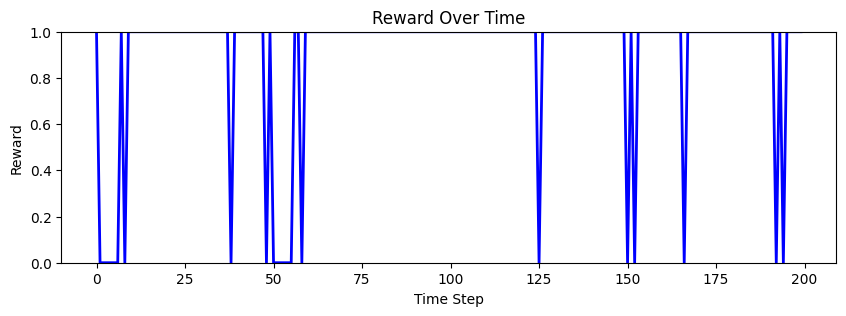


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.86 -0.10], Action: 1, Reward: 0.0, Action probs.: [ 0.27  0.24  0.25  0.24]
Step 2:   	True state: 0, Obs.: [ 0.97  0.06], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.22  0.24  0.28]
Step 3:   	True state: 1, Obs.: [-0.85 -0.03], Action: 0, Reward: 0.0, Action probs.: [ 0.20  0.34  0.23  0.24]
Step 4:   	True state: 1, Obs.: [-1.18 -0.01], Action: 0, Reward: 0.0, Action probs.: [ 0.28  0.22  0.23  0.27]
Step 5:   	True state: 1, Obs.: [-0.76 -0.03], Action: 2, Reward: 0.0, Action probs.: [ 0.18  0.24  0.31  0.26]
Step 6:   	True state: 0, Obs.: [ 1.14  0.05], Action: 0, Reward: 1.0, Action probs.: [ 0.28  0.25  0.23  0.24]
Step 7:   	True state: 1, Obs.: [-1.01  0.13], Action: 3, Reward: 0.0, Action probs.: [ 0.13  0.31  0.23  0.33]
Step 8:   	True state: 0, Obs.: [ 1.21  0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.88  0.05  0.01  0.06]
Step 9:   	True state: 

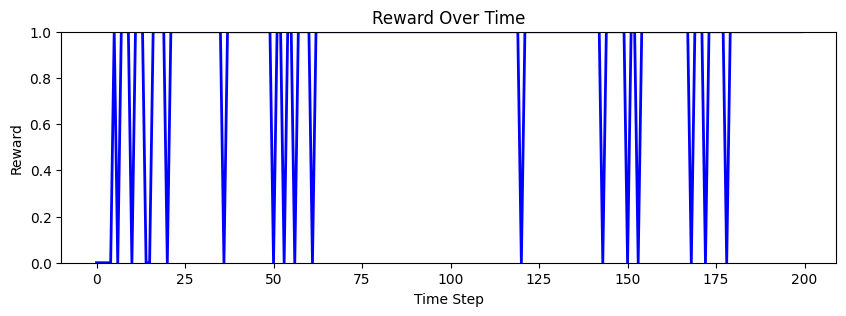


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.78 -0.02], Action: 2, Reward: 0.0, Action probs.: [ 0.23  0.22  0.27  0.28]
Step 2:   	True state: 0, Obs.: [ 0.94 -0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.28  0.28  0.20  0.25]
Step 3:   	True state: 1, Obs.: [-0.90 -0.03], Action: 2, Reward: 0.0, Action probs.: [ 0.39  0.23  0.20  0.19]
Step 4:   	True state: 0, Obs.: [ 0.95  0.03], Action: 0, Reward: 1.0, Action probs.: [ 0.74  0.09  0.06  0.12]
Step 5:   	True state: 1, Obs.: [-0.79 -0.04], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.31  0.18  0.24]
Step 6:   	True state: 0, Obs.: [ 1.00  0.10], Action: 1, Reward: 0.0, Action probs.: [ 0.85  0.05  0.05  0.05]
Step 7:   	True state: 0, Obs.: [ 1.12 -0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.85  0.04  0.06  0.05]
Step 8:   	True state: 0, Obs.: [ 1.10  0.25], Action: 0, Reward: 1.0, Action probs.: [ 0.91  0.01  0.03  0.05]
Step 9:   	True state: 

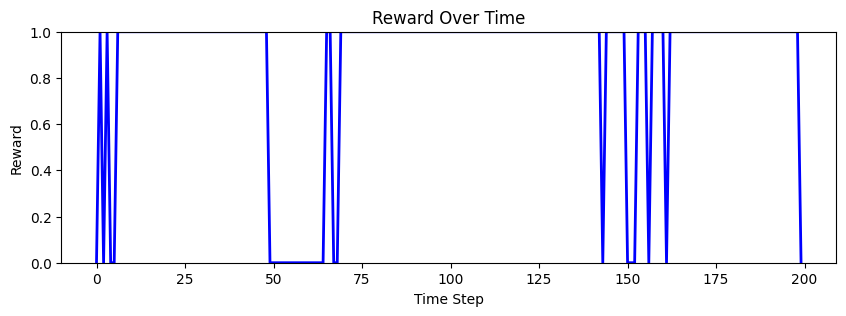


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.02 -0.25], Action: 0, Reward: 1.0, Action probs.: [ 0.26  0.25  0.28  0.21]
Step 2:   	True state: 1, Obs.: [-1.16 -0.10], Action: 3, Reward: 0.0, Action probs.: [ 0.36  0.18  0.22  0.23]
Step 3:   	True state: 1, Obs.: [-1.04  0.27], Action: 0, Reward: 0.0, Action probs.: [ 0.32  0.24  0.26  0.18]
Step 4:   	True state: 0, Obs.: [ 0.96 -0.22], Action: 0, Reward: 1.0, Action probs.: [ 0.82  0.06  0.06  0.06]
Step 5:   	True state: 1, Obs.: [-1.28  0.05], Action: 0, Reward: 0.0, Action probs.: [ 0.24  0.24  0.33  0.19]
Step 6:   	True state: 1, Obs.: [-1.08 -0.03], Action: 2, Reward: 0.0, Action probs.: [ 0.18  0.32  0.30  0.20]
Step 7:   	True state: 1, Obs.: [-1.39  0.07], Action: 1, Reward: 1.0, Action probs.: [ 0.22  0.28  0.23  0.27]
Step 8:   	True state: 0, Obs.: [ 1.18 -0.06], Action: 1, Reward: 0.0, Action probs.: [ 0.75  0.07  0.08  0.09]
Step 9:   	True state: 

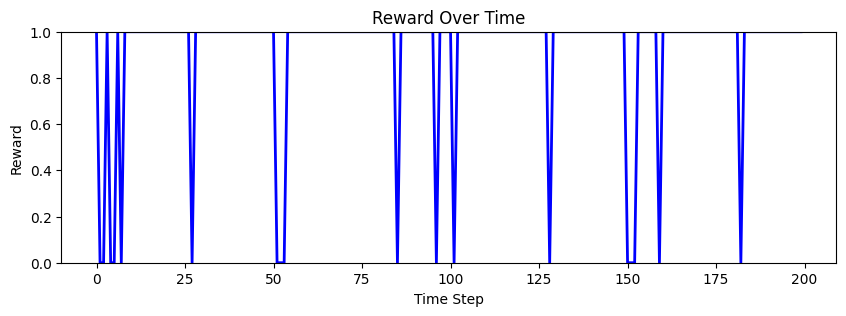


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.89 -0.04], Action: 3, Reward: 0.0, Action probs.: [ 0.21  0.26  0.24  0.28]
Step 2:   	True state: 0, Obs.: [ 1.11  0.18], Action: 0, Reward: 1.0, Action probs.: [ 0.23  0.34  0.25  0.18]
Step 3:   	True state: 0, Obs.: [ 1.09 -0.09], Action: 0, Reward: 1.0, Action probs.: [ 0.75  0.12  0.07  0.07]
Step 4:   	True state: 0, Obs.: [ 1.07 -0.17], Action: 0, Reward: 1.0, Action probs.: [ 0.85  0.06  0.06  0.04]
Step 5:   	True state: 0, Obs.: [ 0.76  0.24], Action: 1, Reward: 0.0, Action probs.: [ 0.83  0.07  0.04  0.06]
Step 6:   	True state: 1, Obs.: [-0.88  0.14], Action: 0, Reward: 0.0, Action probs.: [ 0.27  0.31  0.24  0.18]
Step 7:   	True state: 0, Obs.: [ 1.10 -0.04], Action: 2, Reward: 0.0, Action probs.: [ 0.87  0.02  0.05  0.06]
Step 8:   	True state: 0, Obs.: [ 1.12 -0.15], Action: 0, Reward: 1.0, Action probs.: [ 0.92  0.00  0.01  0.06]
Step 9:   	True state: 

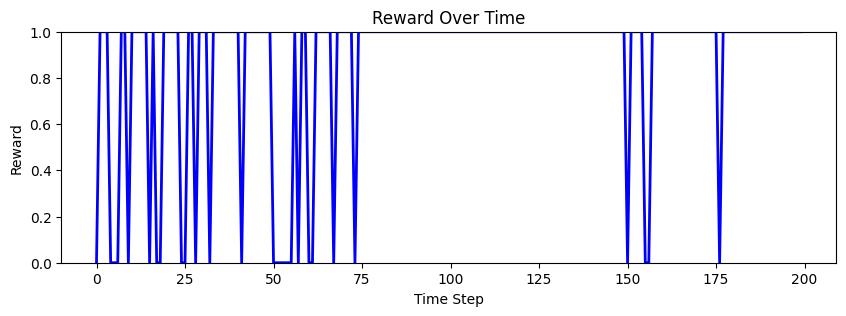


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.19 -0.01], Action: 1, Reward: 1.0, Action probs.: [ 0.27  0.22  0.27  0.24]
Step 2:   	True state: 0, Obs.: [ 0.91 -0.12], Action: 0, Reward: 1.0, Action probs.: [ 0.17  0.40  0.24  0.20]
Step 3:   	True state: 0, Obs.: [ 1.32 -0.14], Action: 1, Reward: 0.0, Action probs.: [ 0.74  0.10  0.09  0.08]
Step 4:   	True state: 0, Obs.: [ 1.13 -0.19], Action: 0, Reward: 1.0, Action probs.: [ 0.84  0.04  0.07  0.05]
Step 5:   	True state: 0, Obs.: [ 1.20 -0.14], Action: 0, Reward: 1.0, Action probs.: [ 0.87  0.02  0.06  0.04]
Step 6:   	True state: 0, Obs.: [ 1.06  0.00], Action: 0, Reward: 1.0, Action probs.: [ 0.93  0.02  0.04  0.02]
Step 7:   	True state: 0, Obs.: [ 1.05  0.31], Action: 3, Reward: 0.0, Action probs.: [ 0.94  0.02  0.01  0.03]
Step 8:   	True state: 0, Obs.: [ 1.05  0.11], Action: 0, Reward: 1.0, Action probs.: [ 0.95  0.01  0.03  0.01]
Step 9:   	True state: 

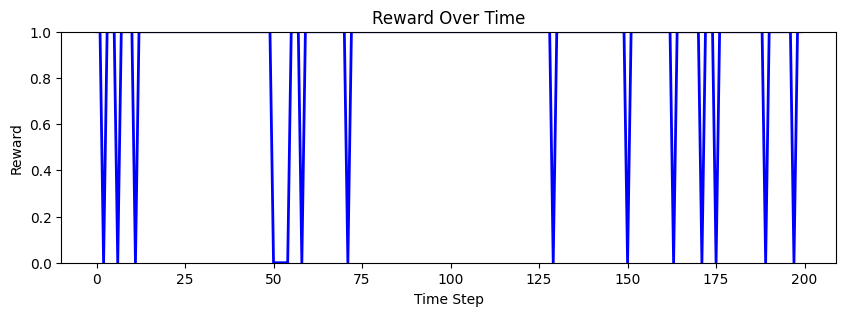


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.88  0.18], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.22  0.22  0.29]
Step 2:   	True state: 0, Obs.: [ 1.00 -0.17], Action: 3, Reward: 0.0, Action probs.: [ 0.22  0.33  0.23  0.22]
Step 3:   	True state: 1, Obs.: [-1.05  0.22], Action: 3, Reward: 0.0, Action probs.: [ 0.26  0.26  0.28  0.19]
Step 4:   	True state: 1, Obs.: [-1.05  0.04], Action: 2, Reward: 0.0, Action probs.: [ 0.33  0.25  0.24  0.18]
Step 5:   	True state: 1, Obs.: [-0.99  0.09], Action: 0, Reward: 0.0, Action probs.: [ 0.28  0.26  0.27  0.20]
Step 6:   	True state: 0, Obs.: [ 0.89  0.04], Action: 0, Reward: 1.0, Action probs.: [ 0.25  0.28  0.26  0.22]
Step 7:   	True state: 1, Obs.: [-1.14 -0.25], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.26  0.19  0.28]
Step 8:   	True state: 1, Obs.: [-0.86 -0.13], Action: 3, Reward: 0.0, Action probs.: [ 0.26  0.37  0.25  0.12]
Step 9:   	True state: 

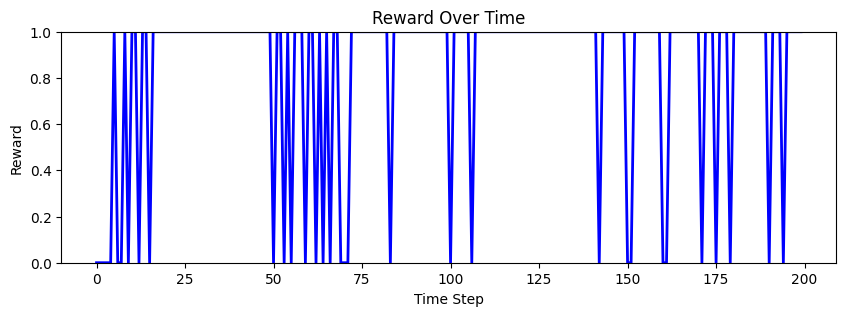


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.88 -0.10], Action: 0, Reward: 1.0, Action probs.: [ 0.26  0.22  0.27  0.25]
Step 2:   	True state: 0, Obs.: [ 1.12 -0.15], Action: 0, Reward: 1.0, Action probs.: [ 0.74  0.08  0.06  0.12]
Step 3:   	True state: 0, Obs.: [ 1.05  0.08], Action: 0, Reward: 1.0, Action probs.: [ 0.81  0.06  0.07  0.06]
Step 4:   	True state: 1, Obs.: [-0.97  0.37], Action: 1, Reward: 1.0, Action probs.: [ 0.34  0.23  0.23  0.20]
Step 5:   	True state: 0, Obs.: [ 1.04 -0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.82  0.10  0.05  0.03]
Step 6:   	True state: 1, Obs.: [-0.95 -0.18], Action: 2, Reward: 0.0, Action probs.: [ 0.08  0.80  0.06  0.07]
Step 7:   	True state: 0, Obs.: [ 0.95 -0.14], Action: 0, Reward: 1.0, Action probs.: [ 0.91  0.05  0.04  0.01]
Step 8:   	True state: 0, Obs.: [ 0.88  0.00], Action: 2, Reward: 0.0, Action probs.: [ 0.91  0.04  0.03  0.02]
Step 9:   	True state: 

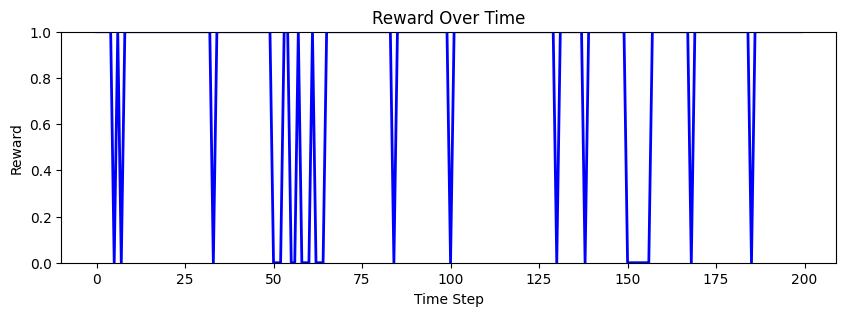


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.95  0.05], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.26  0.23  0.24]
Step 2:   	True state: 0, Obs.: [ 0.83 -0.19], Action: 1, Reward: 0.0, Action probs.: [ 0.21  0.26  0.26  0.26]
Step 3:   	True state: 1, Obs.: [-0.97 -0.01], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.25  0.23  0.25]
Step 4:   	True state: 0, Obs.: [ 0.89  0.02], Action: 2, Reward: 0.0, Action probs.: [ 0.23  0.23  0.25  0.28]
Step 5:   	True state: 0, Obs.: [ 1.09 -0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.25  0.20  0.26  0.29]
Step 6:   	True state: 0, Obs.: [ 0.99  0.03], Action: 0, Reward: 1.0, Action probs.: [ 0.87  0.05  0.01  0.07]
Step 7:   	True state: 0, Obs.: [ 0.91 -0.13], Action: 0, Reward: 1.0, Action probs.: [ 0.95  0.00  0.01  0.03]
Step 8:   	True state: 0, Obs.: [ 0.91  0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.99  0.00  0.00  0.01]
Step 9:   	True state: 

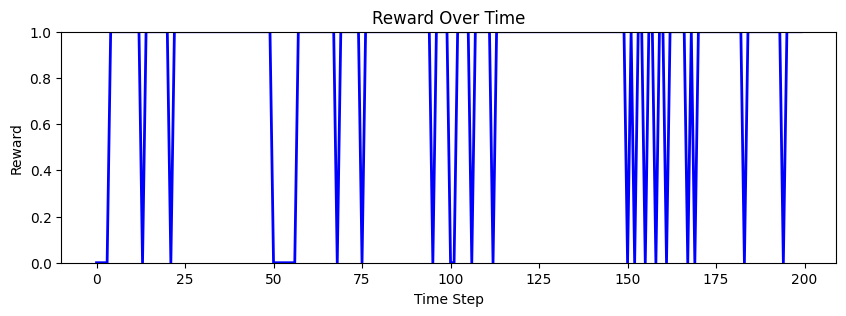


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.91 -0.17], Action: 0, Reward: 1.0, Action probs.: [ 0.24  0.26  0.26  0.23]
Step 2:   	True state: 1, Obs.: [-0.97  0.03], Action: 3, Reward: 0.0, Action probs.: [ 0.42  0.17  0.19  0.22]
Step 3:   	True state: 1, Obs.: [-0.85  0.00], Action: 2, Reward: 0.0, Action probs.: [ 0.43  0.19  0.24  0.14]
Step 4:   	True state: 1, Obs.: [-1.05  0.03], Action: 0, Reward: 0.0, Action probs.: [ 0.33  0.29  0.19  0.19]
Step 5:   	True state: 0, Obs.: [ 1.21  0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.88  0.05  0.04  0.03]
Step 6:   	True state: 1, Obs.: [-1.18 -0.21], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.38  0.23  0.15]
Step 7:   	True state: 0, Obs.: [ 0.92 -0.09], Action: 0, Reward: 1.0, Action probs.: [ 0.92  0.02  0.04  0.02]
Step 8:   	True state: 0, Obs.: [ 1.33 -0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.86  0.09  0.02  0.04]
Step 9:   	True state: 

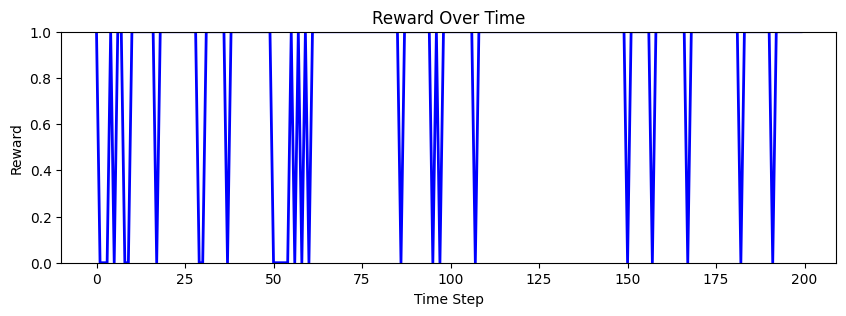


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.67 -0.22], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.24  0.28  0.24]
Step 2:   	True state: 0, Obs.: [ 1.01 -0.03], Action: 1, Reward: 0.0, Action probs.: [ 0.25  0.26  0.24  0.26]
Step 3:   	True state: 1, Obs.: [-1.00 -0.08], Action: 3, Reward: 0.0, Action probs.: [ 0.28  0.29  0.19  0.24]
Step 4:   	True state: 0, Obs.: [ 1.23 -0.04], Action: 1, Reward: 0.0, Action probs.: [ 0.24  0.25  0.24  0.27]
Step 5:   	True state: 1, Obs.: [-0.72 -0.11], Action: 1, Reward: 1.0, Action probs.: [ 0.25  0.31  0.21  0.23]
Step 6:   	True state: 1, Obs.: [-1.08 -0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.06  0.88  0.02  0.03]
Step 7:   	True state: 0, Obs.: [ 0.71  0.10], Action: 0, Reward: 1.0, Action probs.: [ 0.28  0.17  0.23  0.32]
Step 8:   	True state: 0, Obs.: [ 0.83 -0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.84  0.03  0.03  0.10]
Step 9:   	True state: 

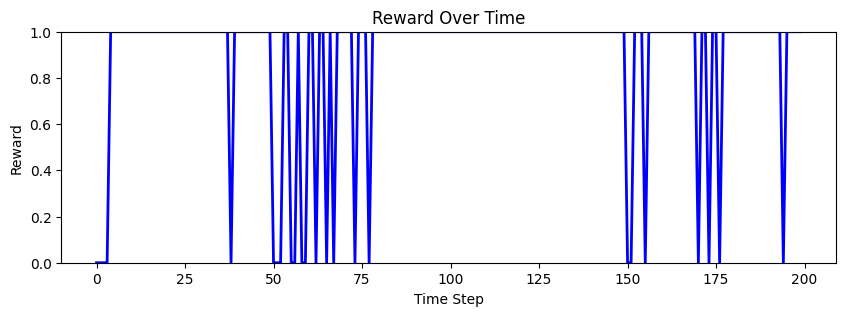


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.14 -0.25], Action: 1, Reward: 1.0, Action probs.: [ 0.26  0.24  0.22  0.28]
Step 2:   	True state: 1, Obs.: [-1.14  0.15], Action: 1, Reward: 1.0, Action probs.: [ 0.05  0.79  0.07  0.09]
Step 3:   	True state: 0, Obs.: [ 0.90  0.02], Action: 0, Reward: 1.0, Action probs.: [ 0.18  0.35  0.26  0.21]
Step 4:   	True state: 0, Obs.: [ 1.06 -0.13], Action: 2, Reward: 0.0, Action probs.: [ 0.81  0.08  0.07  0.05]
Step 5:   	True state: 1, Obs.: [-1.09 -0.01], Action: 3, Reward: 0.0, Action probs.: [ 0.06  0.87  0.02  0.05]
Step 6:   	True state: 1, Obs.: [-1.21 -0.06], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.90  0.04  0.01]
Step 7:   	True state: 1, Obs.: [-1.05 -0.07], Action: 1, Reward: 1.0, Action probs.: [ 0.03  0.92  0.04  0.01]
Step 8:   	True state: 1, Obs.: [-0.99  0.00], Action: 1, Reward: 1.0, Action probs.: [ 0.06  0.90  0.03  0.02]
Step 9:   	True state: 

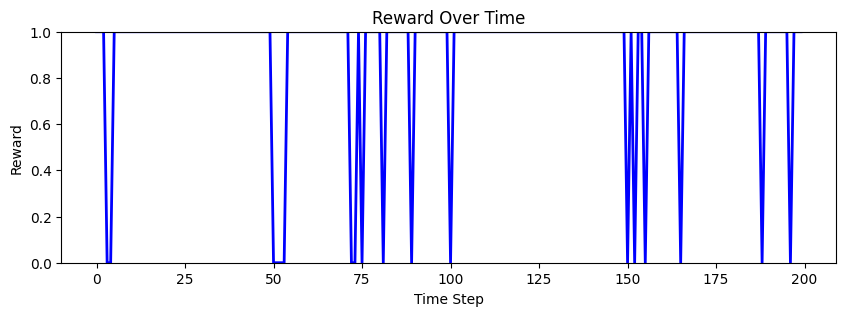


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.83 -0.08], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.26  0.28  0.23]
Step 2:   	True state: 1, Obs.: [-1.07 -0.09], Action: 1, Reward: 1.0, Action probs.: [ 0.25  0.22  0.21  0.32]
Step 3:   	True state: 1, Obs.: [-0.97  0.06], Action: 1, Reward: 1.0, Action probs.: [ 0.08  0.78  0.07  0.07]
Step 4:   	True state: 0, Obs.: [ 1.00  0.05], Action: 1, Reward: 0.0, Action probs.: [ 0.20  0.38  0.20  0.21]
Step 5:   	True state: 1, Obs.: [-0.93  0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.06  0.85  0.02  0.07]
Step 6:   	True state: 0, Obs.: [ 0.94  0.23], Action: 0, Reward: 1.0, Action probs.: [ 0.29  0.22  0.22  0.27]
Step 7:   	True state: 0, Obs.: [ 1.23  0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.82  0.03  0.08  0.07]
Step 8:   	True state: 1, Obs.: [-0.82 -0.06], Action: 3, Reward: 0.0, Action probs.: [ 0.06  0.88  0.01  0.05]
Step 9:   	True state: 

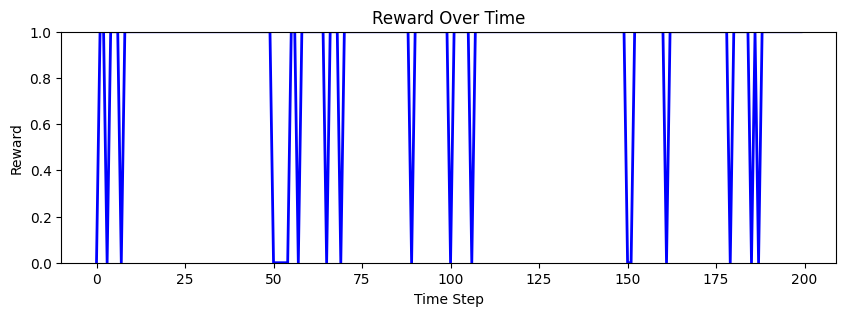


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.10  0.08], Action: 3, Reward: 0.0, Action probs.: [ 0.26  0.22  0.28  0.24]
Step 2:   	True state: 1, Obs.: [-0.98  0.02], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.26  0.24  0.23]
Step 3:   	True state: 0, Obs.: [ 0.88  0.13], Action: 0, Reward: 1.0, Action probs.: [ 0.28  0.23  0.24  0.26]
Step 4:   	True state: 1, Obs.: [-0.95  0.19], Action: 0, Reward: 0.0, Action probs.: [ 0.37  0.28  0.19  0.16]
Step 5:   	True state: 1, Obs.: [-0.99  0.06], Action: 0, Reward: 0.0, Action probs.: [ 0.30  0.30  0.21  0.20]
Step 6:   	True state: 1, Obs.: [-0.96 -0.13], Action: 2, Reward: 0.0, Action probs.: [ 0.31  0.31  0.20  0.17]
Step 7:   	True state: 1, Obs.: [-1.08 -0.30], Action: 3, Reward: 0.0, Action probs.: [ 0.23  0.30  0.23  0.25]
Step 8:   	True state: 1, Obs.: [-1.05 -0.10], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.35  0.21  0.22]
Step 9:   	True state: 

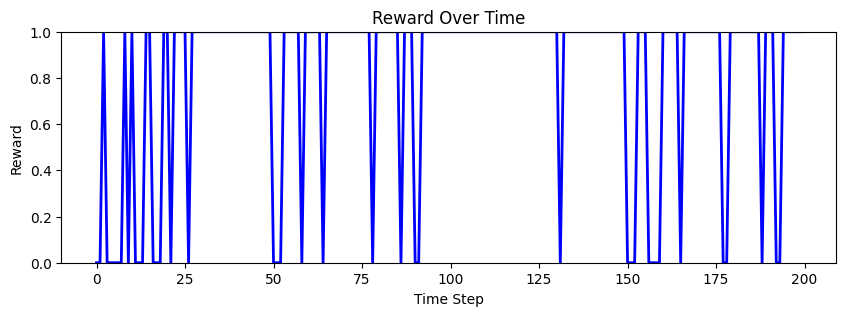


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.09  0.13], Action: 3, Reward: 0.0, Action probs.: [ 0.22  0.28  0.23  0.27]
Step 2:   	True state: 1, Obs.: [-0.98 -0.08], Action: 1, Reward: 1.0, Action probs.: [ 0.26  0.28  0.23  0.22]
Step 3:   	True state: 0, Obs.: [ 1.19 -0.00], Action: 1, Reward: 0.0, Action probs.: [ 0.23  0.35  0.26  0.16]
Step 4:   	True state: 0, Obs.: [ 0.96  0.14], Action: 1, Reward: 0.0, Action probs.: [ 0.25  0.27  0.25  0.23]
Step 5:   	True state: 1, Obs.: [-0.89  0.08], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.84  0.03  0.06]
Step 6:   	True state: 0, Obs.: [ 1.02  0.10], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.21  0.32  0.21]
Step 7:   	True state: 1, Obs.: [-1.08  0.01], Action: 2, Reward: 0.0, Action probs.: [ 0.06  0.81  0.08  0.06]
Step 8:   	True state: 0, Obs.: [ 1.07 -0.10], Action: 0, Reward: 1.0, Action probs.: [ 0.37  0.22  0.22  0.19]
Step 9:   	True state: 

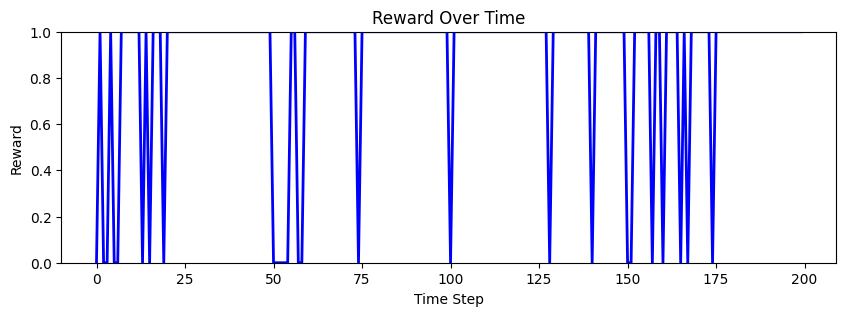


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.83 -0.05], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.26  0.27  0.22]
Step 2:   	True state: 0, Obs.: [ 1.04  0.13], Action: 2, Reward: 0.0, Action probs.: [ 0.28  0.24  0.25  0.24]
Step 3:   	True state: 1, Obs.: [-1.14 -0.11], Action: 0, Reward: 0.0, Action probs.: [ 0.25  0.29  0.19  0.27]
Step 4:   	True state: 1, Obs.: [-0.94 -0.02], Action: 3, Reward: 0.0, Action probs.: [ 0.18  0.30  0.28  0.24]
Step 5:   	True state: 1, Obs.: [-1.03 -0.04], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.29  0.21  0.23]
Step 6:   	True state: 0, Obs.: [ 1.30  0.00], Action: 2, Reward: 0.0, Action probs.: [ 0.31  0.26  0.18  0.26]
Step 7:   	True state: 1, Obs.: [-1.02 -0.11], Action: 2, Reward: 0.0, Action probs.: [ 0.16  0.26  0.34  0.24]
Step 8:   	True state: 1, Obs.: [-1.10 -0.11], Action: 1, Reward: 1.0, Action probs.: [ 0.21  0.28  0.25  0.26]
Step 9:   	True state: 

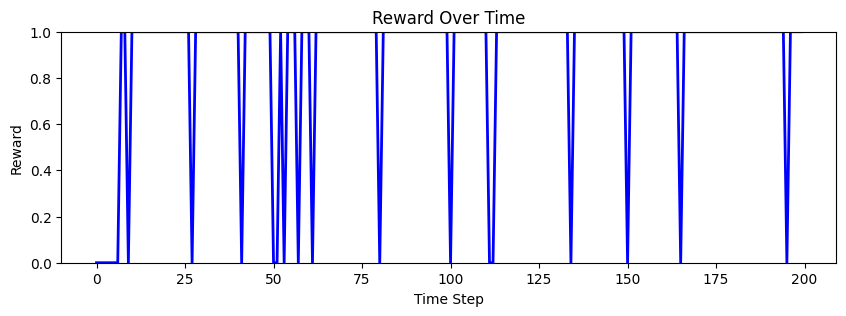


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.84  0.13], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.26  0.23  0.24]
Step 2:   	True state: 1, Obs.: [-1.06  0.13], Action: 3, Reward: 0.0, Action probs.: [ 0.26  0.26  0.26  0.22]
Step 3:   	True state: 1, Obs.: [-0.87 -0.04], Action: 1, Reward: 1.0, Action probs.: [ 0.21  0.26  0.38  0.16]
Step 4:   	True state: 0, Obs.: [ 1.19  0.16], Action: 1, Reward: 0.0, Action probs.: [ 0.28  0.29  0.25  0.19]
Step 5:   	True state: 1, Obs.: [-1.08  0.11], Action: 1, Reward: 1.0, Action probs.: [ 0.08  0.78  0.10  0.04]
Step 6:   	True state: 0, Obs.: [ 1.06  0.05], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.20  0.35  0.18]
Step 7:   	True state: 1, Obs.: [-1.03 -0.14], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.93  0.03  0.00]
Step 8:   	True state: 0, Obs.: [ 1.01  0.08], Action: 0, Reward: 1.0, Action probs.: [ 0.34  0.20  0.25  0.21]
Step 9:   	True state: 

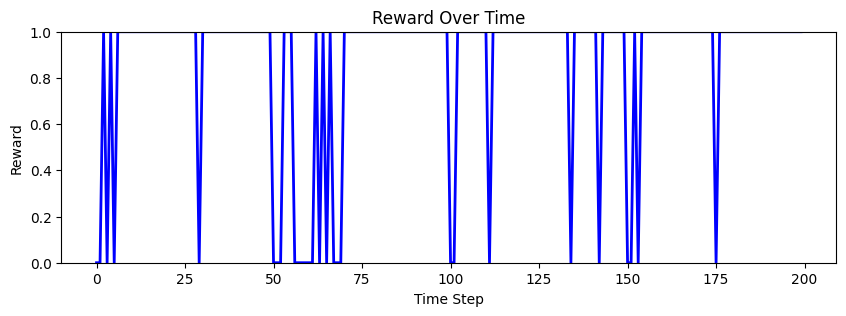


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.95  0.01], Action: 1, Reward: 1.0, Action probs.: [ 0.28  0.31  0.21  0.19]
Step 2:   	True state: 0, Obs.: [ 0.99 -0.07], Action: 0, Reward: 1.0, Action probs.: [ 0.18  0.40  0.23  0.20]
Step 3:   	True state: 0, Obs.: [ 0.98  0.09], Action: 2, Reward: 0.0, Action probs.: [ 0.69  0.18  0.06  0.07]
Step 4:   	True state: 0, Obs.: [ 1.22  0.25], Action: 0, Reward: 1.0, Action probs.: [ 0.79  0.12  0.02  0.07]
Step 5:   	True state: 0, Obs.: [ 1.06  0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.91  0.04  0.00  0.05]
Step 6:   	True state: 0, Obs.: [ 0.73 -0.24], Action: 0, Reward: 1.0, Action probs.: [ 0.84  0.10  0.01  0.05]
Step 7:   	True state: 1, Obs.: [-1.23  0.10], Action: 0, Reward: 0.0, Action probs.: [ 0.07  0.81  0.07  0.05]
Step 8:   	True state: 1, Obs.: [-1.00  0.01], Action: 1, Reward: 1.0, Action probs.: [ 0.01  0.90  0.04  0.05]
Step 9:   	True state: 

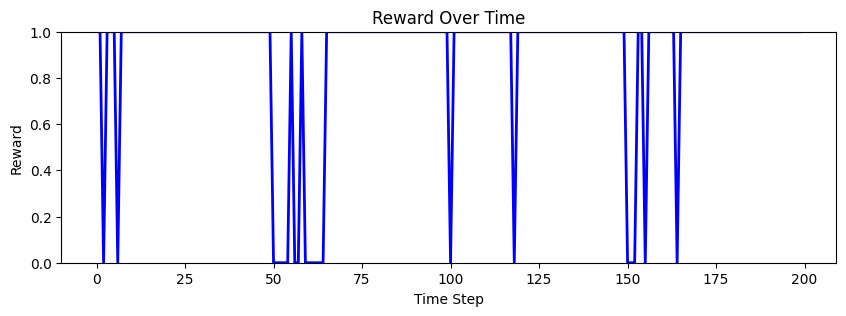


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.15  0.08], Action: 3, Reward: 0.0, Action probs.: [ 0.25  0.17  0.27  0.31]
Step 2:   	True state: 1, Obs.: [-0.86  0.10], Action: 3, Reward: 0.0, Action probs.: [ 0.24  0.28  0.27  0.22]
Step 3:   	True state: 0, Obs.: [ 1.19 -0.05], Action: 0, Reward: 1.0, Action probs.: [ 0.27  0.32  0.26  0.16]
Step 4:   	True state: 0, Obs.: [ 0.99  0.00], Action: 0, Reward: 1.0, Action probs.: [ 0.80  0.08  0.07  0.05]
Step 5:   	True state: 1, Obs.: [-0.80 -0.16], Action: 0, Reward: 0.0, Action probs.: [ 0.29  0.29  0.23  0.19]
Step 6:   	True state: 0, Obs.: [ 0.81 -0.43], Action: 0, Reward: 1.0, Action probs.: [ 0.88  0.05  0.05  0.02]
Step 7:   	True state: 1, Obs.: [-0.84  0.03], Action: 0, Reward: 0.0, Action probs.: [ 0.21  0.32  0.28  0.19]
Step 8:   	True state: 0, Obs.: [ 1.08 -0.36], Action: 0, Reward: 1.0, Action probs.: [ 0.93  0.02  0.04  0.01]
Step 9:   	True state: 

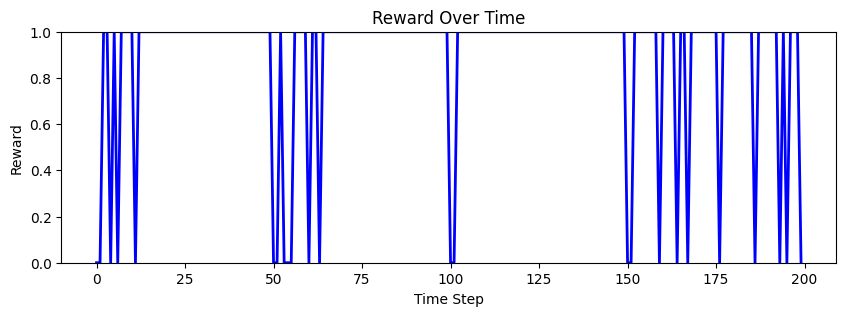


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.05  0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.26  0.23  0.26  0.25]
Step 2:   	True state: 1, Obs.: [-0.83 -0.12], Action: 1, Reward: 1.0, Action probs.: [ 0.45  0.14  0.17  0.24]
Step 3:   	True state: 1, Obs.: [-0.93  0.31], Action: 1, Reward: 1.0, Action probs.: [ 0.19  0.66  0.09  0.06]
Step 4:   	True state: 1, Obs.: [-0.88 -0.22], Action: 0, Reward: 0.0, Action probs.: [ 0.08  0.83  0.03  0.07]
Step 5:   	True state: 1, Obs.: [-0.81  0.24], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.87  0.02  0.04]
Step 6:   	True state: 1, Obs.: [-1.20  0.12], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.92  0.02  0.04]
Step 7:   	True state: 1, Obs.: [-0.96  0.00], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.89  0.04  0.04]
Step 8:   	True state: 0, Obs.: [ 0.73  0.02], Action: 0, Reward: 1.0, Action probs.: [ 0.81  0.08  0.07  0.04]
Step 9:   	True state: 

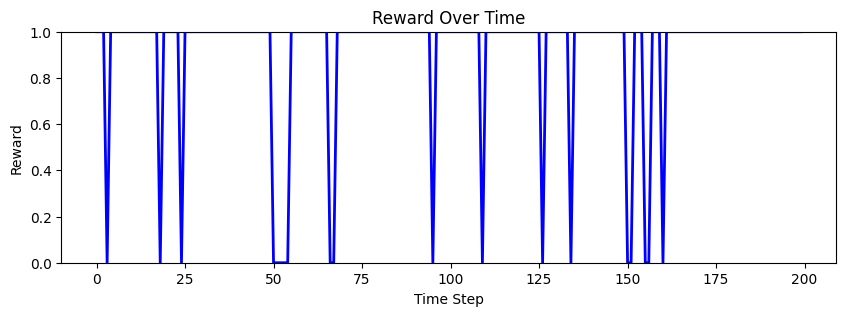


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.03  0.07], Action: 1, Reward: 1.0, Action probs.: [ 0.26  0.21  0.29  0.24]
Step 2:   	True state: 1, Obs.: [-1.03  0.05], Action: 1, Reward: 1.0, Action probs.: [ 0.09  0.77  0.06  0.08]
Step 3:   	True state: 1, Obs.: [-1.23  0.20], Action: 1, Reward: 1.0, Action probs.: [ 0.08  0.80  0.05  0.06]
Step 4:   	True state: 0, Obs.: [ 1.08  0.13], Action: 1, Reward: 0.0, Action probs.: [ 0.28  0.28  0.25  0.19]
Step 5:   	True state: 1, Obs.: [-0.99 -0.18], Action: 2, Reward: 0.0, Action probs.: [ 0.06  0.85  0.06  0.03]
Step 6:   	True state: 0, Obs.: [ 1.20  0.08], Action: 2, Reward: 0.0, Action probs.: [ 0.21  0.21  0.29  0.29]
Step 7:   	True state: 0, Obs.: [ 1.07 -0.28], Action: 0, Reward: 1.0, Action probs.: [ 0.25  0.19  0.20  0.36]
Step 8:   	True state: 1, Obs.: [-0.93  0.02], Action: 0, Reward: 0.0, Action probs.: [ 0.09  0.83  0.02  0.05]
Step 9:   	True state: 

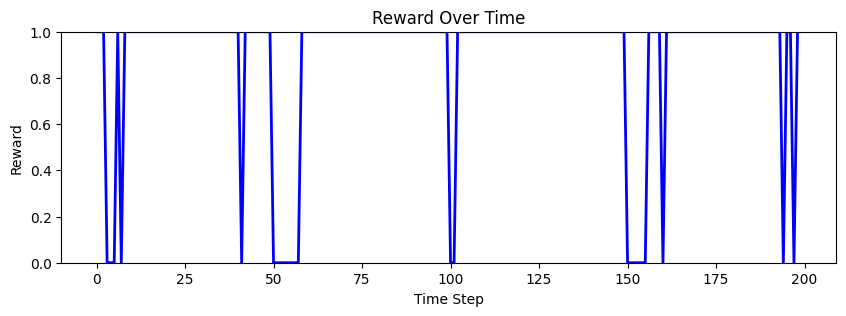


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.12  0.16], Action: 0, Reward: 1.0, Action probs.: [ 0.26  0.24  0.28  0.22]
Step 2:   	True state: 1, Obs.: [-0.88 -0.01], Action: 2, Reward: 0.0, Action probs.: [ 0.38  0.17  0.21  0.24]
Step 3:   	True state: 0, Obs.: [ 1.02  0.12], Action: 0, Reward: 1.0, Action probs.: [ 0.78  0.08  0.05  0.08]
Step 4:   	True state: 1, Obs.: [-0.75  0.03], Action: 0, Reward: 0.0, Action probs.: [ 0.30  0.24  0.15  0.31]
Step 5:   	True state: 0, Obs.: [ 1.05 -0.09], Action: 0, Reward: 1.0, Action probs.: [ 0.89  0.03  0.05  0.04]
Step 6:   	True state: 1, Obs.: [-1.08  0.05], Action: 1, Reward: 1.0, Action probs.: [ 0.23  0.30  0.23  0.24]
Step 7:   	True state: 1, Obs.: [-1.16  0.12], Action: 1, Reward: 1.0, Action probs.: [ 0.01  0.93  0.02  0.03]
Step 8:   	True state: 0, Obs.: [ 0.79 -0.51], Action: 0, Reward: 1.0, Action probs.: [ 0.93  0.04  0.03  0.01]
Step 9:   	True state: 

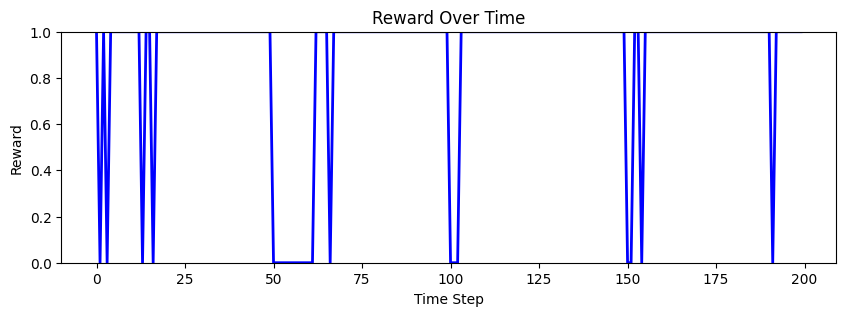


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.94 -0.10], Action: 0, Reward: 1.0, Action probs.: [ 0.25  0.24  0.26  0.24]
Step 2:   	True state: 1, Obs.: [-0.96 -0.11], Action: 2, Reward: 0.0, Action probs.: [ 0.46  0.18  0.17  0.18]
Step 3:   	True state: 0, Obs.: [ 0.99  0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.75  0.08  0.07  0.10]
Step 4:   	True state: 1, Obs.: [-1.04  0.05], Action: 0, Reward: 0.0, Action probs.: [ 0.36  0.20  0.18  0.25]
Step 5:   	True state: 1, Obs.: [-0.86 -0.29], Action: 0, Reward: 0.0, Action probs.: [ 0.21  0.32  0.17  0.30]
Step 6:   	True state: 0, Obs.: [ 0.99  0.07], Action: 0, Reward: 1.0, Action probs.: [ 0.87  0.02  0.05  0.06]
Step 7:   	True state: 1, Obs.: [-0.93  0.17], Action: 3, Reward: 0.0, Action probs.: [ 0.21  0.28  0.22  0.29]
Step 8:   	True state: 1, Obs.: [-1.20 -0.05], Action: 2, Reward: 0.0, Action probs.: [ 0.19  0.39  0.27  0.15]
Step 9:   	True state: 

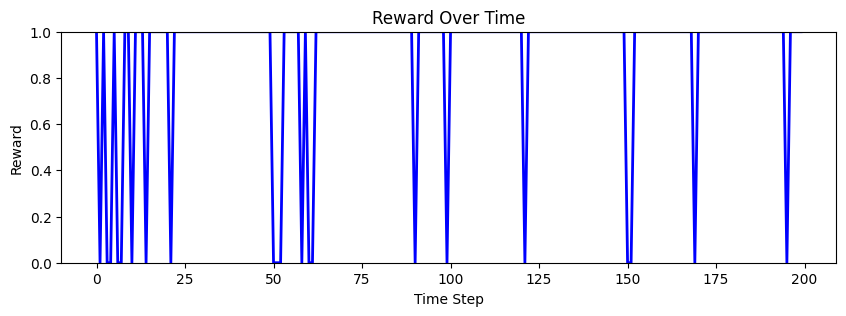


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.09  0.10], Action: 0, Reward: 0.0, Action probs.: [ 0.30  0.18  0.28  0.24]
Step 2:   	True state: 0, Obs.: [ 0.87  0.27], Action: 3, Reward: 0.0, Action probs.: [ 0.19  0.28  0.28  0.25]
Step 3:   	True state: 0, Obs.: [ 0.99 -0.06], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.23  0.32  0.21]
Step 4:   	True state: 0, Obs.: [ 1.05  0.13], Action: 1, Reward: 0.0, Action probs.: [ 0.32  0.27  0.17  0.24]
Step 5:   	True state: 1, Obs.: [-1.27 -0.04], Action: 0, Reward: 0.0, Action probs.: [ 0.23  0.25  0.28  0.24]
Step 6:   	True state: 1, Obs.: [-1.25  0.05], Action: 1, Reward: 1.0, Action probs.: [ 0.16  0.21  0.31  0.31]
Step 7:   	True state: 0, Obs.: [ 1.10  0.15], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.24  0.25  0.26]
Step 8:   	True state: 0, Obs.: [ 1.03  0.15], Action: 1, Reward: 0.0, Action probs.: [ 0.28  0.30  0.19  0.23]
Step 9:   	True state: 

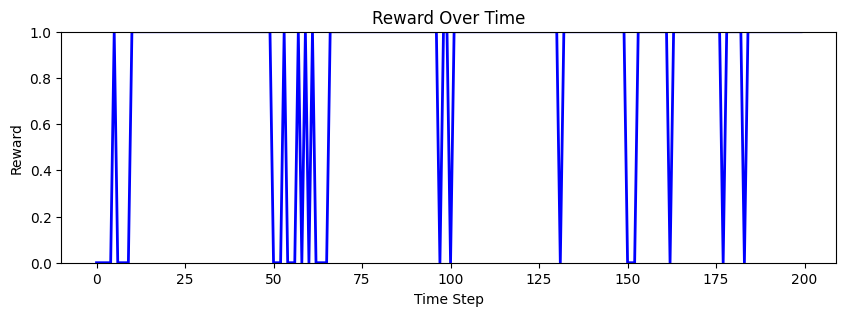


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.13 -0.04], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.25  0.27  0.24]
Step 2:   	True state: 0, Obs.: [ 1.07 -0.23], Action: 1, Reward: 0.0, Action probs.: [ 0.33  0.24  0.17  0.25]
Step 3:   	True state: 1, Obs.: [-1.15 -0.00], Action: 0, Reward: 0.0, Action probs.: [ 0.26  0.26  0.22  0.27]
Step 4:   	True state: 1, Obs.: [-0.80 -0.04], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.24  0.26  0.26]
Step 5:   	True state: 1, Obs.: [-0.99  0.07], Action: 3, Reward: 0.0, Action probs.: [ 0.22  0.28  0.22  0.28]
Step 6:   	True state: 0, Obs.: [ 1.15 -0.08], Action: 3, Reward: 0.0, Action probs.: [ 0.28  0.23  0.21  0.28]
Step 7:   	True state: 1, Obs.: [-1.03 -0.15], Action: 0, Reward: 0.0, Action probs.: [ 0.20  0.29  0.25  0.25]
Step 8:   	True state: 0, Obs.: [ 1.06 -0.19], Action: 3, Reward: 0.0, Action probs.: [ 0.28  0.25  0.25  0.23]
Step 9:   	True state: 

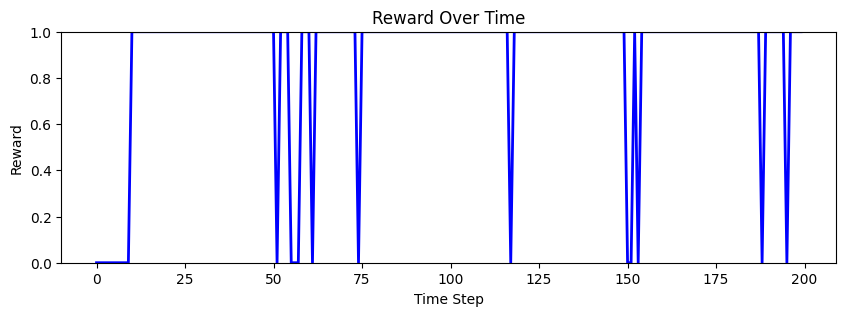


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.13  0.04], Action: 0, Reward: 1.0, Action probs.: [ 0.21  0.30  0.24  0.25]
Step 2:   	True state: 1, Obs.: [-1.06 -0.04], Action: 0, Reward: 0.0, Action probs.: [ 0.42  0.18  0.24  0.17]
Step 3:   	True state: 0, Obs.: [ 1.12 -0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.78  0.10  0.04  0.08]
Step 4:   	True state: 1, Obs.: [-1.05 -0.20], Action: 2, Reward: 0.0, Action probs.: [ 0.21  0.32  0.23  0.24]
Step 5:   	True state: 0, Obs.: [ 0.70  0.05], Action: 0, Reward: 1.0, Action probs.: [ 0.84  0.06  0.04  0.06]
Step 6:   	True state: 1, Obs.: [-0.98  0.15], Action: 0, Reward: 0.0, Action probs.: [ 0.24  0.30  0.24  0.22]
Step 7:   	True state: 1, Obs.: [-0.98 -0.18], Action: 0, Reward: 0.0, Action probs.: [ 0.25  0.27  0.23  0.24]
Step 8:   	True state: 1, Obs.: [-0.80 -0.01], Action: 3, Reward: 0.0, Action probs.: [ 0.21  0.30  0.20  0.29]
Step 9:   	True state: 

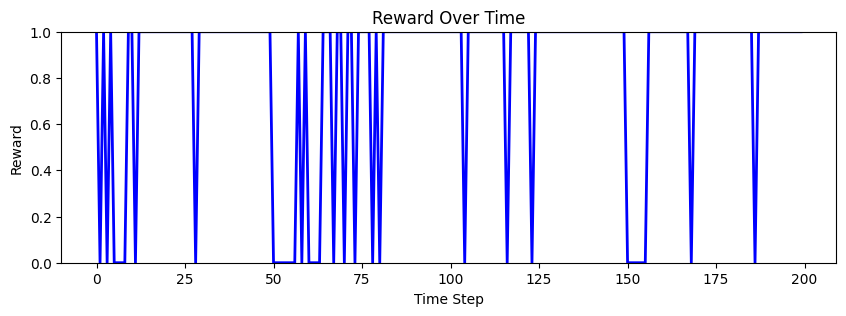


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.33 -0.04], Action: 3, Reward: 0.0, Action probs.: [ 0.24  0.19  0.29  0.28]
Step 2:   	True state: 0, Obs.: [ 1.03  0.08], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.23  0.28  0.22]
Step 3:   	True state: 1, Obs.: [-1.11 -0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.23  0.28  0.24  0.25]
Step 4:   	True state: 0, Obs.: [ 0.95  0.07], Action: 3, Reward: 0.0, Action probs.: [ 0.28  0.29  0.22  0.21]
Step 5:   	True state: 1, Obs.: [-1.34 -0.11], Action: 1, Reward: 1.0, Action probs.: [ 0.08  0.83  0.03  0.05]
Step 6:   	True state: 1, Obs.: [-1.13 -0.18], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.87  0.05  0.03]
Step 7:   	True state: 0, Obs.: [ 0.86  0.04], Action: 1, Reward: 0.0, Action probs.: [ 0.32  0.28  0.22  0.18]
Step 8:   	True state: 1, Obs.: [-0.96 -0.01], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.89  0.02  0.05]
Step 9:   	True state: 

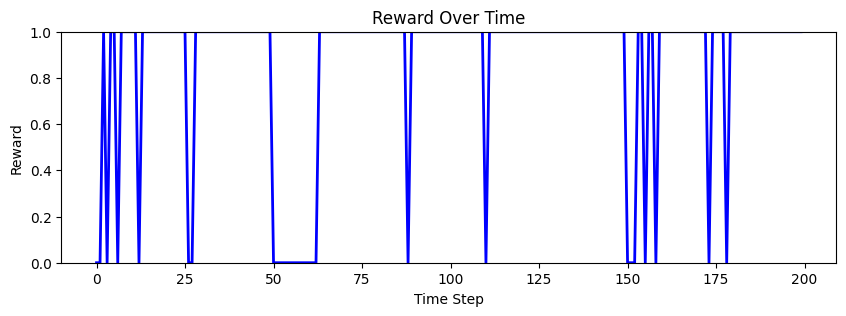


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.05 -0.25], Action: 2, Reward: 0.0, Action probs.: [ 0.23  0.24  0.30  0.24]
Step 2:   	True state: 0, Obs.: [ 0.76 -0.18], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.28  0.27  0.21]
Step 3:   	True state: 0, Obs.: [ 0.97  0.10], Action: 1, Reward: 0.0, Action probs.: [ 0.30  0.28  0.15  0.28]
Step 4:   	True state: 1, Obs.: [-1.22 -0.10], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.25  0.22  0.26]
Step 5:   	True state: 1, Obs.: [-0.82  0.16], Action: 0, Reward: 0.0, Action probs.: [ 0.28  0.26  0.19  0.27]
Step 6:   	True state: 1, Obs.: [-1.29 -0.19], Action: 2, Reward: 0.0, Action probs.: [ 0.20  0.32  0.18  0.30]
Step 7:   	True state: 1, Obs.: [-1.07 -0.06], Action: 3, Reward: 0.0, Action probs.: [ 0.21  0.29  0.21  0.30]
Step 8:   	True state: 0, Obs.: [ 0.96  0.15], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.27  0.16  0.30]
Step 9:   	True state: 

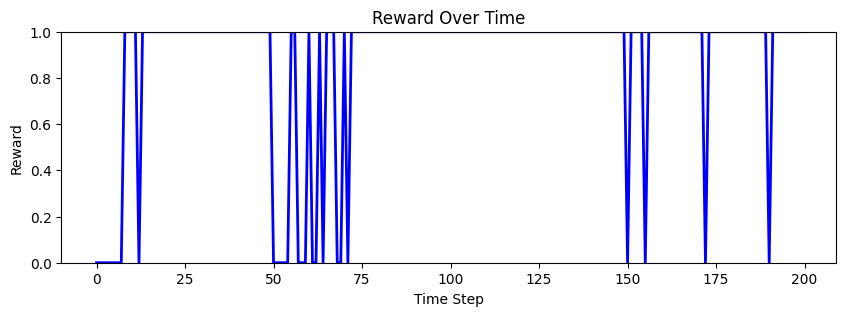


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.99 -0.18], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.22  0.24  0.27]
Step 2:   	True state: 0, Obs.: [ 0.79 -0.08], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.32  0.28  0.18]
Step 3:   	True state: 1, Obs.: [-1.06 -0.10], Action: 3, Reward: 0.0, Action probs.: [ 0.22  0.24  0.26  0.28]
Step 4:   	True state: 1, Obs.: [-0.81  0.16], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.29  0.24  0.20]
Step 5:   	True state: 0, Obs.: [ 1.00  0.17], Action: 3, Reward: 0.0, Action probs.: [ 0.30  0.31  0.22  0.18]
Step 6:   	True state: 1, Obs.: [-0.95  0.01], Action: 3, Reward: 0.0, Action probs.: [ 0.24  0.26  0.27  0.23]
Step 7:   	True state: 1, Obs.: [-1.00 -0.07], Action: 0, Reward: 0.0, Action probs.: [ 0.31  0.25  0.28  0.15]
Step 8:   	True state: 1, Obs.: [-1.19  0.21], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.26  0.33  0.18]
Step 9:   	True state: 

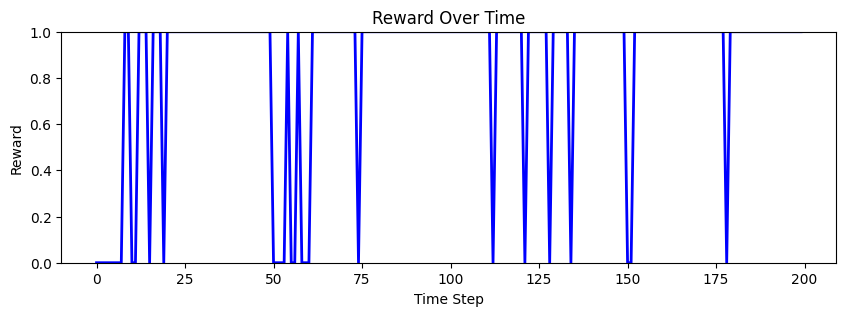


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.81  0.18], Action: 1, Reward: 0.0, Action probs.: [ 0.25  0.20  0.26  0.29]
Step 2:   	True state: 1, Obs.: [-1.11  0.10], Action: 0, Reward: 0.0, Action probs.: [ 0.21  0.26  0.26  0.27]
Step 3:   	True state: 1, Obs.: [-1.17  0.07], Action: 0, Reward: 0.0, Action probs.: [ 0.20  0.26  0.29  0.24]
Step 4:   	True state: 1, Obs.: [-1.00 -0.03], Action: 2, Reward: 0.0, Action probs.: [ 0.16  0.30  0.28  0.26]
Step 5:   	True state: 0, Obs.: [ 0.93  0.04], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.17  0.25  0.31]
Step 6:   	True state: 0, Obs.: [ 0.72 -0.42], Action: 0, Reward: 1.0, Action probs.: [ 0.24  0.26  0.21  0.30]
Step 7:   	True state: 1, Obs.: [-1.01 -0.01], Action: 0, Reward: 0.0, Action probs.: [ 0.23  0.24  0.23  0.30]
Step 8:   	True state: 1, Obs.: [-0.96 -0.01], Action: 1, Reward: 1.0, Action probs.: [ 0.19  0.26  0.25  0.29]
Step 9:   	True state: 

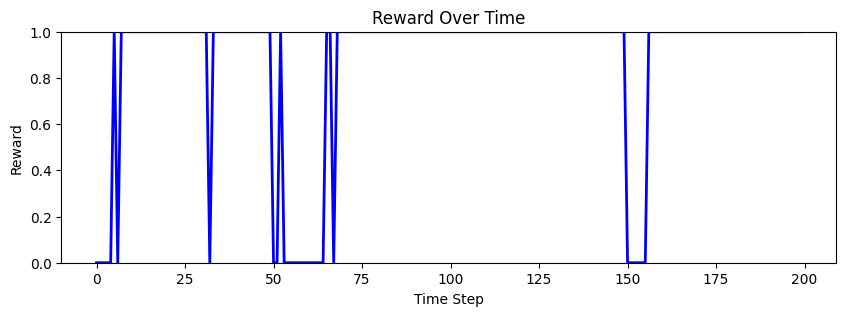


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.05 -0.14], Action: 1, Reward: 1.0, Action probs.: [ 0.27  0.23  0.26  0.24]
Step 2:   	True state: 0, Obs.: [ 0.93 -0.17], Action: 3, Reward: 0.0, Action probs.: [ 0.16  0.44  0.17  0.23]
Step 3:   	True state: 0, Obs.: [ 0.87  0.07], Action: 3, Reward: 0.0, Action probs.: [ 0.17  0.41  0.24  0.18]
Step 4:   	True state: 1, Obs.: [-0.86 -0.27], Action: 1, Reward: 1.0, Action probs.: [ 0.06  0.80  0.09  0.04]
Step 5:   	True state: 0, Obs.: [ 0.95 -0.20], Action: 1, Reward: 0.0, Action probs.: [ 0.22  0.29  0.30  0.19]
Step 6:   	True state: 1, Obs.: [-1.03 -0.02], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.89  0.04  0.03]
Step 7:   	True state: 0, Obs.: [ 1.11 -0.05], Action: 0, Reward: 1.0, Action probs.: [ 0.30  0.18  0.34  0.18]
Step 8:   	True state: 0, Obs.: [ 0.88 -0.07], Action: 0, Reward: 1.0, Action probs.: [ 0.93  0.03  0.04  0.01]
Step 9:   	True state: 

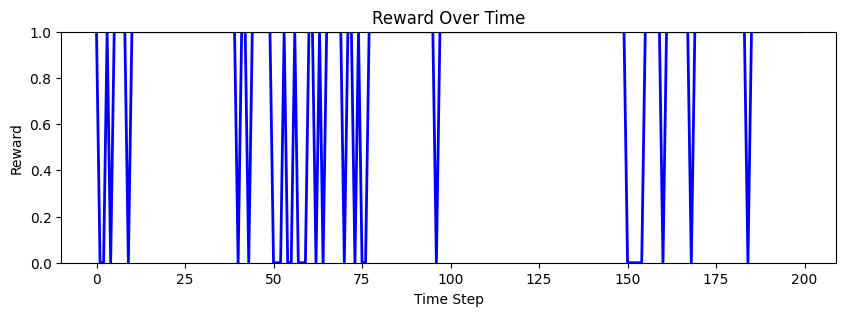


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.96  0.18], Action: 3, Reward: 0.0, Action probs.: [ 0.26  0.26  0.24  0.24]
Step 2:   	True state: 0, Obs.: [ 1.00 -0.04], Action: 3, Reward: 0.0, Action probs.: [ 0.30  0.22  0.28  0.20]
Step 3:   	True state: 1, Obs.: [-0.74 -0.02], Action: 0, Reward: 0.0, Action probs.: [ 0.23  0.26  0.30  0.21]
Step 4:   	True state: 1, Obs.: [-0.88 -0.29], Action: 2, Reward: 0.0, Action probs.: [ 0.20  0.31  0.20  0.30]
Step 5:   	True state: 1, Obs.: [-1.23 -0.01], Action: 2, Reward: 0.0, Action probs.: [ 0.21  0.32  0.23  0.25]
Step 6:   	True state: 1, Obs.: [-1.13  0.08], Action: 1, Reward: 1.0, Action probs.: [ 0.20  0.27  0.20  0.34]
Step 7:   	True state: 0, Obs.: [ 0.91  0.15], Action: 1, Reward: 0.0, Action probs.: [ 0.27  0.36  0.21  0.15]
Step 8:   	True state: 1, Obs.: [-0.90  0.09], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.90  0.02  0.05]
Step 9:   	True state: 

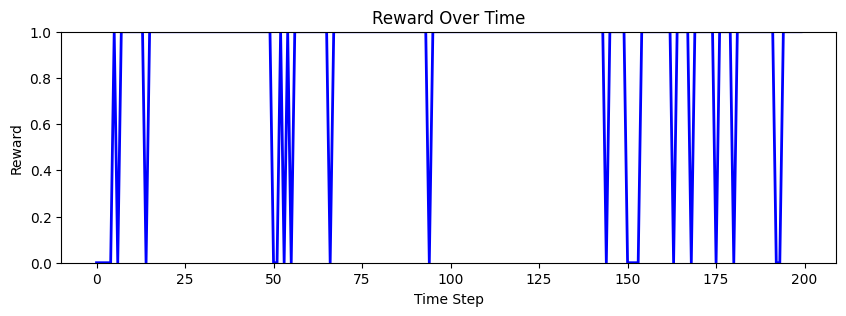


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.03 -0.19], Action: 1, Reward: 0.0, Action probs.: [ 0.26  0.25  0.23  0.26]
Step 2:   	True state: 1, Obs.: [-1.04 -0.14], Action: 0, Reward: 0.0, Action probs.: [ 0.26  0.21  0.25  0.28]
Step 3:   	True state: 1, Obs.: [-0.99 -0.05], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.25  0.26  0.27]
Step 4:   	True state: 1, Obs.: [-0.93 -0.23], Action: 2, Reward: 0.0, Action probs.: [ 0.20  0.28  0.22  0.30]
Step 5:   	True state: 0, Obs.: [ 0.96  0.01], Action: 2, Reward: 0.0, Action probs.: [ 0.30  0.17  0.24  0.28]
Step 6:   	True state: 0, Obs.: [ 1.21  0.10], Action: 0, Reward: 1.0, Action probs.: [ 0.28  0.24  0.18  0.30]
Step 7:   	True state: 0, Obs.: [ 1.06 -0.14], Action: 0, Reward: 1.0, Action probs.: [ 0.88  0.03  0.02  0.06]
Step 8:   	True state: 0, Obs.: [ 0.82  0.10], Action: 3, Reward: 0.0, Action probs.: [ 0.90  0.03  0.03  0.04]
Step 9:   	True state: 

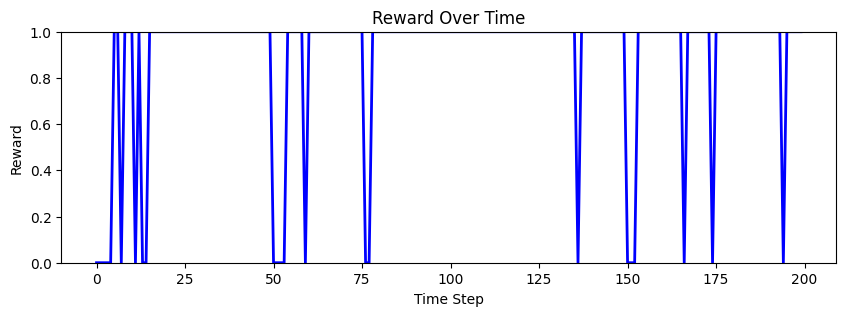


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.93  0.06], Action: 3, Reward: 0.0, Action probs.: [ 0.25  0.28  0.24  0.24]
Step 2:   	True state: 1, Obs.: [-0.90  0.02], Action: 1, Reward: 1.0, Action probs.: [ 0.26  0.23  0.30  0.22]
Step 3:   	True state: 0, Obs.: [ 0.69 -0.13], Action: 1, Reward: 0.0, Action probs.: [ 0.12  0.53  0.17  0.18]
Step 4:   	True state: 0, Obs.: [ 0.91  0.05], Action: 3, Reward: 0.0, Action probs.: [ 0.19  0.29  0.24  0.28]
Step 5:   	True state: 0, Obs.: [ 0.87 -0.16], Action: 0, Reward: 1.0, Action probs.: [ 0.28  0.25  0.24  0.23]
Step 6:   	True state: 0, Obs.: [ 0.97 -0.14], Action: 0, Reward: 1.0, Action probs.: [ 0.86  0.05  0.08  0.01]
Step 7:   	True state: 0, Obs.: [ 0.74  0.05], Action: 0, Reward: 1.0, Action probs.: [ 0.89  0.03  0.06  0.02]
Step 8:   	True state: 1, Obs.: [-1.12  0.10], Action: 1, Reward: 1.0, Action probs.: [ 0.05  0.85  0.06  0.04]
Step 9:   	True state: 

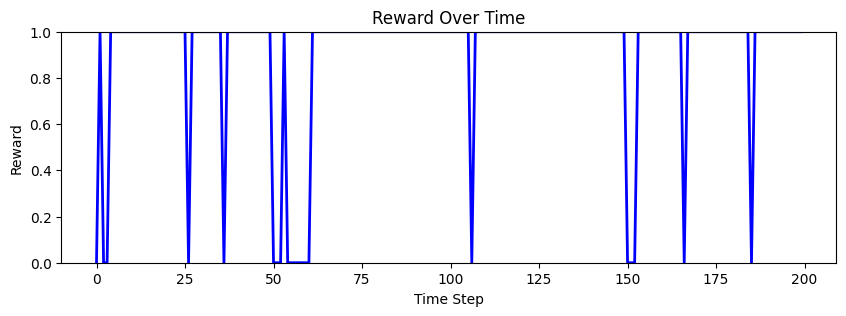


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.00 -0.13], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.25  0.26  0.23]
Step 2:   	True state: 0, Obs.: [ 1.15 -0.08], Action: 3, Reward: 0.0, Action probs.: [ 0.30  0.25  0.17  0.28]
Step 3:   	True state: 0, Obs.: [ 1.00  0.02], Action: 1, Reward: 0.0, Action probs.: [ 0.26  0.27  0.20  0.27]
Step 4:   	True state: 1, Obs.: [-1.08 -0.06], Action: 0, Reward: 0.0, Action probs.: [ 0.26  0.22  0.23  0.30]
Step 5:   	True state: 0, Obs.: [ 1.01  0.08], Action: 0, Reward: 1.0, Action probs.: [ 0.33  0.21  0.21  0.25]
Step 6:   	True state: 1, Obs.: [-1.01 -0.16], Action: 1, Reward: 1.0, Action probs.: [ 0.18  0.31  0.23  0.28]
Step 7:   	True state: 1, Obs.: [-0.96  0.19], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.88  0.08  0.02]
Step 8:   	True state: 0, Obs.: [ 1.09  0.07], Action: 0, Reward: 1.0, Action probs.: [ 0.91  0.02  0.04  0.03]
Step 9:   	True state: 

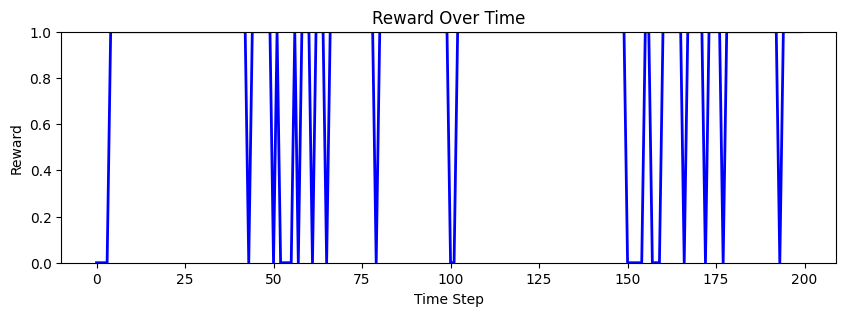


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.13 -0.20], Action: 1, Reward: 0.0, Action probs.: [ 0.29  0.24  0.21  0.26]
Step 2:   	True state: 1, Obs.: [-1.16  0.23], Action: 0, Reward: 0.0, Action probs.: [ 0.25  0.26  0.28  0.20]
Step 3:   	True state: 1, Obs.: [-0.93  0.13], Action: 2, Reward: 0.0, Action probs.: [ 0.21  0.23  0.28  0.28]
Step 4:   	True state: 1, Obs.: [-0.95 -0.07], Action: 1, Reward: 1.0, Action probs.: [ 0.22  0.26  0.22  0.30]
Step 5:   	True state: 1, Obs.: [-1.10  0.16], Action: 3, Reward: 0.0, Action probs.: [ 0.03  0.86  0.04  0.08]
Step 6:   	True state: 1, Obs.: [-0.96 -0.09], Action: 1, Reward: 1.0, Action probs.: [ 0.03  0.91  0.02  0.03]
Step 7:   	True state: 0, Obs.: [ 0.94  0.02], Action: 1, Reward: 0.0, Action probs.: [ 0.29  0.20  0.26  0.25]
Step 8:   	True state: 0, Obs.: [ 1.23  0.19], Action: 0, Reward: 1.0, Action probs.: [ 0.23  0.25  0.28  0.24]
Step 9:   	True state: 

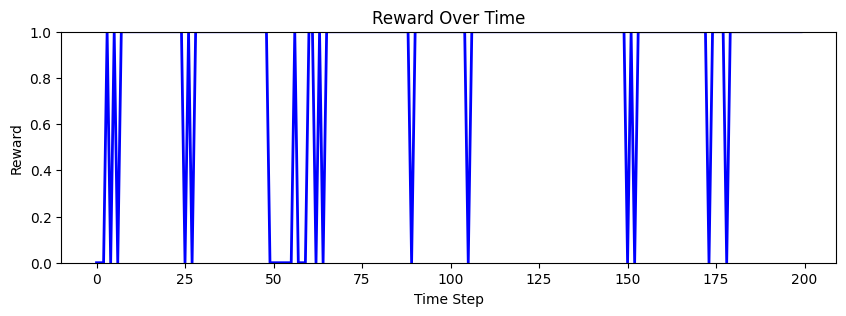


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.97  0.08], Action: 2, Reward: 0.0, Action probs.: [ 0.19  0.26  0.26  0.29]
Step 2:   	True state: 1, Obs.: [-0.72 -0.16], Action: 0, Reward: 0.0, Action probs.: [ 0.28  0.28  0.21  0.23]
Step 3:   	True state: 0, Obs.: [ 0.88  0.05], Action: 1, Reward: 0.0, Action probs.: [ 0.28  0.21  0.26  0.26]
Step 4:   	True state: 0, Obs.: [ 0.85  0.06], Action: 3, Reward: 0.0, Action probs.: [ 0.25  0.23  0.24  0.28]
Step 5:   	True state: 0, Obs.: [ 1.09  0.00], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.26  0.28  0.20]
Step 6:   	True state: 1, Obs.: [-1.01  0.14], Action: 1, Reward: 1.0, Action probs.: [ 0.16  0.31  0.23  0.30]
Step 7:   	True state: 0, Obs.: [ 1.26  0.02], Action: 0, Reward: 1.0, Action probs.: [ 0.28  0.25  0.19  0.27]
Step 8:   	True state: 1, Obs.: [-0.98 -0.20], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.90  0.04  0.04]
Step 9:   	True state: 

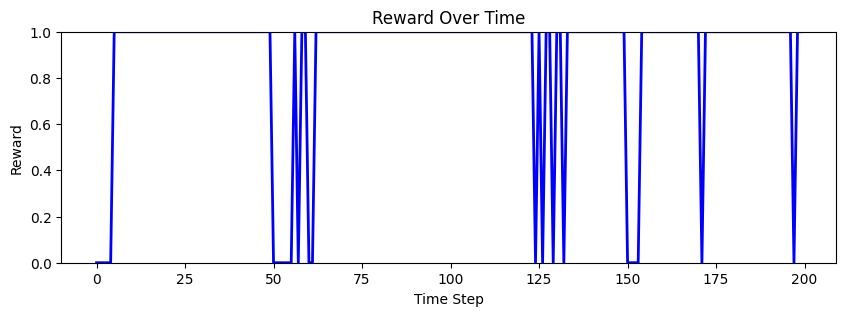


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.97  0.00], Action: 0, Reward: 1.0, Action probs.: [ 0.26  0.25  0.25  0.25]
Step 2:   	True state: 1, Obs.: [-1.12  0.04], Action: 3, Reward: 0.0, Action probs.: [ 0.46  0.18  0.17  0.19]
Step 3:   	True state: 0, Obs.: [ 0.79 -0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.81  0.06  0.04  0.09]
Step 4:   	True state: 0, Obs.: [ 1.12  0.19], Action: 3, Reward: 0.0, Action probs.: [ 0.81  0.04  0.06  0.08]
Step 5:   	True state: 1, Obs.: [-0.88 -0.21], Action: 0, Reward: 0.0, Action probs.: [ 0.41  0.20  0.22  0.18]
Step 6:   	True state: 1, Obs.: [-0.87 -0.01], Action: 1, Reward: 1.0, Action probs.: [ 0.24  0.37  0.18  0.22]
Step 7:   	True state: 0, Obs.: [ 1.07 -0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.91  0.05  0.04  0.00]
Step 8:   	True state: 1, Obs.: [-1.03  0.19], Action: 1, Reward: 1.0, Action probs.: [ 0.03  0.91  0.06  0.00]
Step 9:   	True state: 

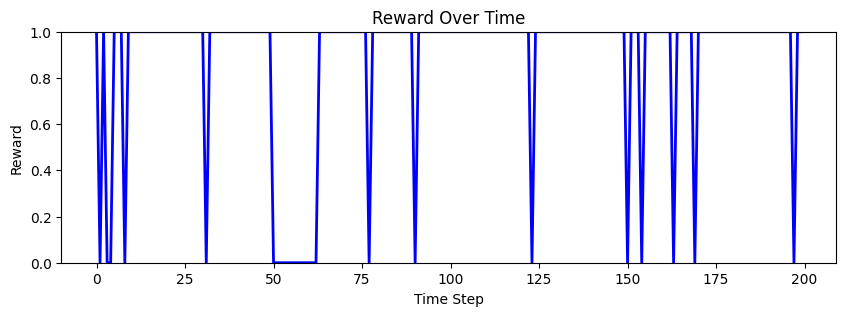


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.05 -0.17], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.30  0.21  0.25]
Step 2:   	True state: 1, Obs.: [-1.31  0.04], Action: 0, Reward: 0.0, Action probs.: [ 0.23  0.34  0.18  0.25]
Step 3:   	True state: 1, Obs.: [-1.01 -0.14], Action: 1, Reward: 1.0, Action probs.: [ 0.20  0.29  0.22  0.28]
Step 4:   	True state: 1, Obs.: [-1.02  0.07], Action: 1, Reward: 1.0, Action probs.: [ 0.06  0.82  0.03  0.09]
Step 5:   	True state: 1, Obs.: [-1.00  0.15], Action: 1, Reward: 1.0, Action probs.: [ 0.03  0.89  0.04  0.04]
Step 6:   	True state: 0, Obs.: [ 0.73  0.13], Action: 0, Reward: 1.0, Action probs.: [ 0.24  0.33  0.22  0.21]
Step 7:   	True state: 0, Obs.: [ 1.15 -0.13], Action: 0, Reward: 1.0, Action probs.: [ 0.82  0.06  0.06  0.05]
Step 8:   	True state: 0, Obs.: [ 1.07 -0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.88  0.04  0.05  0.03]
Step 9:   	True state: 

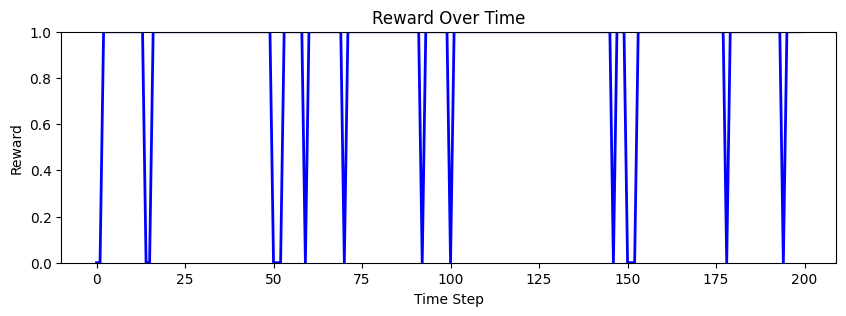


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.95 -0.07], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.24  0.27  0.24]
Step 2:   	True state: 0, Obs.: [ 1.28  0.09], Action: 1, Reward: 0.0, Action probs.: [ 0.26  0.25  0.23  0.26]
Step 3:   	True state: 0, Obs.: [ 0.84  0.02], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.22  0.22  0.30]
Step 4:   	True state: 0, Obs.: [ 1.02 -0.03], Action: 1, Reward: 0.0, Action probs.: [ 0.33  0.27  0.17  0.22]
Step 5:   	True state: 0, Obs.: [ 0.90  0.01], Action: 3, Reward: 0.0, Action probs.: [ 0.32  0.18  0.29  0.21]
Step 6:   	True state: 1, Obs.: [-1.06  0.06], Action: 3, Reward: 0.0, Action probs.: [ 0.33  0.22  0.22  0.23]
Step 7:   	True state: 0, Obs.: [ 1.08  0.02], Action: 1, Reward: 0.0, Action probs.: [ 0.36  0.24  0.22  0.19]
Step 8:   	True state: 0, Obs.: [ 0.90 -0.12], Action: 3, Reward: 0.0, Action probs.: [ 0.28  0.23  0.26  0.23]
Step 9:   	True state: 

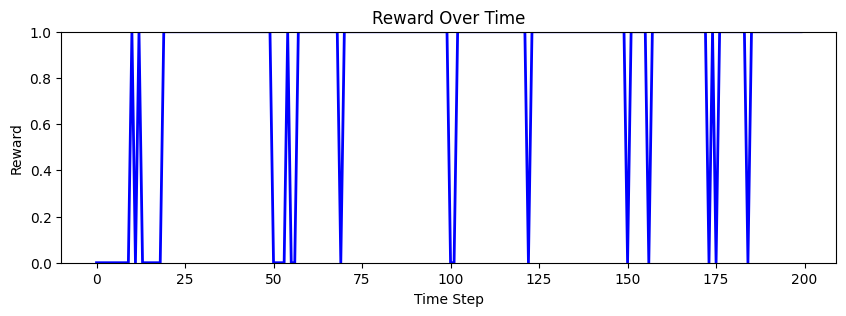


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.06  0.05], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.24  0.26  0.23]
Step 2:   	True state: 0, Obs.: [ 1.16  0.14], Action: 0, Reward: 1.0, Action probs.: [ 0.30  0.21  0.21  0.28]
Step 3:   	True state: 0, Obs.: [ 1.04 -0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.81  0.07  0.03  0.10]
Step 4:   	True state: 0, Obs.: [ 0.92  0.08], Action: 2, Reward: 0.0, Action probs.: [ 0.85  0.06  0.05  0.04]
Step 5:   	True state: 1, Obs.: [-1.05  0.05], Action: 3, Reward: 0.0, Action probs.: [ 0.29  0.25  0.19  0.27]
Step 6:   	True state: 0, Obs.: [ 1.01 -0.07], Action: 0, Reward: 1.0, Action probs.: [ 0.89  0.04  0.01  0.06]
Step 7:   	True state: 0, Obs.: [ 1.02  0.00], Action: 0, Reward: 1.0, Action probs.: [ 0.92  0.04  0.02  0.03]
Step 8:   	True state: 0, Obs.: [ 1.17 -0.08], Action: 0, Reward: 1.0, Action probs.: [ 0.92  0.03  0.01  0.04]
Step 9:   	True state: 

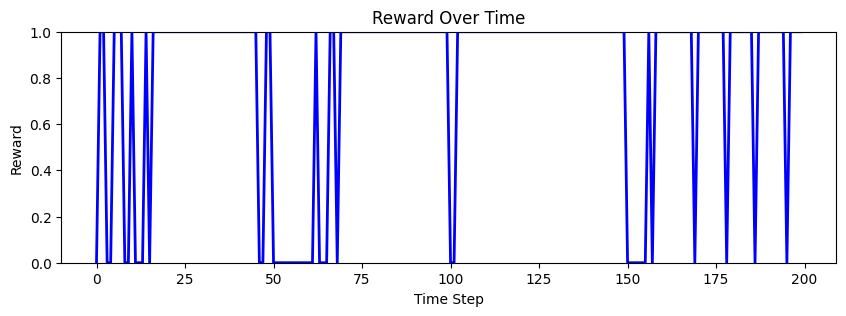


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.97 -0.08], Action: 1, Reward: 0.0, Action probs.: [ 0.23  0.29  0.22  0.26]
Step 2:   	True state: 1, Obs.: [-1.09 -0.01], Action: 0, Reward: 0.0, Action probs.: [ 0.24  0.25  0.24  0.26]
Step 3:   	True state: 1, Obs.: [-0.96 -0.11], Action: 1, Reward: 1.0, Action probs.: [ 0.22  0.29  0.22  0.27]
Step 4:   	True state: 0, Obs.: [ 0.93 -0.03], Action: 0, Reward: 1.0, Action probs.: [ 0.30  0.19  0.27  0.24]
Step 5:   	True state: 1, Obs.: [-1.31  0.17], Action: 1, Reward: 1.0, Action probs.: [ 0.06  0.81  0.07  0.07]
Step 6:   	True state: 1, Obs.: [-0.84  0.21], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.84  0.07  0.06]
Step 7:   	True state: 1, Obs.: [-1.21  0.09], Action: 1, Reward: 1.0, Action probs.: [ 0.01  0.93  0.03  0.03]
Step 8:   	True state: 1, Obs.: [-1.15 -0.20], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.93  0.02  0.03]
Step 9:   	True state: 

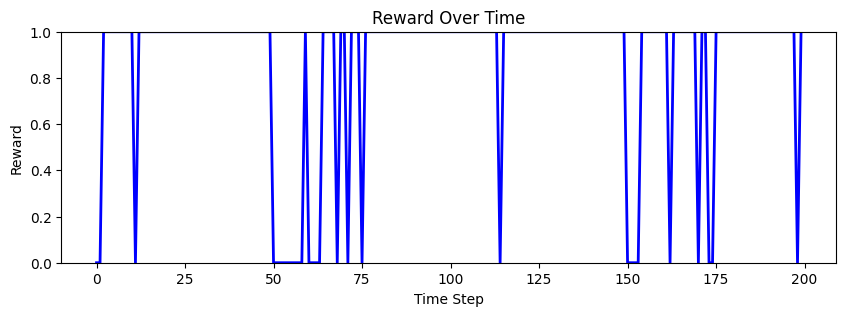


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.89 -0.06], Action: 0, Reward: 0.0, Action probs.: [ 0.26  0.26  0.23  0.25]
Step 2:   	True state: 0, Obs.: [ 0.76 -0.18], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.22  0.30  0.26]
Step 3:   	True state: 1, Obs.: [-0.87  0.13], Action: 1, Reward: 1.0, Action probs.: [ 0.18  0.28  0.30  0.24]
Step 4:   	True state: 0, Obs.: [ 1.10 -0.01], Action: 1, Reward: 0.0, Action probs.: [ 0.24  0.32  0.14  0.30]
Step 5:   	True state: 1, Obs.: [-1.13 -0.04], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.76  0.13  0.07]
Step 6:   	True state: 1, Obs.: [-1.20 -0.30], Action: 1, Reward: 1.0, Action probs.: [ 0.01  0.90  0.04  0.04]
Step 7:   	True state: 0, Obs.: [ 0.84  0.10], Action: 3, Reward: 0.0, Action probs.: [ 0.25  0.21  0.27  0.27]
Step 8:   	True state: 1, Obs.: [-0.93 -0.10], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.92  0.02  0.04]
Step 9:   	True state: 

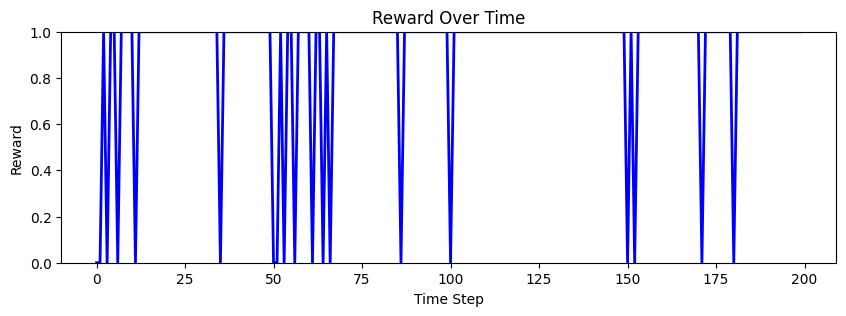


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.11 -0.12], Action: 1, Reward: 1.0, Action probs.: [ 0.20  0.28  0.28  0.23]
Step 2:   	True state: 1, Obs.: [-1.05  0.06], Action: 0, Reward: 0.0, Action probs.: [ 0.11  0.74  0.06  0.09]
Step 3:   	True state: 0, Obs.: [ 0.75 -0.04], Action: 1, Reward: 0.0, Action probs.: [ 0.17  0.34  0.26  0.23]
Step 4:   	True state: 1, Obs.: [-1.02  0.17], Action: 1, Reward: 1.0, Action probs.: [ 0.05  0.77  0.09  0.09]
Step 5:   	True state: 0, Obs.: [ 0.86  0.16], Action: 3, Reward: 0.0, Action probs.: [ 0.28  0.23  0.27  0.23]
Step 6:   	True state: 0, Obs.: [ 1.12 -0.29], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.21  0.34  0.20]
Step 7:   	True state: 0, Obs.: [ 1.09 -0.06], Action: 1, Reward: 0.0, Action probs.: [ 0.26  0.28  0.24  0.22]
Step 8:   	True state: 0, Obs.: [ 0.91 -0.07], Action: 3, Reward: 0.0, Action probs.: [ 0.30  0.24  0.26  0.20]
Step 9:   	True state: 

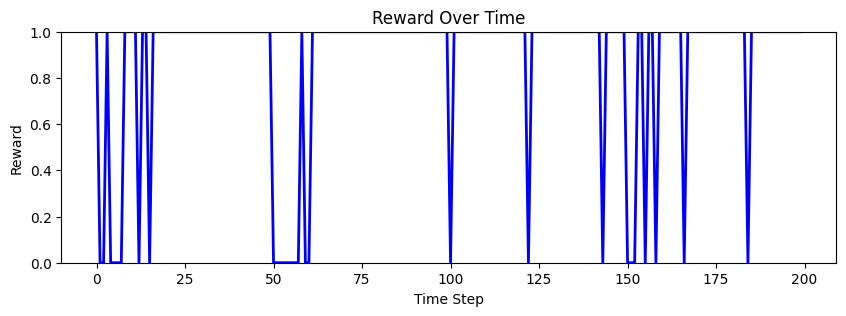


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.09 -0.01], Action: 0, Reward: 0.0, Action probs.: [ 0.20  0.30  0.20  0.30]
Step 2:   	True state: 0, Obs.: [ 1.01  0.28], Action: 3, Reward: 0.0, Action probs.: [ 0.22  0.25  0.25  0.28]
Step 3:   	True state: 0, Obs.: [ 1.02 -0.02], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.25  0.29  0.23]
Step 4:   	True state: 1, Obs.: [-0.86  0.02], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.22  0.29  0.27]
Step 5:   	True state: 0, Obs.: [ 0.91  0.15], Action: 2, Reward: 0.0, Action probs.: [ 0.28  0.35  0.19  0.17]
Step 6:   	True state: 0, Obs.: [ 0.84  0.15], Action: 0, Reward: 1.0, Action probs.: [ 0.28  0.29  0.21  0.22]
Step 7:   	True state: 0, Obs.: [ 1.03 -0.12], Action: 0, Reward: 1.0, Action probs.: [ 0.88  0.07  0.03  0.02]
Step 8:   	True state: 1, Obs.: [-0.98  0.02], Action: 0, Reward: 0.0, Action probs.: [ 0.19  0.29  0.24  0.29]
Step 9:   	True state: 

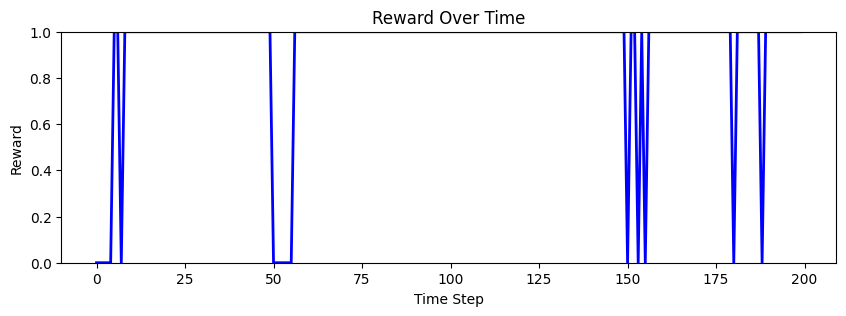


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.19  0.04], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.24  0.26  0.26]
Step 2:   	True state: 0, Obs.: [ 1.09 -0.01], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.26  0.24  0.24]
Step 3:   	True state: 0, Obs.: [ 0.96  0.09], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.24  0.16  0.33]
Step 4:   	True state: 0, Obs.: [ 0.92  0.09], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.27  0.23  0.22]
Step 5:   	True state: 1, Obs.: [-1.06 -0.05], Action: 3, Reward: 0.0, Action probs.: [ 0.32  0.24  0.19  0.24]
Step 6:   	True state: 0, Obs.: [ 0.69 -0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.28  0.33  0.20  0.19]
Step 7:   	True state: 0, Obs.: [ 0.92 -0.17], Action: 0, Reward: 1.0, Action probs.: [ 0.91  0.05  0.04  0.01]
Step 8:   	True state: 0, Obs.: [ 1.26  0.03], Action: 0, Reward: 1.0, Action probs.: [ 0.91  0.05  0.02  0.02]
Step 9:   	True state: 

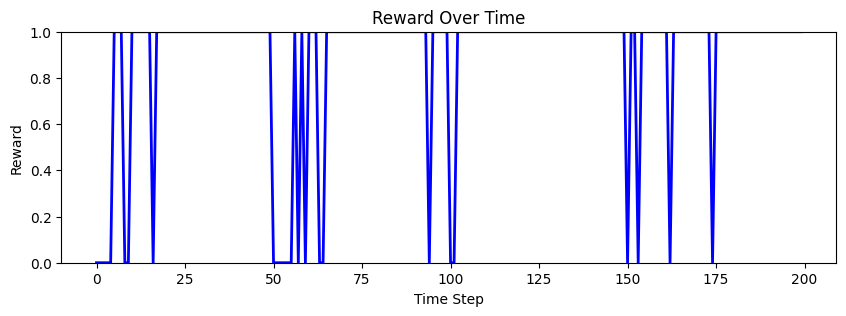


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.97 -0.06], Action: 3, Reward: 0.0, Action probs.: [ 0.24  0.25  0.26  0.24]
Step 2:   	True state: 1, Obs.: [-1.14  0.23], Action: 3, Reward: 0.0, Action probs.: [ 0.32  0.24  0.30  0.14]
Step 3:   	True state: 1, Obs.: [-0.93 -0.17], Action: 1, Reward: 1.0, Action probs.: [ 0.28  0.32  0.23  0.18]
Step 4:   	True state: 0, Obs.: [ 1.00  0.05], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.31  0.20  0.22]
Step 5:   	True state: 0, Obs.: [ 1.01  0.04], Action: 1, Reward: 0.0, Action probs.: [ 0.22  0.33  0.18  0.27]
Step 6:   	True state: 0, Obs.: [ 0.91 -0.03], Action: 3, Reward: 0.0, Action probs.: [ 0.26  0.26  0.20  0.28]
Step 7:   	True state: 1, Obs.: [-0.83  0.09], Action: 1, Reward: 1.0, Action probs.: [ 0.09  0.83  0.05  0.03]
Step 8:   	True state: 1, Obs.: [-1.10 -0.02], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.89  0.02  0.02]
Step 9:   	True state: 

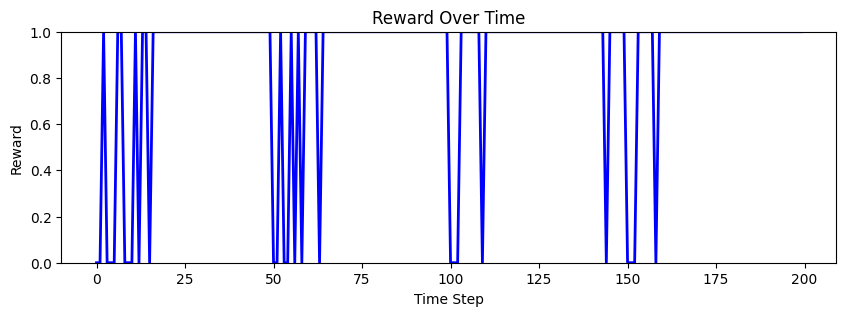


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.69 -0.14], Action: 0, Reward: 1.0, Action probs.: [ 0.26  0.20  0.28  0.26]
Step 2:   	True state: 1, Obs.: [-1.03 -0.06], Action: 2, Reward: 0.0, Action probs.: [ 0.48  0.17  0.18  0.17]
Step 3:   	True state: 0, Obs.: [ 1.10 -0.11], Action: 3, Reward: 0.0, Action probs.: [ 0.77  0.06  0.07  0.10]
Step 4:   	True state: 1, Obs.: [-0.95 -0.02], Action: 3, Reward: 0.0, Action probs.: [ 0.37  0.23  0.14  0.26]
Step 5:   	True state: 1, Obs.: [-1.17 -0.18], Action: 0, Reward: 0.0, Action probs.: [ 0.33  0.33  0.20  0.14]
Step 6:   	True state: 1, Obs.: [-0.96  0.05], Action: 0, Reward: 0.0, Action probs.: [ 0.24  0.24  0.24  0.28]
Step 7:   	True state: 1, Obs.: [-0.85 -0.08], Action: 0, Reward: 0.0, Action probs.: [ 0.23  0.29  0.21  0.27]
Step 8:   	True state: 1, Obs.: [-1.18  0.05], Action: 0, Reward: 0.0, Action probs.: [ 0.32  0.26  0.27  0.15]
Step 9:   	True state: 

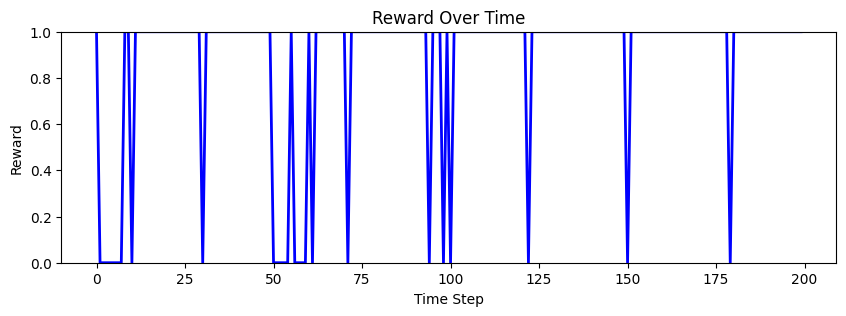


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.94 -0.07], Action: 2, Reward: 0.0, Action probs.: [ 0.20  0.22  0.26  0.31]
Step 2:   	True state: 0, Obs.: [ 0.83  0.04], Action: 1, Reward: 0.0, Action probs.: [ 0.29  0.20  0.26  0.25]
Step 3:   	True state: 0, Obs.: [ 1.03  0.07], Action: 3, Reward: 0.0, Action probs.: [ 0.29  0.23  0.25  0.24]
Step 4:   	True state: 1, Obs.: [-0.79 -0.04], Action: 1, Reward: 1.0, Action probs.: [ 0.25  0.27  0.18  0.29]
Step 5:   	True state: 0, Obs.: [ 0.96  0.16], Action: 3, Reward: 0.0, Action probs.: [ 0.28  0.24  0.29  0.20]
Step 6:   	True state: 0, Obs.: [ 0.93  0.02], Action: 1, Reward: 0.0, Action probs.: [ 0.25  0.29  0.27  0.20]
Step 7:   	True state: 0, Obs.: [ 0.92  0.23], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.20  0.35  0.18]
Step 8:   	True state: 0, Obs.: [ 0.79 -0.09], Action: 1, Reward: 0.0, Action probs.: [ 0.28  0.31  0.21  0.20]
Step 9:   	True state: 

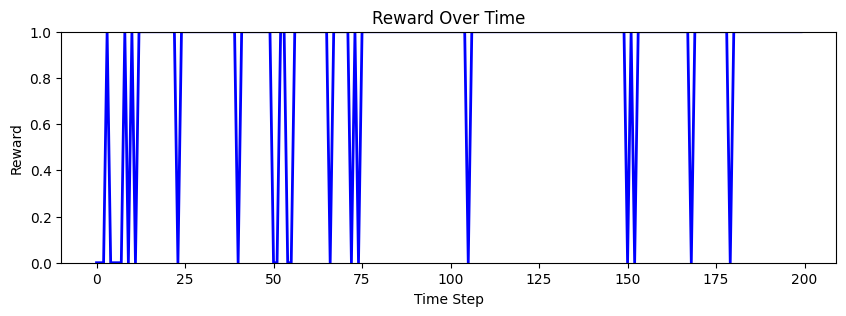


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.92  0.09], Action: 0, Reward: 1.0, Action probs.: [ 0.24  0.29  0.25  0.22]
Step 2:   	True state: 0, Obs.: [ 0.97 -0.04], Action: 1, Reward: 0.0, Action probs.: [ 0.74  0.11  0.08  0.08]
Step 3:   	True state: 0, Obs.: [ 0.79 -0.07], Action: 0, Reward: 1.0, Action probs.: [ 0.79  0.04  0.09  0.08]
Step 4:   	True state: 1, Obs.: [-1.11 -0.10], Action: 1, Reward: 1.0, Action probs.: [ 0.35  0.22  0.21  0.22]
Step 5:   	True state: 1, Obs.: [-1.09 -0.01], Action: 3, Reward: 0.0, Action probs.: [ 0.09  0.77  0.07  0.07]
Step 6:   	True state: 1, Obs.: [-1.09  0.07], Action: 1, Reward: 1.0, Action probs.: [ 0.10  0.81  0.08  0.02]
Step 7:   	True state: 0, Obs.: [ 0.87 -0.03], Action: 0, Reward: 1.0, Action probs.: [ 0.88  0.04  0.03  0.04]
Step 8:   	True state: 0, Obs.: [ 1.03  0.25], Action: 0, Reward: 1.0, Action probs.: [ 0.91  0.02  0.05  0.03]
Step 9:   	True state: 

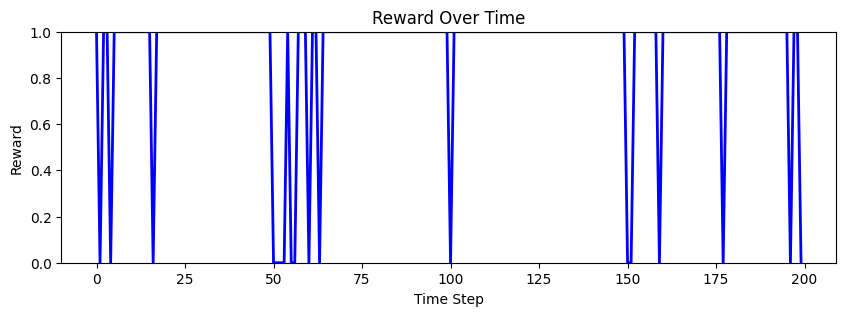


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.98  0.03], Action: 3, Reward: 0.0, Action probs.: [ 0.23  0.24  0.23  0.30]
Step 2:   	True state: 0, Obs.: [ 0.89 -0.11], Action: 0, Reward: 1.0, Action probs.: [ 0.33  0.28  0.24  0.14]
Step 3:   	True state: 0, Obs.: [ 1.10 -0.04], Action: 0, Reward: 1.0, Action probs.: [ 0.79  0.09  0.09  0.03]
Step 4:   	True state: 1, Obs.: [-0.91  0.15], Action: 3, Reward: 0.0, Action probs.: [ 0.34  0.23  0.23  0.20]
Step 5:   	True state: 1, Obs.: [-0.97 -0.27], Action: 0, Reward: 0.0, Action probs.: [ 0.31  0.26  0.26  0.18]
Step 6:   	True state: 0, Obs.: [ 0.95  0.27], Action: 1, Reward: 0.0, Action probs.: [ 0.82  0.07  0.07  0.05]
Step 7:   	True state: 1, Obs.: [-0.95 -0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.24  0.29  0.27  0.21]
Step 8:   	True state: 0, Obs.: [ 1.16 -0.16], Action: 0, Reward: 1.0, Action probs.: [ 0.88  0.05  0.07  0.00]
Step 9:   	True state: 

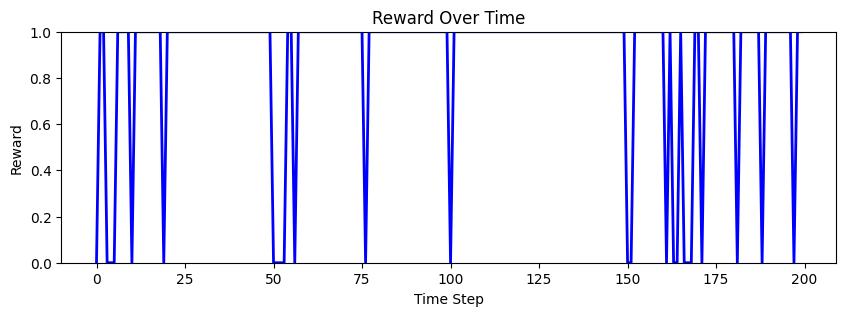


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.18  0.17], Action: 1, Reward: 0.0, Action probs.: [ 0.24  0.22  0.24  0.30]
Step 2:   	True state: 1, Obs.: [-0.87 -0.37], Action: 1, Reward: 1.0, Action probs.: [ 0.28  0.22  0.22  0.29]
Step 3:   	True state: 0, Obs.: [ 1.17  0.04], Action: 3, Reward: 0.0, Action probs.: [ 0.25  0.27  0.24  0.24]
Step 4:   	True state: 1, Obs.: [-1.10  0.08], Action: 1, Reward: 1.0, Action probs.: [ 0.09  0.78  0.06  0.07]
Step 5:   	True state: 0, Obs.: [ 0.99 -0.02], Action: 2, Reward: 0.0, Action probs.: [ 0.29  0.24  0.28  0.20]
Step 6:   	True state: 1, Obs.: [-1.23 -0.20], Action: 3, Reward: 0.0, Action probs.: [ 0.07  0.80  0.05  0.08]
Step 7:   	True state: 0, Obs.: [ 1.01  0.00], Action: 0, Reward: 1.0, Action probs.: [ 0.27  0.27  0.24  0.22]
Step 8:   	True state: 1, Obs.: [-0.90  0.14], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.89  0.03  0.01]
Step 9:   	True state: 

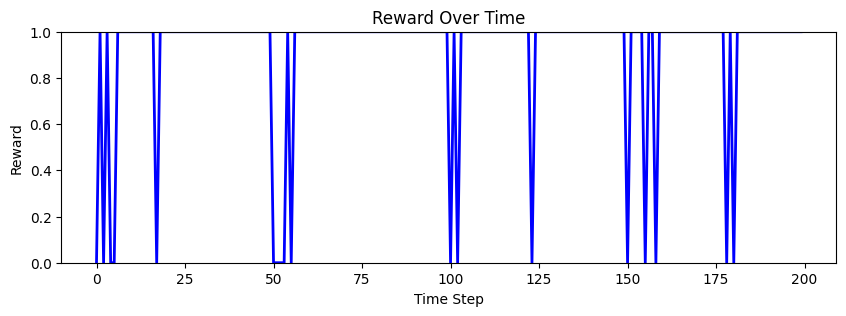


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.69  0.12], Action: 1, Reward: 0.0, Action probs.: [ 0.24  0.27  0.25  0.24]
Step 2:   	True state: 1, Obs.: [-0.91 -0.23], Action: 2, Reward: 0.0, Action probs.: [ 0.28  0.24  0.24  0.24]
Step 3:   	True state: 1, Obs.: [-1.19  0.06], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.23  0.14  0.36]
Step 4:   	True state: 1, Obs.: [-0.69  0.05], Action: 0, Reward: 0.0, Action probs.: [ 0.27  0.29  0.21  0.23]
Step 5:   	True state: 0, Obs.: [ 1.12  0.10], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.18  0.29  0.25]
Step 6:   	True state: 0, Obs.: [ 1.10 -0.10], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.22  0.28  0.24]
Step 7:   	True state: 1, Obs.: [-0.83  0.05], Action: 1, Reward: 1.0, Action probs.: [ 0.30  0.25  0.21  0.24]
Step 8:   	True state: 1, Obs.: [-1.09 -0.00], Action: 2, Reward: 0.0, Action probs.: [ 0.02  0.90  0.06  0.01]
Step 9:   	True state: 

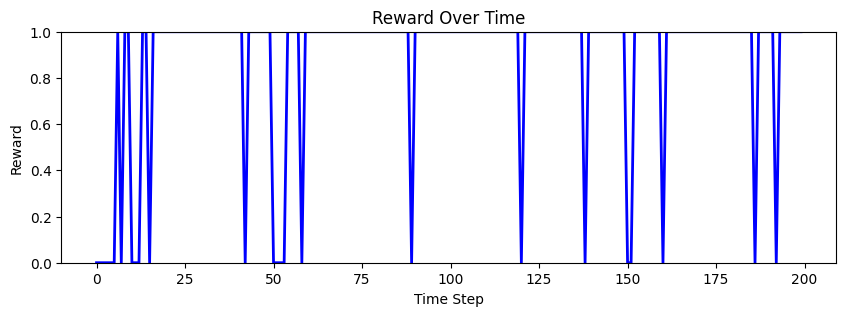


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.75  0.07], Action: 0, Reward: 0.0, Action probs.: [ 0.25  0.23  0.28  0.24]
Step 2:   	True state: 0, Obs.: [ 1.01 -0.26], Action: 1, Reward: 0.0, Action probs.: [ 0.19  0.24  0.26  0.30]
Step 3:   	True state: 0, Obs.: [ 1.04  0.09], Action: 2, Reward: 0.0, Action probs.: [ 0.28  0.23  0.26  0.23]
Step 4:   	True state: 1, Obs.: [-0.99  0.16], Action: 3, Reward: 0.0, Action probs.: [ 0.18  0.37  0.21  0.24]
Step 5:   	True state: 1, Obs.: [-1.06 -0.20], Action: 1, Reward: 1.0, Action probs.: [ 0.16  0.32  0.32  0.21]
Step 6:   	True state: 0, Obs.: [ 0.87  0.04], Action: 0, Reward: 1.0, Action probs.: [ 0.29  0.28  0.19  0.24]
Step 7:   	True state: 1, Obs.: [-1.24  0.13], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.86  0.08  0.02]
Step 8:   	True state: 0, Obs.: [ 0.87 -0.22], Action: 2, Reward: 0.0, Action probs.: [ 0.83  0.02  0.04  0.11]
Step 9:   	True state: 

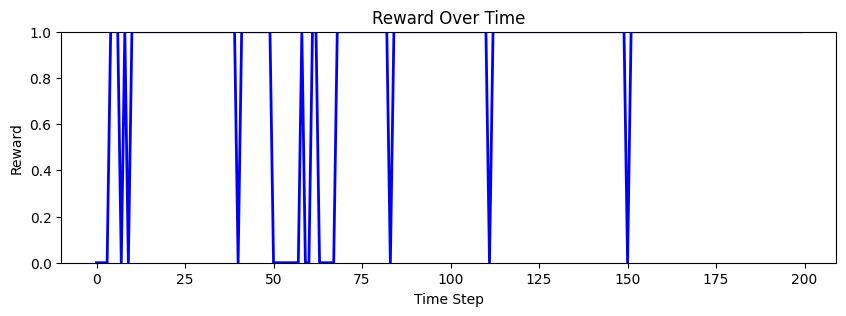


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.97 -0.21], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.29  0.21  0.25]
Step 2:   	True state: 0, Obs.: [ 1.10  0.00], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.22  0.22  0.31]
Step 3:   	True state: 0, Obs.: [ 0.99  0.09], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.33  0.15  0.26]
Step 4:   	True state: 1, Obs.: [-1.11 -0.03], Action: 2, Reward: 0.0, Action probs.: [ 0.38  0.25  0.13  0.23]
Step 5:   	True state: 0, Obs.: [ 0.99  0.13], Action: 3, Reward: 0.0, Action probs.: [ 0.32  0.28  0.25  0.15]
Step 6:   	True state: 1, Obs.: [-0.80 -0.05], Action: 3, Reward: 0.0, Action probs.: [ 0.23  0.29  0.20  0.29]
Step 7:   	True state: 0, Obs.: [ 0.97 -0.01], Action: 1, Reward: 0.0, Action probs.: [ 0.31  0.24  0.26  0.19]
Step 8:   	True state: 0, Obs.: [ 0.86  0.28], Action: 2, Reward: 0.0, Action probs.: [ 0.35  0.29  0.17  0.18]
Step 9:   	True state: 

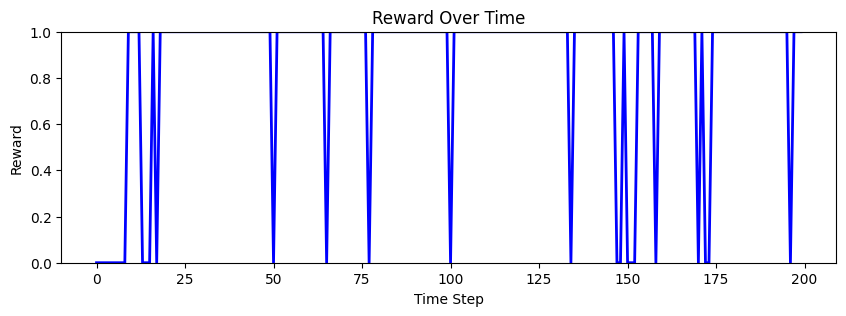


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.14 -0.13], Action: 3, Reward: 0.0, Action probs.: [ 0.26  0.27  0.26  0.21]
Step 2:   	True state: 0, Obs.: [ 0.86 -0.20], Action: 0, Reward: 1.0, Action probs.: [ 0.20  0.24  0.31  0.26]
Step 3:   	True state: 1, Obs.: [-0.95  0.01], Action: 1, Reward: 1.0, Action probs.: [ 0.41  0.21  0.23  0.16]
Step 4:   	True state: 0, Obs.: [ 1.20  0.10], Action: 0, Reward: 1.0, Action probs.: [ 0.78  0.13  0.02  0.06]
Step 5:   	True state: 0, Obs.: [ 0.73 -0.03], Action: 0, Reward: 1.0, Action probs.: [ 0.83  0.09  0.05  0.03]
Step 6:   	True state: 1, Obs.: [-1.03 -0.01], Action: 1, Reward: 1.0, Action probs.: [ 0.09  0.83  0.07  0.01]
Step 7:   	True state: 1, Obs.: [-0.88 -0.43], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.89  0.04  0.01]
Step 8:   	True state: 0, Obs.: [ 1.04 -0.22], Action: 0, Reward: 1.0, Action probs.: [ 0.83  0.06  0.03  0.07]
Step 9:   	True state: 

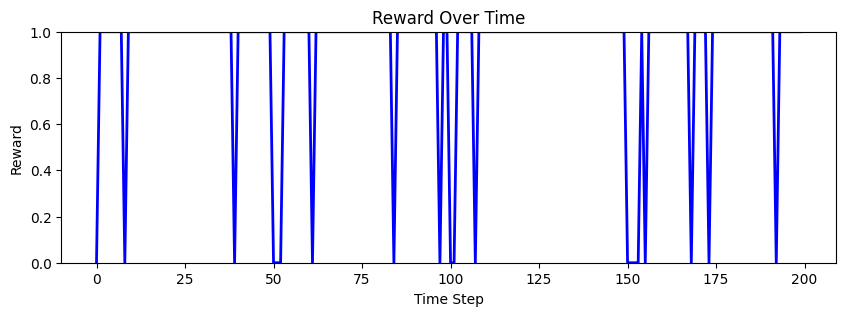


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.01  0.25], Action: 0, Reward: 0.0, Action probs.: [ 0.26  0.24  0.25  0.25]
Step 2:   	True state: 1, Obs.: [-1.03 -0.02], Action: 1, Reward: 1.0, Action probs.: [ 0.26  0.20  0.28  0.26]
Step 3:   	True state: 0, Obs.: [ 1.21 -0.06], Action: 2, Reward: 0.0, Action probs.: [ 0.20  0.34  0.21  0.25]
Step 4:   	True state: 0, Obs.: [ 0.72 -0.07], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.36  0.18  0.20]
Step 5:   	True state: 0, Obs.: [ 1.06 -0.16], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.30  0.26  0.17]
Step 6:   	True state: 1, Obs.: [-1.01 -0.07], Action: 1, Reward: 1.0, Action probs.: [ 0.02  0.83  0.09  0.05]
Step 7:   	True state: 0, Obs.: [ 0.80 -0.10], Action: 0, Reward: 1.0, Action probs.: [ 0.26  0.34  0.19  0.21]
Step 8:   	True state: 1, Obs.: [-0.98 -0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.03  0.86  0.03  0.08]
Step 9:   	True state: 

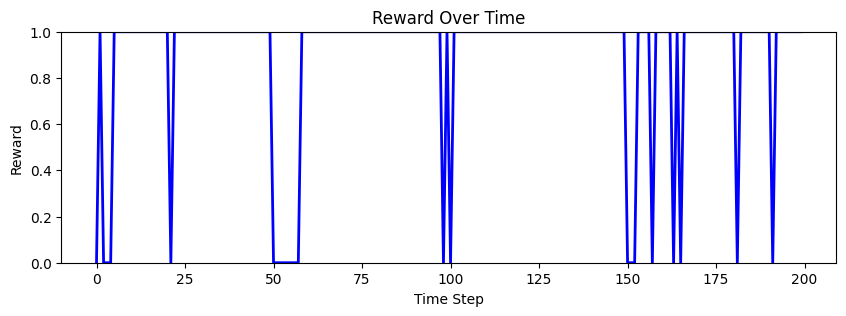


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.10 -0.11], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.26  0.24  0.23]
Step 2:   	True state: 1, Obs.: [-0.77  0.12], Action: 3, Reward: 0.0, Action probs.: [ 0.26  0.27  0.27  0.20]
Step 3:   	True state: 0, Obs.: [ 0.93  0.34], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.32  0.26  0.16]
Step 4:   	True state: 0, Obs.: [ 1.17 -0.21], Action: 3, Reward: 0.0, Action probs.: [ 0.24  0.25  0.23  0.28]
Step 5:   	True state: 1, Obs.: [-1.11  0.28], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.33  0.25  0.18]
Step 6:   	True state: 1, Obs.: [-1.01  0.12], Action: 0, Reward: 0.0, Action probs.: [ 0.29  0.26  0.20  0.25]
Step 7:   	True state: 1, Obs.: [-0.85 -0.15], Action: 3, Reward: 0.0, Action probs.: [ 0.25  0.24  0.27  0.24]
Step 8:   	True state: 0, Obs.: [ 1.05  0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.36  0.23  0.23  0.18]
Step 9:   	True state: 

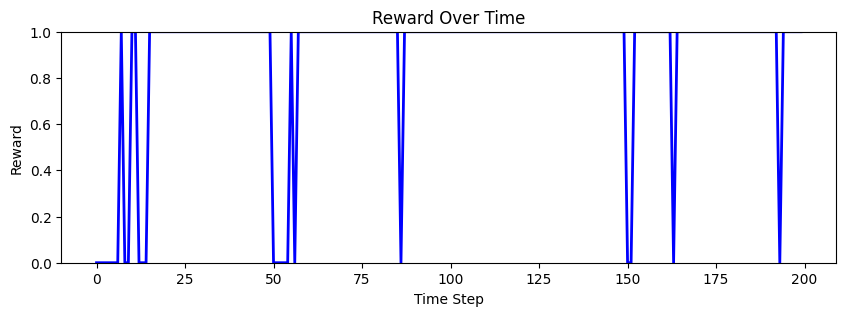


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.01 -0.23], Action: 0, Reward: 1.0, Action probs.: [ 0.29  0.24  0.27  0.20]
Step 2:   	True state: 1, Obs.: [-0.83  0.08], Action: 0, Reward: 0.0, Action probs.: [ 0.42  0.20  0.18  0.21]
Step 3:   	True state: 0, Obs.: [ 0.94  0.29], Action: 0, Reward: 1.0, Action probs.: [ 0.74  0.07  0.09  0.10]
Step 4:   	True state: 1, Obs.: [-1.12 -0.30], Action: 2, Reward: 0.0, Action probs.: [ 0.19  0.22  0.31  0.29]
Step 5:   	True state: 0, Obs.: [ 0.97  0.04], Action: 0, Reward: 1.0, Action probs.: [ 0.84  0.06  0.06  0.04]
Step 6:   	True state: 1, Obs.: [-1.09  0.11], Action: 0, Reward: 0.0, Action probs.: [ 0.23  0.33  0.17  0.27]
Step 7:   	True state: 0, Obs.: [ 0.99 -0.27], Action: 0, Reward: 1.0, Action probs.: [ 0.88  0.03  0.06  0.03]
Step 8:   	True state: 1, Obs.: [-0.93 -0.34], Action: 3, Reward: 0.0, Action probs.: [ 0.23  0.29  0.15  0.33]
Step 9:   	True state: 

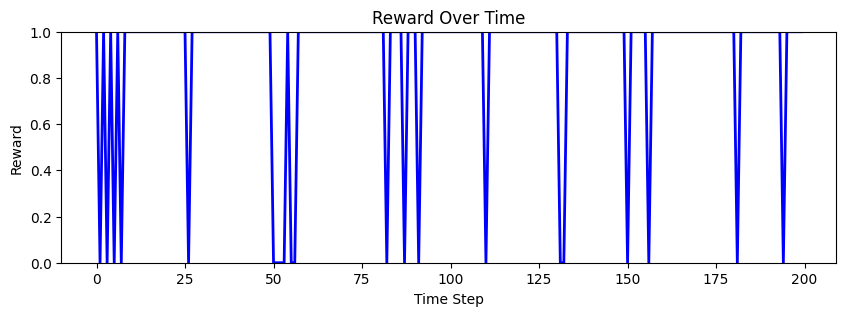


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.09  0.18], Action: 1, Reward: 0.0, Action probs.: [ 0.19  0.27  0.28  0.26]
Step 2:   	True state: 1, Obs.: [-1.22  0.06], Action: 1, Reward: 1.0, Action probs.: [ 0.27  0.22  0.28  0.24]
Step 3:   	True state: 0, Obs.: [ 1.06 -0.10], Action: 2, Reward: 0.0, Action probs.: [ 0.28  0.20  0.26  0.26]
Step 4:   	True state: 0, Obs.: [ 1.06 -0.07], Action: 0, Reward: 1.0, Action probs.: [ 0.28  0.20  0.21  0.30]
Step 5:   	True state: 0, Obs.: [ 0.66  0.18], Action: 0, Reward: 1.0, Action probs.: [ 0.83  0.03  0.03  0.11]
Step 6:   	True state: 0, Obs.: [ 0.70 -0.04], Action: 0, Reward: 1.0, Action probs.: [ 0.85  0.05  0.02  0.07]
Step 7:   	True state: 1, Obs.: [-1.09  0.00], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.82  0.07  0.05]
Step 8:   	True state: 0, Obs.: [ 1.30  0.08], Action: 2, Reward: 0.0, Action probs.: [ 0.94  0.01  0.01  0.04]
Step 9:   	True state: 

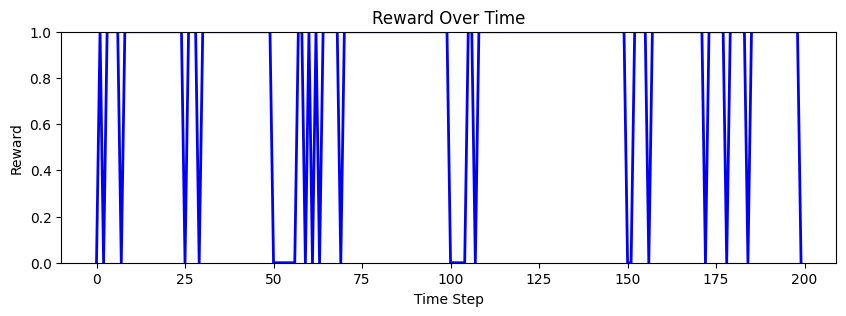


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.94  0.14], Action: 3, Reward: 0.0, Action probs.: [ 0.30  0.30  0.22  0.19]
Step 2:   	True state: 0, Obs.: [ 0.95  0.13], Action: 0, Reward: 1.0, Action probs.: [ 0.26  0.23  0.26  0.26]
Step 3:   	True state: 1, Obs.: [-1.15 -0.11], Action: 2, Reward: 0.0, Action probs.: [ 0.34  0.26  0.21  0.18]
Step 4:   	True state: 0, Obs.: [ 1.20 -0.21], Action: 0, Reward: 1.0, Action probs.: [ 0.80  0.07  0.06  0.07]
Step 5:   	True state: 1, Obs.: [-0.97  0.25], Action: 2, Reward: 0.0, Action probs.: [ 0.39  0.25  0.19  0.16]
Step 6:   	True state: 1, Obs.: [-1.02 -0.19], Action: 1, Reward: 1.0, Action probs.: [ 0.28  0.34  0.19  0.19]
Step 7:   	True state: 1, Obs.: [-1.08  0.25], Action: 1, Reward: 1.0, Action probs.: [ 0.14  0.81  0.01  0.04]
Step 8:   	True state: 1, Obs.: [-1.02 -0.16], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.88  0.02  0.03]
Step 9:   	True state: 

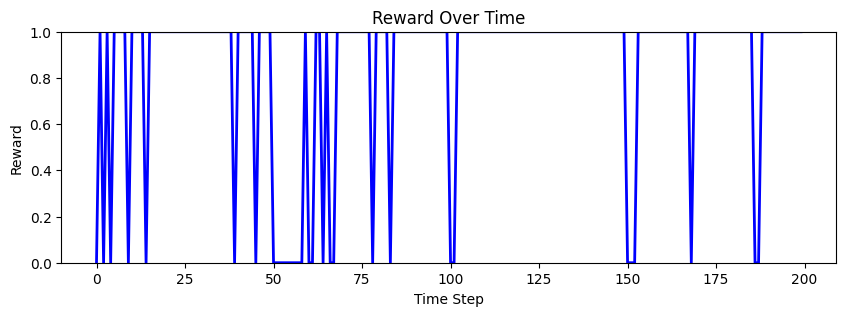


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.86  0.19], Action: 2, Reward: 0.0, Action probs.: [ 0.27  0.28  0.19  0.26]
Step 2:   	True state: 0, Obs.: [ 0.96  0.24], Action: 1, Reward: 0.0, Action probs.: [ 0.26  0.26  0.22  0.26]
Step 3:   	True state: 1, Obs.: [-1.08  0.22], Action: 2, Reward: 0.0, Action probs.: [ 0.24  0.27  0.23  0.26]
Step 4:   	True state: 1, Obs.: [-0.99  0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.31  0.31  0.13  0.25]
Step 5:   	True state: 0, Obs.: [ 0.85 -0.05], Action: 2, Reward: 0.0, Action probs.: [ 0.29  0.23  0.21  0.28]
Step 6:   	True state: 0, Obs.: [ 0.75  0.32], Action: 1, Reward: 0.0, Action probs.: [ 0.25  0.26  0.18  0.31]
Step 7:   	True state: 0, Obs.: [ 1.22  0.09], Action: 3, Reward: 0.0, Action probs.: [ 0.28  0.25  0.17  0.30]
Step 8:   	True state: 0, Obs.: [ 0.94 -0.14], Action: 0, Reward: 1.0, Action probs.: [ 0.34  0.25  0.17  0.23]
Step 9:   	True state: 

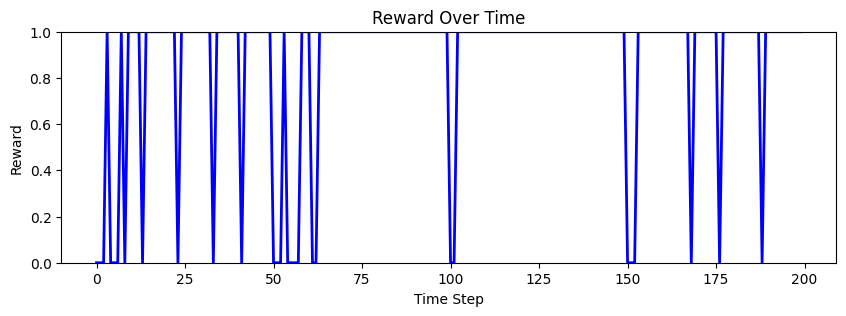


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.84 -0.24], Action: 1, Reward: 1.0, Action probs.: [ 0.22  0.28  0.25  0.24]
Step 2:   	True state: 0, Obs.: [ 0.83 -0.17], Action: 0, Reward: 1.0, Action probs.: [ 0.15  0.53  0.17  0.16]
Step 3:   	True state: 1, Obs.: [-1.19 -0.11], Action: 1, Reward: 1.0, Action probs.: [ 0.20  0.65  0.05  0.10]
Step 4:   	True state: 1, Obs.: [-1.01 -0.12], Action: 1, Reward: 1.0, Action probs.: [ 0.11  0.80  0.03  0.05]
Step 5:   	True state: 1, Obs.: [-0.85 -0.17], Action: 1, Reward: 1.0, Action probs.: [ 0.11  0.82  0.05  0.02]
Step 6:   	True state: 1, Obs.: [-1.06  0.02], Action: 1, Reward: 1.0, Action probs.: [ 0.10  0.86  0.00  0.03]
Step 7:   	True state: 1, Obs.: [-0.98 -0.05], Action: 1, Reward: 1.0, Action probs.: [ 0.06  0.89  0.04  0.01]
Step 8:   	True state: 0, Obs.: [ 0.95  0.09], Action: 2, Reward: 0.0, Action probs.: [ 0.80  0.08  0.08  0.04]
Step 9:   	True state: 

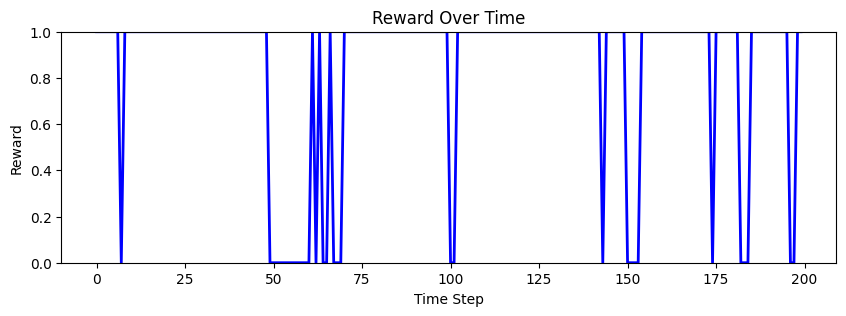


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.76 -0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.25  0.27  0.23  0.25]
Step 2:   	True state: 1, Obs.: [-0.85  0.05], Action: 3, Reward: 0.0, Action probs.: [ 0.07  0.78  0.07  0.08]
Step 3:   	True state: 0, Obs.: [ 1.09 -0.10], Action: 2, Reward: 0.0, Action probs.: [ 0.21  0.35  0.26  0.18]
Step 4:   	True state: 1, Obs.: [-0.97  0.17], Action: 1, Reward: 1.0, Action probs.: [ 0.06  0.83  0.07  0.04]
Step 5:   	True state: 1, Obs.: [-1.04 -0.07], Action: 0, Reward: 0.0, Action probs.: [ 0.05  0.90  0.04  0.01]
Step 6:   	True state: 0, Obs.: [ 0.96  0.03], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.28  0.23  0.23]
Step 7:   	True state: 0, Obs.: [ 1.16 -0.18], Action: 0, Reward: 1.0, Action probs.: [ 0.28  0.32  0.16  0.25]
Step 8:   	True state: 1, Obs.: [-1.04  0.03], Action: 1, Reward: 1.0, Action probs.: [ 0.01  0.92  0.06  0.01]
Step 9:   	True state: 

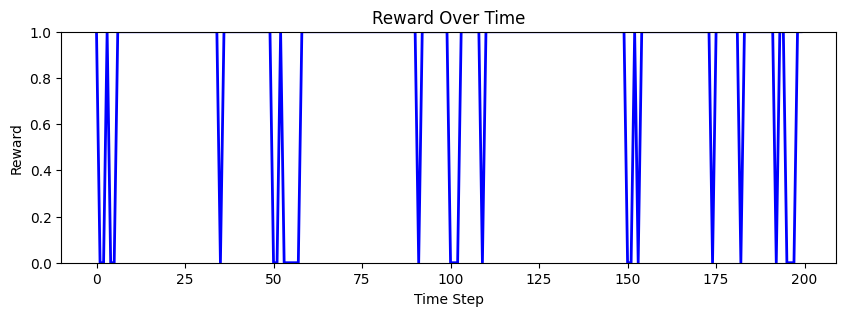


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 0.96 -0.20], Action: 0, Reward: 1.0, Action probs.: [ 0.24  0.24  0.20  0.32]
Step 2:   	True state: 1, Obs.: [-0.86 -0.07], Action: 1, Reward: 1.0, Action probs.: [ 0.52  0.15  0.18  0.15]
Step 3:   	True state: 0, Obs.: [ 0.91 -0.17], Action: 0, Reward: 1.0, Action probs.: [ 0.67  0.20  0.07  0.06]
Step 4:   	True state: 0, Obs.: [ 1.05 -0.04], Action: 1, Reward: 0.0, Action probs.: [ 0.75  0.12  0.05  0.08]
Step 5:   	True state: 1, Obs.: [-1.21  0.11], Action: 1, Reward: 1.0, Action probs.: [ 0.08  0.75  0.05  0.12]
Step 6:   	True state: 1, Obs.: [-1.10  0.02], Action: 1, Reward: 1.0, Action probs.: [ 0.05  0.85  0.04  0.07]
Step 7:   	True state: 0, Obs.: [ 1.06 -0.04], Action: 0, Reward: 1.0, Action probs.: [ 0.88  0.04  0.05  0.03]
Step 8:   	True state: 0, Obs.: [ 0.61  0.18], Action: 0, Reward: 1.0, Action probs.: [ 0.91  0.03  0.01  0.04]
Step 9:   	True state: 

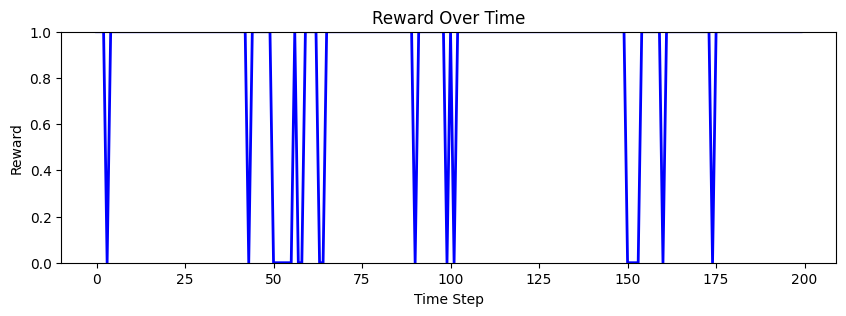


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.09  0.08], Action: 3, Reward: 0.0, Action probs.: [ 0.18  0.26  0.30  0.27]
Step 2:   	True state: 1, Obs.: [-0.95  0.08], Action: 0, Reward: 0.0, Action probs.: [ 0.23  0.28  0.26  0.24]
Step 3:   	True state: 0, Obs.: [ 1.03 -0.15], Action: 1, Reward: 0.0, Action probs.: [ 0.21  0.29  0.29  0.21]
Step 4:   	True state: 0, Obs.: [ 1.03 -0.11], Action: 0, Reward: 1.0, Action probs.: [ 0.25  0.20  0.32  0.22]
Step 5:   	True state: 0, Obs.: [ 0.98 -0.17], Action: 0, Reward: 1.0, Action probs.: [ 0.81  0.05  0.07  0.07]
Step 6:   	True state: 1, Obs.: [-1.18 -0.12], Action: 1, Reward: 1.0, Action probs.: [ 0.19  0.24  0.30  0.28]
Step 7:   	True state: 0, Obs.: [ 0.84  0.27], Action: 0, Reward: 1.0, Action probs.: [ 0.88  0.03  0.07  0.02]
Step 8:   	True state: 0, Obs.: [ 0.97  0.08], Action: 0, Reward: 1.0, Action probs.: [ 0.94  0.03  0.02  0.02]
Step 9:   	True state: 

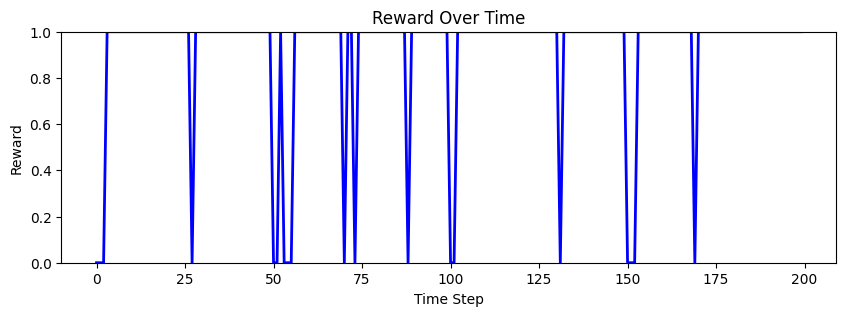


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.03  0.07], Action: 2, Reward: 0.0, Action probs.: [ 0.22  0.27  0.26  0.25]
Step 2:   	True state: 0, Obs.: [ 0.99 -0.13], Action: 0, Reward: 1.0, Action probs.: [ 0.26  0.30  0.16  0.28]
Step 3:   	True state: 1, Obs.: [-1.36  0.14], Action: 0, Reward: 0.0, Action probs.: [ 0.32  0.19  0.24  0.25]
Step 4:   	True state: 1, Obs.: [-0.78 -0.13], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.32  0.22  0.20]
Step 5:   	True state: 0, Obs.: [ 1.03 -0.08], Action: 0, Reward: 1.0, Action probs.: [ 0.84  0.06  0.03  0.06]
Step 6:   	True state: 1, Obs.: [-1.17  0.02], Action: 1, Reward: 1.0, Action probs.: [ 0.16  0.33  0.21  0.30]
Step 7:   	True state: 0, Obs.: [ 1.13 -0.18], Action: 3, Reward: 0.0, Action probs.: [ 0.80  0.08  0.02  0.10]
Step 8:   	True state: 0, Obs.: [ 0.92  0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.94  0.04  0.02  0.01]
Step 9:   	True state: 

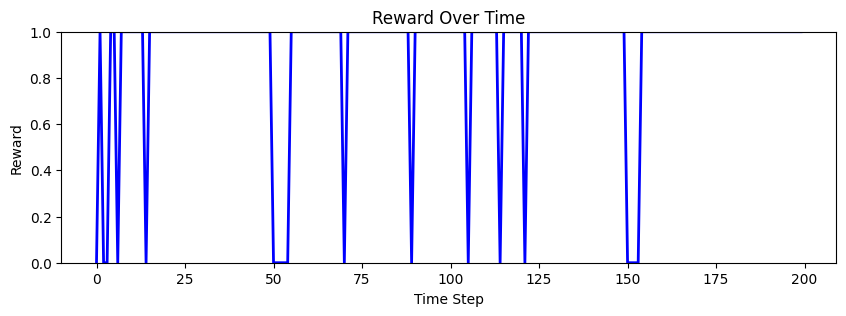


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.04  0.07], Action: 0, Reward: 1.0, Action probs.: [ 0.24  0.24  0.24  0.28]
Step 2:   	True state: 0, Obs.: [ 0.94 -0.09], Action: 0, Reward: 1.0, Action probs.: [ 0.82  0.07  0.05  0.06]
Step 3:   	True state: 0, Obs.: [ 1.00 -0.07], Action: 0, Reward: 1.0, Action probs.: [ 0.85  0.02  0.07  0.06]
Step 4:   	True state: 1, Obs.: [-1.02 -0.15], Action: 0, Reward: 0.0, Action probs.: [ 0.35  0.23  0.16  0.25]
Step 5:   	True state: 1, Obs.: [-1.07 -0.42], Action: 2, Reward: 0.0, Action probs.: [ 0.21  0.24  0.27  0.28]
Step 6:   	True state: 1, Obs.: [-1.01  0.10], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.28  0.21  0.26]
Step 7:   	True state: 0, Obs.: [ 1.21 -0.41], Action: 0, Reward: 1.0, Action probs.: [ 0.84  0.08  0.03  0.05]
Step 8:   	True state: 0, Obs.: [ 0.84  0.15], Action: 0, Reward: 1.0, Action probs.: [ 0.90  0.04  0.04  0.02]
Step 9:   	True state: 

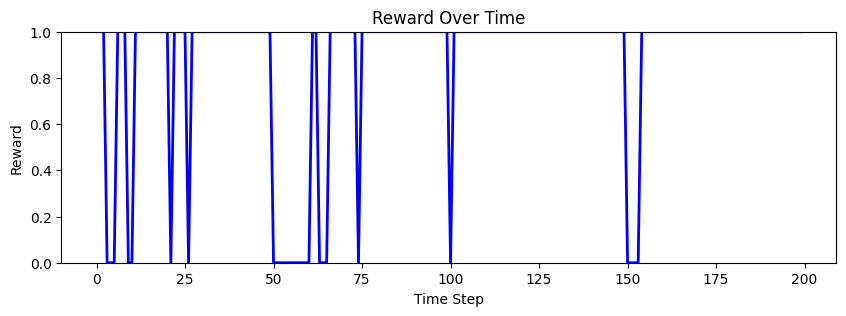


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.01  0.06], Action: 1, Reward: 1.0, Action probs.: [ 0.28  0.25  0.23  0.24]
Step 2:   	True state: 0, Obs.: [ 1.02  0.02], Action: 1, Reward: 0.0, Action probs.: [ 0.21  0.44  0.21  0.14]
Step 3:   	True state: 1, Obs.: [-0.96 -0.30], Action: 1, Reward: 1.0, Action probs.: [ 0.08  0.74  0.07  0.11]
Step 4:   	True state: 0, Obs.: [ 1.00  0.28], Action: 3, Reward: 0.0, Action probs.: [ 0.24  0.25  0.28  0.24]
Step 5:   	True state: 0, Obs.: [ 0.98 -0.01], Action: 0, Reward: 1.0, Action probs.: [ 0.32  0.21  0.28  0.20]
Step 6:   	True state: 0, Obs.: [ 0.99  0.06], Action: 2, Reward: 0.0, Action probs.: [ 0.87  0.06  0.06  0.02]
Step 7:   	True state: 1, Obs.: [-1.09  0.28], Action: 1, Reward: 1.0, Action probs.: [ 0.08  0.83  0.07  0.02]
Step 8:   	True state: 1, Obs.: [-0.92 -0.14], Action: 1, Reward: 1.0, Action probs.: [ 0.04  0.88  0.04  0.04]
Step 9:   	True state: 

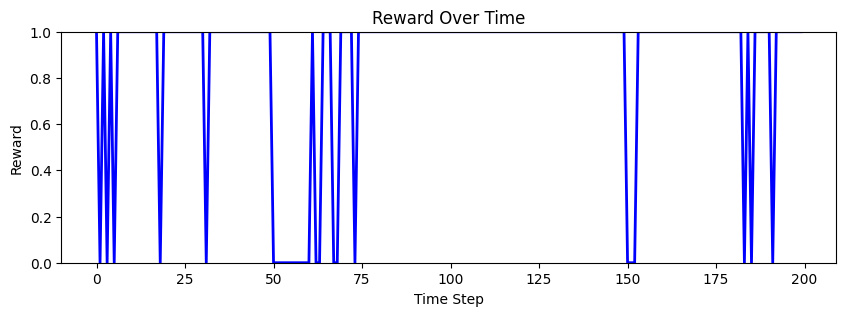


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.12 -0.12], Action: 3, Reward: 0.0, Action probs.: [ 0.24  0.26  0.27  0.24]
Step 2:   	True state: 1, Obs.: [-1.20 -0.12], Action: 3, Reward: 0.0, Action probs.: [ 0.28  0.28  0.22  0.21]
Step 3:   	True state: 0, Obs.: [ 0.87  0.04], Action: 1, Reward: 0.0, Action probs.: [ 0.27  0.24  0.24  0.25]
Step 4:   	True state: 0, Obs.: [ 1.12 -0.00], Action: 2, Reward: 0.0, Action probs.: [ 0.29  0.23  0.25  0.24]
Step 5:   	True state: 1, Obs.: [-1.07  0.04], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.30  0.27  0.18]
Step 6:   	True state: 0, Obs.: [ 1.10  0.17], Action: 3, Reward: 0.0, Action probs.: [ 0.25  0.24  0.23  0.28]
Step 7:   	True state: 1, Obs.: [-1.10  0.11], Action: 3, Reward: 0.0, Action probs.: [ 0.27  0.24  0.29  0.20]
Step 8:   	True state: 0, Obs.: [ 0.91 -0.07], Action: 0, Reward: 1.0, Action probs.: [ 0.28  0.27  0.23  0.23]
Step 9:   	True state: 

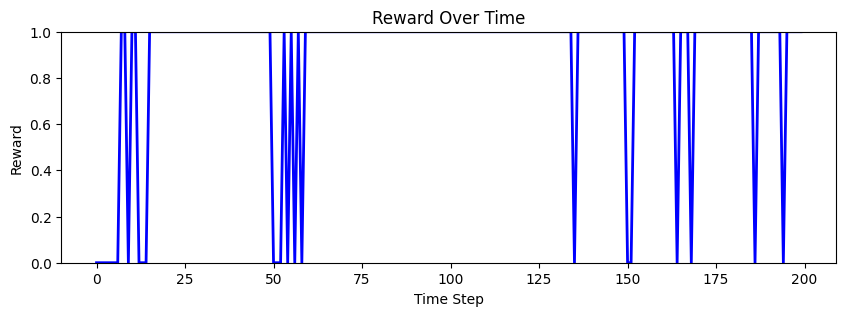


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.03  0.07], Action: 2, Reward: 0.0, Action probs.: [ 0.28  0.21  0.24  0.26]
Step 2:   	True state: 1, Obs.: [-0.96  0.29], Action: 0, Reward: 0.0, Action probs.: [ 0.23  0.32  0.25  0.21]
Step 3:   	True state: 0, Obs.: [ 1.05  0.26], Action: 0, Reward: 1.0, Action probs.: [ 0.32  0.20  0.26  0.21]
Step 4:   	True state: 1, Obs.: [-0.95 -0.16], Action: 1, Reward: 1.0, Action probs.: [ 0.24  0.28  0.20  0.27]
Step 5:   	True state: 1, Obs.: [-1.04  0.01], Action: 2, Reward: 0.0, Action probs.: [ 0.07  0.81  0.05  0.07]
Step 6:   	True state: 1, Obs.: [-0.97  0.04], Action: 1, Reward: 1.0, Action probs.: [ 0.05  0.86  0.03  0.06]
Step 7:   	True state: 1, Obs.: [-0.80  0.22], Action: 1, Reward: 1.0, Action probs.: [ 0.05  0.89  0.01  0.05]
Step 8:   	True state: 0, Obs.: [ 1.11 -0.07], Action: 0, Reward: 1.0, Action probs.: [ 0.81  0.06  0.07  0.05]
Step 9:   	True state: 

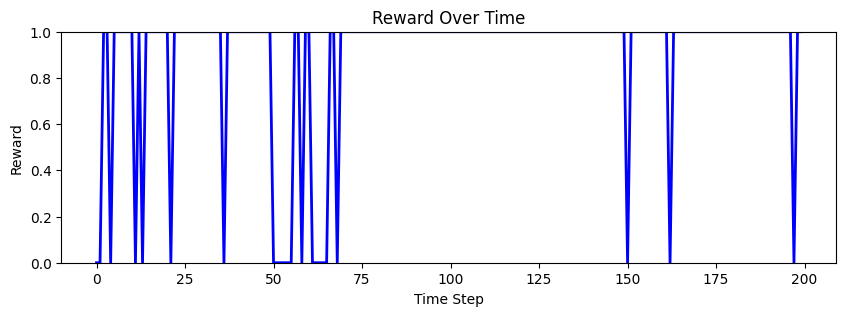


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 0, Obs.: [ 1.29  0.12], Action: 0, Reward: 1.0, Action probs.: [ 0.28  0.22  0.23  0.26]
Step 2:   	True state: 1, Obs.: [-0.98  0.36], Action: 2, Reward: 0.0, Action probs.: [ 0.39  0.17  0.23  0.21]
Step 3:   	True state: 1, Obs.: [-1.07  0.13], Action: 0, Reward: 0.0, Action probs.: [ 0.31  0.22  0.17  0.30]
Step 4:   	True state: 0, Obs.: [ 0.82 -0.15], Action: 0, Reward: 1.0, Action probs.: [ 0.82  0.07  0.04  0.07]
Step 5:   	True state: 1, Obs.: [-0.87  0.03], Action: 2, Reward: 0.0, Action probs.: [ 0.26  0.30  0.18  0.27]
Step 6:   	True state: 0, Obs.: [ 1.06 -0.06], Action: 0, Reward: 1.0, Action probs.: [ 0.94  0.02  0.03  0.02]
Step 7:   	True state: 0, Obs.: [ 1.06 -0.09], Action: 1, Reward: 0.0, Action probs.: [ 0.88  0.03  0.04  0.06]
Step 8:   	True state: 0, Obs.: [ 0.94 -0.09], Action: 3, Reward: 0.0, Action probs.: [ 0.87  0.01  0.04  0.07]
Step 9:   	True state: 

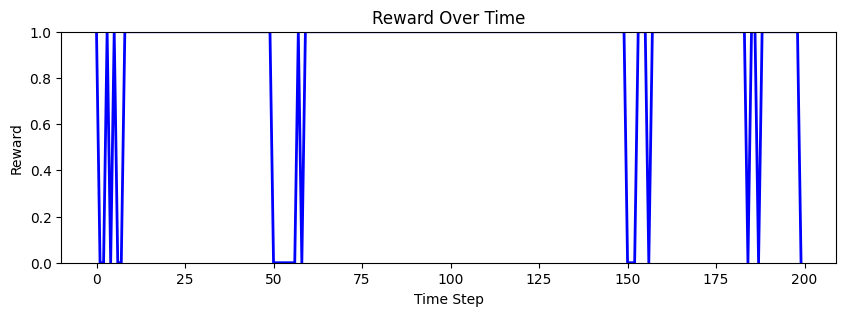


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-1.08  0.24], Action: 1, Reward: 1.0, Action probs.: [ 0.25  0.25  0.28  0.22]
Step 2:   	True state: 0, Obs.: [ 1.08 -0.04], Action: 3, Reward: 0.0, Action probs.: [ 0.23  0.35  0.21  0.21]
Step 3:   	True state: 1, Obs.: [-1.00  0.08], Action: 3, Reward: 0.0, Action probs.: [ 0.05  0.82  0.07  0.07]
Step 4:   	True state: 0, Obs.: [ 0.94  0.26], Action: 3, Reward: 0.0, Action probs.: [ 0.18  0.41  0.20  0.22]
Step 5:   	True state: 1, Obs.: [-1.15 -0.15], Action: 1, Reward: 1.0, Action probs.: [ 0.07  0.80  0.09  0.04]
Step 6:   	True state: 0, Obs.: [ 1.06 -0.15], Action: 2, Reward: 0.0, Action probs.: [ 0.25  0.32  0.23  0.20]
Step 7:   	True state: 0, Obs.: [ 1.00  0.11], Action: 1, Reward: 0.0, Action probs.: [ 0.30  0.30  0.18  0.21]
Step 8:   	True state: 0, Obs.: [ 0.99 -0.03], Action: 2, Reward: 0.0, Action probs.: [ 0.34  0.26  0.20  0.21]
Step 9:   	True state: 

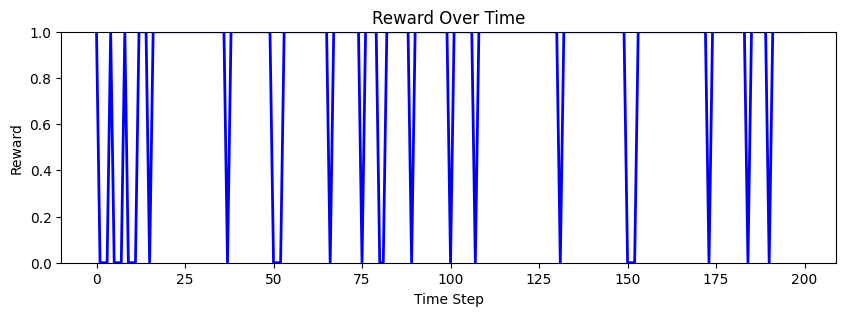


 << Running 50 trials with true obs. context = 0 and true rew. context = 0 >> 

Step 1:   	True state: 1, Obs.: [-0.72  0.08], Action: 1, Reward: 1.0, Action probs.: [ 0.27  0.28  0.19  0.26]
Step 2:   	True state: 0, Obs.: [ 1.18  0.01], Action: 3, Reward: 0.0, Action probs.: [ 0.16  0.42  0.24  0.18]
Step 3:   	True state: 0, Obs.: [ 0.99 -0.17], Action: 0, Reward: 1.0, Action probs.: [ 0.19  0.46  0.18  0.17]
Step 4:   	True state: 1, Obs.: [-1.02 -0.17], Action: 3, Reward: 0.0, Action probs.: [ 0.12  0.75  0.06  0.07]
Step 5:   	True state: 0, Obs.: [ 1.19 -0.10], Action: 0, Reward: 1.0, Action probs.: [ 0.86  0.09  0.04  0.02]
Step 6:   	True state: 0, Obs.: [ 1.13  0.18], Action: 0, Reward: 1.0, Action probs.: [ 0.85  0.08  0.05  0.02]
Step 7:   	True state: 0, Obs.: [ 1.34  0.04], Action: 0, Reward: 1.0, Action probs.: [ 0.90  0.06  0.01  0.03]
Step 8:   	True state: 1, Obs.: [-1.06  0.00], Action: 2, Reward: 0.0, Action probs.: [ 0.05  0.84  0.08  0.02]
Step 9:   	True state: 

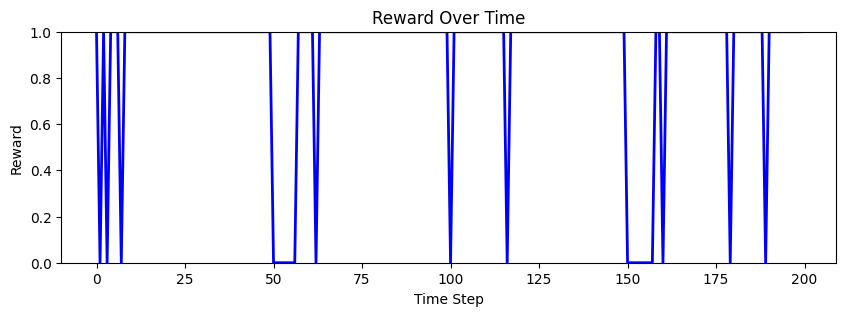

In [8]:
results = []

for i in range(100):

    # Initialize history buffers
    exp_history = ExperimentHistory()
    sub_history = IOPFSubjectHistory()


    # Initialize ensemble
    subject = IdealObsPF(N=250, hyp_params=AGENT_PARAMS, n_workers=8)
    #ensemble = Ensemble(N=1000, hyp_cjcrp=HYP_CJCRP, hyp_niw=HYP_NIW, hyp_bb=HYP_BB)

    # Run 50 trials in context (c_o=0, c_r=0)
    env.repeat_trials(subject, experiment_history=exp_history, subject_history=sub_history, N = 50, c_o=0, c_r=0, print_level=3)
    # Run 50 trials in context (c_o=1, c_r=1)
    env.repeat_trials(subject, experiment_history=exp_history, subject_history=sub_history, N = 50, c_o=1, c_r=1, print_level=3)
    # Run 50 trials in context (c_o=0, c_r=0)
    env.repeat_trials(subject, experiment_history=exp_history, subject_history=sub_history, N = 50, c_o=0, c_r=0, print_level=3)
    # Run 50 trials in context (c_o=0, c_r=1)
    env.repeat_trials(subject, experiment_history=exp_history, subject_history=sub_history, N = 50, c_o=0, c_r=1, print_level=3)

    subject.deallocate()

    # Combine histories into single object
    combined_history = CombinedHistory(subject_history=sub_history, experiment_history=exp_history)

    results.append(combined_history)

    
    plt.figure(figsize=(10, 3))
    plt.plot(combined_history.experiment_history.reward, label='Reward', color='blue', linewidth=2)
    plt.title('Reward Over Time')
    plt.xlabel('Time Step')
    plt.ylabel('Reward')
    plt.ylim(0, 1)
    plt.show()


## Part 3: Analysis of Results

### Analyse Classical and Compositional Savings

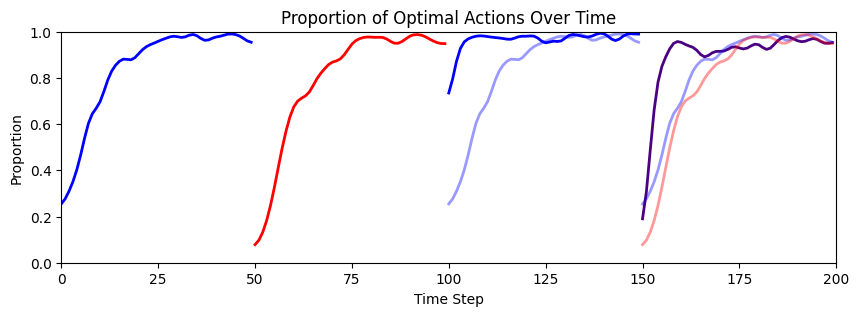

In [9]:
proportion_optimal_mean = np.zeros(200)

chosen = list(range(32))

for j in chosen:

    proportion_optimal_mean += np.array(results[j].experiment_history.reward)

proportion_optimal_mean /= len(chosen)

# gaussian blur with kernel size 5 and sigma 1
from scipy.ndimage import gaussian_filter1d

def smooth(result):
    return gaussian_filter1d(result, sigma=1.5)

task_1 = smooth(proportion_optimal_mean[0:50])
task_1_dur = np.arange(0, 50)
task_2 = smooth(proportion_optimal_mean[50:100])
task_2_dur = np.arange(50, 100)
task_3 = smooth(proportion_optimal_mean[100:150])
task_3_dur = np.arange(100, 150)
task_4 = smooth(proportion_optimal_mean[150:200])
task_4_dur = np.arange(150, 200)



plt.figure(figsize=(10, 3))
#plt.plot(proportion_optimal_mean, label='Proportion Optimal Action', color='blue', linewidth=2)
plt.plot(task_1_dur, task_1, color='blue', linewidth=2, alpha=1.0)
plt.plot(task_2_dur, task_2, color='red', linewidth=2, alpha=1.0)
plt.plot(task_3_dur, task_3, color='blue', linewidth=2, alpha=1.0)
plt.plot(task_4_dur, task_4, color='indigo', linewidth=2, alpha=1.0)
plt.plot(task_3_dur, task_1, color='blue', linewidth=2, alpha=0.4)
plt.plot(task_4_dur, task_1, color='blue', linewidth=2, alpha=0.4)
plt.plot(task_4_dur, task_2, color='red', linewidth=2, alpha=0.4)
plt.title('Proportion of Optimal Actions Over Time')
plt.xlabel('Time Step')
plt.ylabel('Proportion')
plt.ylim(0, 1.0)
plt.xlim(0, len(proportion_optimal_mean))
#plt.savefig("g_proportion_optimal_3.pdf")
plt.show()

### Visualisation of Inferred Variables for a subject

Context O History:


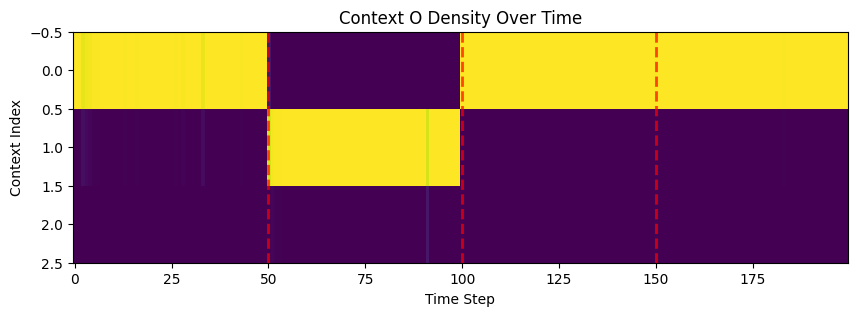

Context R History:


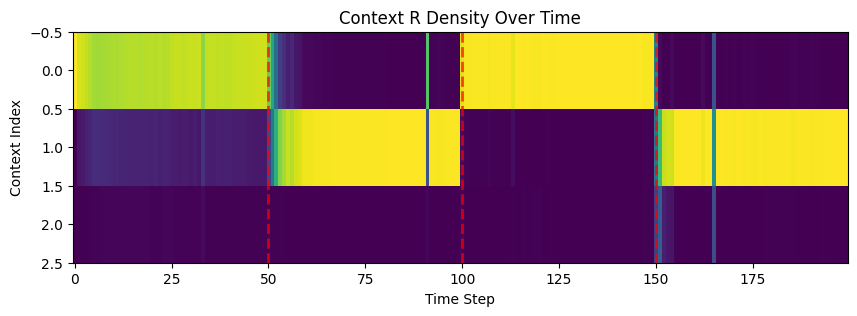

Actions History:


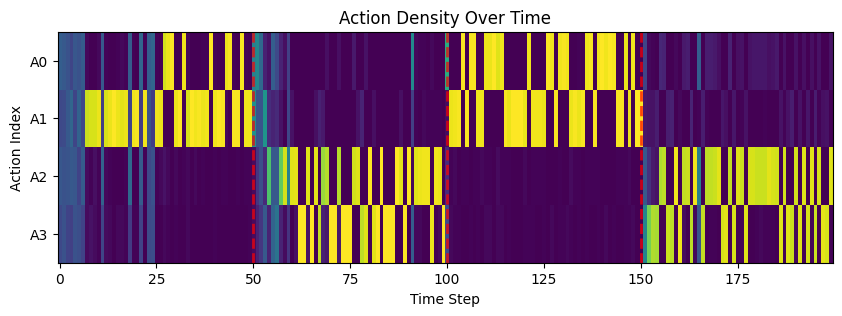

Jump History:


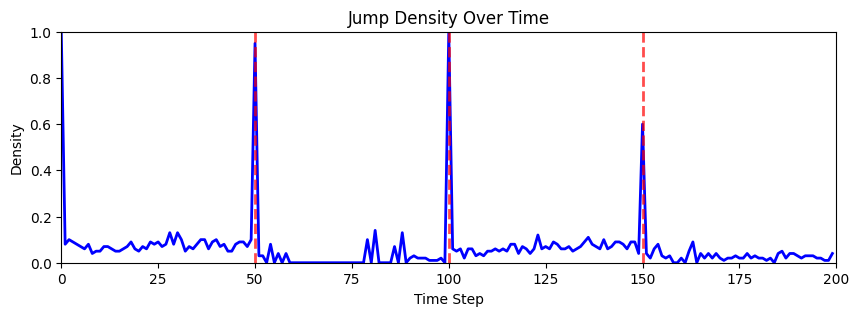

In [10]:
jump_times = [50, 100, 150]
j = 4
context_o_hist_arr = np.array(results[j].subject_history.context_o)
context_r_hist_arr = np.array(results[j].subject_history.context_r)
p_actions_arr = np.array(results[j].subject_history.p_action)
p_jump_arr = np.array(results[j].subject_history.p_jump)
p_state_arr = np.array(results[j].subject_history.p_state)
weight_arr = np.array(results[j].subject_history.weights)
p_action_optimal = results[j].p_optimal_action

print("Context O History:")
max_context_o = np.max(context_o_hist_arr) + 1
context_o_densities = np.zeros((len(context_o_hist_arr), max_context_o))
for t, element in enumerate(context_o_hist_arr):
    for particle_id, val in enumerate(element):
        context_o_densities[t, val] += weight_arr[t][particle_id]
context_o_densities = context_o_densities / context_o_densities.sum(axis=1, keepdims=True)

# set size of plot
plt.figure(figsize=(10, 3))
plt.imshow(context_o_densities.T, aspect='auto', cmap='viridis', interpolation='nearest')
#plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color='red', linestyle='--', linewidth=2, alpha=0.7)


plt.xlabel('Time Step')
plt.ylabel('Context Index')
plt.title('Context O Density Over Time')
#plt.savefig("g_context_o_density.pdf")
plt.show()

print("Context R History:")
max_context_r = np.max(context_r_hist_arr) + 1
context_r_densities = np.zeros((len(context_r_hist_arr), max_context_r))
for t, element in enumerate(context_r_hist_arr):
    for particle_id, val in enumerate(element):
        context_r_densities[t, val] += weight_arr[t][particle_id]
context_r_densities = context_r_densities / context_r_densities.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 3))
plt.imshow(context_r_densities.T, aspect='auto', cmap='viridis', interpolation='nearest')
#plt.colorbar(label='Density')
for jt in jump_times:
    plt.axvline(x=jt, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.xlabel('Time Step')
plt.ylabel('Context Index')
plt.title('Context R Density Over Time')
#plt.savefig("g_context_r_density.pdf")
plt.show()

print("Actions History:")
plt.figure(figsize=(10, 3))
plt.imshow(p_actions_arr.T, aspect='auto', cmap='viridis', interpolation='nearest')
#plt.colorbar(label='Density')
plt.yticks(ticks=[0, 1, 2, 3], labels=['A0', 'A1', 'A2', 'A3'])
for jt in jump_times:
    plt.axvline(x=jt, color='red', linestyle='--', linewidth=2, alpha=0.7)
plt.xlabel('Time Step')
plt.ylabel('Action Index')
plt.title('Action Density Over Time')
#plt.savefig("g_action_density.pdf")
plt.show()

print("Jump History:")

plt.figure(figsize=(10, 3))
plt.plot(p_jump_arr, label='Jump', color='blue', linewidth=2)
plt.title('Jump Density Over Time')
plt.xlabel('Time Step')
plt.ylabel('Density')
plt.ylim(0, 1)
plt.xlim(0, len(p_jump_arr))
for jt in jump_times:
    plt.axvline(x=jt, color='red', linestyle='--', linewidth=2, alpha=0.7)
#plt.savefig("g_jump_density.pdf")
plt.show()